# 09 - OpenCV Telea Restoration

**Origin:** Existing Notebook 08, rebuilt against the normalized Notebook 08 contracts  
**Refactor status:** Finished     
**Validation status:** Finished      
**Completion gate passed:** Yes      
**Output root:** `outputs/09_opencv_telea_restoration/`  
**Depends on:** Notebook 08

## Purpose

Produce the deterministic OpenCV Telea classical inpainting baseline for every methodologically eligible case declared by Notebook 08.

The approved scope contains:

- 250 canonical missing-region cases;
- 35 damage-size sensitivity cases;
- 75 mask-robustness cases;
- 50 eligible localized synthetic-degradation diagnostics;
- 410 total restorations.

The model uses one fixed inpainting radius of 3 with no per-case tuning.

Binary missing-region masks use foreground values `>= 128`. Eligible synthetic effect masks use the source `active_threshold` of `>= 13`. Empty-mask zero controls follow an explicit identity/no-op policy.

Synthetic-degradation results remain supplementary masked-removal diagnostics. They must not be interpreted as physical conservation treatments.

This notebook records normalized restoration evidence, runtime and CPU details, failures and retries, validates output files and spatial invariants, and produces representative restoration previews.

Visual plausibility is not evidence of historical correctness or conservation approval.

## Batch 1 - Contract, Initialization, and Dependency Preflight

This batch:

- initializes the Notebook 09 execution identity;
- loads the approved versioned configuration;
- reads the refreshed inventory and project-path registry;
- validates the completed Notebook 08 handoff;
- declares every approved input and output;
- verifies helper and schema versions;
- verifies the fixed Telea and mask-threshold policies;
- checks expected cardinalities and legacy cleanup;
- validates output ownership;
- creates only the approved notebook-owned output directories.

No restoration, scientific CSV, figure, manifest, artifact manifest, or validation CSV is generated in this batch.

In [4]:
from pathlib import Path
import json
import platform
import sys

import cv2
import matplotlib
import numpy as np
import pandas as pd
import yaml
from PIL import Image


# ---------------------------------------------------------------------------
# Minimal repository bootstrap
# ---------------------------------------------------------------------------

CURRENT_DIRECTORY = Path.cwd().resolve()

PROJECT_ROOT_MATCHES = [
    candidate
    for candidate in (
        CURRENT_DIRECTORY,
        *CURRENT_DIRECTORY.parents,
    )
    if (
        (candidate / ".git").exists()
        and (
            candidate
            / "src"
            / "restoration_eval"
        ).is_dir()
        and (
            candidate
            / "notebooks"
        ).is_dir()
    )
]

if not PROJECT_ROOT_MATCHES:
    raise FileNotFoundError(
        "Could not locate the painting-restoration repository root "
        f"from {CURRENT_DIRECTORY}."
    )

PROJECT_ROOT = PROJECT_ROOT_MATCHES[0]
SOURCE_DIRECTORY = PROJECT_ROOT / "src"

if str(SOURCE_DIRECTORY) not in sys.path:
    sys.path.insert(
        0,
        str(SOURCE_DIRECTORY),
    )


# ---------------------------------------------------------------------------
# Versioned project helpers
# ---------------------------------------------------------------------------

from restoration_eval import (
    __version__ as PACKAGE_VERSION,
)

from restoration_eval.manifests import (
    MANIFESTS_MODULE_VERSION,
    sha256_file,
    utc_now_iso,
)

from restoration_eval.paths import (
    INVENTORY_RUN_PATH,
    PATHS_MODULE_VERSION,
    PROJECT_FILE_INVENTORY_PATH,
    PROJECT_PATHS_JSON_PATH,
    ensure_output_subdirs,
    load_project_paths_registry,
    notebook_output_root,
    require_notebook_output_path,
    to_repo_relative,
    validate_project_paths_registry,
)

from restoration_eval.restoration_opencv import (
    OPENCV_TELEA_CONFIG_SCHEMA_VERSION,
    RESTORATION_GENERATOR_NAME,
    RESTORATION_GENERATOR_VERSION,
    RESTORATIONS_SCHEMA_VERSION,
    RUNTIME_SUMMARY_SCHEMA_VERSION,
    load_opencv_telea_config,
)

from restoration_eval.schemas import (
    ARTIFACT_MANIFEST_SCHEMA,
    CASE_REGISTRY_SCHEMA,
    MODEL_ELIGIBILITY_SCHEMA,
    RESTORATION_RUNTIME_SUMMARY_SCHEMA,
    RESTORATIONS_SCHEMA,
    SCHEMAS_MODULE_VERSION,
    VALIDATION_CHECKS_SCHEMA,
)

from restoration_eval.validation import (
    VALIDATION_MODULE_VERSION,
    ValidationCollector,
)


# ---------------------------------------------------------------------------
# Notebook execution identity
# ---------------------------------------------------------------------------

NOTEBOOK_ID = "09"
NOTEBOOK_STEM = (
    "09_opencv_telea_restoration"
)
NOTEBOOK_NAME = (
    "OpenCV Telea Restoration"
)

ORIGIN = (
    "Existing Notebook 08; rebuilt against "
    "normalized Notebook 08 contracts"
)

RUN_STARTED_AT_UTC = utc_now_iso()

SUPPORTED_PYTHON_MINORS = {
    (3, 11),
    (3, 12),
}

HELPER_VERSIONS = {
    "restoration_eval": PACKAGE_VERSION,
    "paths": PATHS_MODULE_VERSION,
    "schemas": SCHEMAS_MODULE_VERSION,
    "manifests": MANIFESTS_MODULE_VERSION,
    "validation": VALIDATION_MODULE_VERSION,
    "restoration_opencv": (
        RESTORATION_GENERATOR_VERSION
    ),
}


print(
    "Notebook:",
    f"{NOTEBOOK_ID} - {NOTEBOOK_NAME}",
)

print(
    "Repository root:",
    PROJECT_ROOT,
)

print(
    "Run started:",
    RUN_STARTED_AT_UTC,
)

print(
    "Python:",
    platform.python_version(),
)

print(
    "OpenCV:",
    cv2.__version__,
)

print(
    "pandas:",
    pd.__version__,
)

print(
    "NumPy:",
    np.__version__,
)

print(
    "Matplotlib:",
    matplotlib.__version__,
)

print(
    "Pillow:",
    getattr(
        Image,
        "__version__",
        "unknown",
    ),
)

print(
    "PyYAML:",
    yaml.__version__,
)

print(
    "Telea helper:",
    RESTORATION_GENERATOR_VERSION,
)

Notebook: 09 - OpenCV Telea Restoration
Repository root: D:\Masters\FH\Thesis\painting-restoration-eval
Run started: 2026-08-23T22:30:31.561818Z
Python: 3.12.6
OpenCV: 4.11.0
pandas: 2.3.3
NumPy: 1.26.4
Matplotlib: 3.11.0
Pillow: 9.5.0
PyYAML: 6.0.3
Telea helper: 3.0.0


In [5]:
# ---------------------------------------------------------------------------
# Approved configuration and dependency paths
# ---------------------------------------------------------------------------

CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "experiments"
    / "opencv_telea.yaml"
)

HELPER_PATH = (
    PROJECT_ROOT
    / "src"
    / "restoration_eval"
    / "restoration_opencv.py"
)

SCHEMAS_PATH = (
    PROJECT_ROOT
    / "src"
    / "restoration_eval"
    / "schemas.py"
)

NOTEBOOK_PATH = (
    PROJECT_ROOT
    / "notebooks"
    / "09_opencv_telea_restoration.ipynb"
)

telea_config = (
    load_opencv_telea_config(
        CONFIG_PATH
    )
)

EXPECTED_COUNTS = (
    telea_config["expected"]
)

configured_inputs = (
    telea_config["inputs"]
)

configured_output = (
    telea_config["output"]
)


# ---------------------------------------------------------------------------
# Explicit input paths
# ---------------------------------------------------------------------------

INPUTS = {
    "project_inventory": (
        PROJECT_FILE_INVENTORY_PATH
    ),
    "inventory_run": (
        INVENTORY_RUN_PATH
    ),
    "project_paths_registry": (
        PROJECT_PATHS_JSON_PATH
    ),
    "opencv_telea_config": (
        CONFIG_PATH
    ),
    "case_registry": (
        PROJECT_ROOT
        / configured_inputs[
            "case_registry_path"
        ]
    ),
    "model_eligibility": (
        PROJECT_ROOT
        / configured_inputs[
            "model_eligibility_path"
        ]
    ),
    "schema_registry": (
        PROJECT_ROOT
        / configured_inputs[
            "schema_registry_path"
        ]
    ),
    "upstream_run_manifest": (
        PROJECT_ROOT
        / configured_inputs[
            "upstream_run_manifest_path"
        ]
    ),
    "upstream_artifacts": (
        PROJECT_ROOT
        / configured_inputs[
            "upstream_artifacts_path"
        ]
    ),
    "evaluation_contract_config": (
        PROJECT_ROOT
        / configured_inputs[
            "evaluation_contract_config_path"
        ]
    ),
    "synthetic_degradation_config": (
        PROJECT_ROOT
        / configured_inputs[
            "synthetic_degradation_config_path"
        ]
    ),
}


# ---------------------------------------------------------------------------
# Current inventory and project-path registry
# ---------------------------------------------------------------------------

inventory_df = pd.read_csv(
    PROJECT_FILE_INVENTORY_PATH,
    low_memory=False,
)

with INVENTORY_RUN_PATH.open(
    "r",
    encoding="utf-8-sig",
) as inventory_file:
    inventory_run = json.load(
        inventory_file
    )

project_paths_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

inventory_relative_paths = set(
    inventory_df[
        "relative_path"
    ]
    .astype(str)
    .str.replace(
        "\\",
        "/",
        regex=False,
    )
)


# ---------------------------------------------------------------------------
# Notebook 08 handoff
# ---------------------------------------------------------------------------

with INPUTS[
    "upstream_run_manifest"
].open(
    "r",
    encoding="utf-8-sig",
) as manifest_file:
    upstream_run_manifest = (
        json.load(
            manifest_file
        )
    )

upstream_artifacts_df = (
    pd.read_csv(
        INPUTS[
            "upstream_artifacts"
        ]
    )
)

with INPUTS[
    "schema_registry"
].open(
    "r",
    encoding="utf-8-sig",
) as schema_file:
    upstream_schema_registry = (
        json.load(
            schema_file
        )
    )

with INPUTS[
    "synthetic_degradation_config"
].open(
    "r",
    encoding="utf-8-sig",
) as synthetic_config_file:
    synthetic_degradation_config = (
        yaml.safe_load(
            synthetic_config_file
        )
    )


# ---------------------------------------------------------------------------
# Notebook-owned output paths
# ---------------------------------------------------------------------------

OUTPUT_ROOT = notebook_output_root(
    NOTEBOOK_STEM,
    PROJECT_ROOT,
    create=False,
)

OUTPUTS = {
    "restorations": (
        OUTPUT_ROOT
        / configured_output[
            "restorations_path"
        ]
    ),
    "restored_images": (
        OUTPUT_ROOT
        / configured_output[
            "restored_directory"
        ]
    ),
    "runtime_summary": (
        OUTPUT_ROOT
        / configured_output[
            "runtime_summary_path"
        ]
    ),
    "restoration_examples": (
        OUTPUT_ROOT
        / configured_output[
            "examples_figure_path"
        ]
    ),
    "run_manifest": (
        OUTPUT_ROOT
        / configured_output[
            "run_manifest_path"
        ]
    ),
    "artifact_manifest": (
        OUTPUT_ROOT
        / configured_output[
            "artifacts_path"
        ]
    ),
    "validation_checks": (
        OUTPUT_ROOT
        / configured_output[
            "validation_path"
        ]
    ),
    "checkpoint": (
        OUTPUT_ROOT
        / configured_output[
            "checkpoint_path"
        ]
    ),
    "smoke_directory": (
        OUTPUT_ROOT
        / configured_output[
            "smoke_directory"
        ]
    ),
}


for output_path in OUTPUTS.values():
    require_notebook_output_path(
        output_path,
        NOTEBOOK_STEM,
        PROJECT_ROOT,
    )


OUTPUT_DIRECTORIES = (
    ensure_output_subdirs(
        NOTEBOOK_STEM,
        (
            "data",
            "images",
            "metrics",
            "figures",
            "manifests",
            "validation",
            "work",
        ),
        PROJECT_ROOT,
    )
)


# ---------------------------------------------------------------------------
# Normalized input contract
# ---------------------------------------------------------------------------

input_contract_records = [
    {
        "input_key": (
            "project_inventory"
        ),
        "producer": (
            "tools/build_project_inventory.py"
        ),
        "relative_path": (
            to_repo_relative(
                INPUTS[
                    "project_inventory"
                ],
                PROJECT_ROOT,
            )
        ),
        "required": True,
        "format": "csv",
        "schema_version": (
            "project_file_inventory.v1"
        ),
        "expected_cardinality": (
            len(inventory_df)
        ),
        "applicability": "repository",
    },
    {
        "input_key": (
            "inventory_run"
        ),
        "producer": (
            "tools/build_project_inventory.py"
        ),
        "relative_path": (
            to_repo_relative(
                INPUTS[
                    "inventory_run"
                ],
                PROJECT_ROOT,
            )
        ),
        "required": True,
        "format": "json",
        "schema_version": (
            "inventory_run.v1"
        ),
        "expected_cardinality": 1,
        "applicability": "repository",
    },
    {
        "input_key": (
            "project_paths_registry"
        ),
        "producer": (
            "validated notebook handoffs"
        ),
        "relative_path": (
            to_repo_relative(
                INPUTS[
                    "project_paths_registry"
                ],
                PROJECT_ROOT,
            )
        ),
        "required": True,
        "format": "json",
        "schema_version": (
            "project_paths.v1"
        ),
        "expected_cardinality": (
            len(
                project_paths_registry[
                    "artifacts"
                ]
            )
        ),
        "applicability": "repository",
    },
    {
        "input_key": (
            "opencv_telea_config"
        ),
        "producer": (
            "project configuration"
        ),
        "relative_path": (
            to_repo_relative(
                CONFIG_PATH,
                PROJECT_ROOT,
            )
        ),
        "required": True,
        "format": "yaml",
        "schema_version": (
            OPENCV_TELEA_CONFIG_SCHEMA_VERSION
        ),
        "expected_cardinality": 1,
        "applicability": "opencv_telea",
    },
    {
        "input_key": (
            "case_registry"
        ),
        "producer": "Notebook 08",
        "relative_path": (
            to_repo_relative(
                INPUTS[
                    "case_registry"
                ],
                PROJECT_ROOT,
            )
        ),
        "required": True,
        "format": "csv",
        "schema_version": (
            CASE_REGISTRY_SCHEMA.version
        ),
        "expected_cardinality": (
            EXPECTED_COUNTS[
                "case_registry_rows"
            ]
        ),
        "applicability": "all_cases",
    },
    {
        "input_key": (
            "model_eligibility"
        ),
        "producer": "Notebook 08",
        "relative_path": (
            to_repo_relative(
                INPUTS[
                    "model_eligibility"
                ],
                PROJECT_ROOT,
            )
        ),
        "required": True,
        "format": "csv",
        "schema_version": (
            MODEL_ELIGIBILITY_SCHEMA.version
        ),
        "expected_cardinality": (
            EXPECTED_COUNTS[
                "model_eligibility_rows"
            ]
        ),
        "applicability": (
            "all_case_model_pairs"
        ),
    },
    {
        "input_key": (
            "schema_registry"
        ),
        "producer": "Notebook 08",
        "relative_path": (
            to_repo_relative(
                INPUTS[
                    "schema_registry"
                ],
                PROJECT_ROOT,
            )
        ),
        "required": True,
        "format": "json",
        "schema_version": (
            "schema_registry.v1"
        ),
        "expected_cardinality": (
            len(
                upstream_schema_registry[
                    "schemas"
                ]
            )
        ),
        "applicability": (
            "downstream_contracts"
        ),
    },
    {
        "input_key": (
            "upstream_run_manifest"
        ),
        "producer": "Notebook 08",
        "relative_path": (
            to_repo_relative(
                INPUTS[
                    "upstream_run_manifest"
                ],
                PROJECT_ROOT,
            )
        ),
        "required": True,
        "format": "json",
        "schema_version": (
            "run_manifest.v1"
        ),
        "expected_cardinality": 1,
        "applicability": (
            "notebook_08_handoff"
        ),
    },
    {
        "input_key": (
            "upstream_artifacts"
        ),
        "producer": "Notebook 08",
        "relative_path": (
            to_repo_relative(
                INPUTS[
                    "upstream_artifacts"
                ],
                PROJECT_ROOT,
            )
        ),
        "required": True,
        "format": "csv",
        "schema_version": (
            ARTIFACT_MANIFEST_SCHEMA.version
        ),
        "expected_cardinality": (
            len(
                upstream_artifacts_df
            )
        ),
        "applicability": (
            "notebook_08_handoff"
        ),
    },
    {
        "input_key": (
            "evaluation_contract_config"
        ),
        "producer": (
            "project configuration"
        ),
        "relative_path": (
            to_repo_relative(
                INPUTS[
                    "evaluation_contract_config"
                ],
                PROJECT_ROOT,
            )
        ),
        "required": True,
        "format": "yaml",
        "schema_version": (
            "evaluation_contract_config.v1"
        ),
        "expected_cardinality": 1,
        "applicability": (
            "eligibility_policy"
        ),
    },
    {
        "input_key": (
            "synthetic_degradation_config"
        ),
        "producer": (
            "project configuration"
        ),
        "relative_path": (
            to_repo_relative(
                INPUTS[
                    "synthetic_degradation_config"
                ],
                PROJECT_ROOT,
            )
        ),
        "required": True,
        "format": "yaml",
        "schema_version": (
            "synthetic_degradation_config.v1"
        ),
        "expected_cardinality": 1,
        "applicability": (
            "synthetic_mask_threshold"
        ),
    },
]

INPUT_CONTRACT = pd.DataFrame(
    input_contract_records
)


# ---------------------------------------------------------------------------
# Normalized output contract
# ---------------------------------------------------------------------------

output_contract_records = [
    {
        "output_key": (
            "opencv_telea.restorations"
        ),
        "relative_path": (
            to_repo_relative(
                OUTPUTS[
                    "restorations"
                ],
                PROJECT_ROOT,
            )
        ),
        "artifact_role": "primary",
        "format": "csv",
        "schema_version": (
            RESTORATIONS_SCHEMA_VERSION
        ),
        "expected_cardinality": (
            EXPECTED_COUNTS[
                "restorations_row_count"
            ]
        ),
        "downstream_consumers": (
            "Notebooks 13-17 and later "
            "comparisons/reports"
        ),
    },
    {
        "output_key": (
            "opencv_telea.restored_images"
        ),
        "relative_path": (
            to_repo_relative(
                OUTPUTS[
                    "restored_images"
                ],
                PROJECT_ROOT,
            )
        ),
        "artifact_role": "primary",
        "format": "png_directory",
        "schema_version": (
            telea_config[
                "schema_versions"
            ][
                "restored_images"
            ]
        ),
        "expected_cardinality": (
            EXPECTED_COUNTS[
                "restored_file_count"
            ]
        ),
        "downstream_consumers": (
            "Notebooks 13-17 and later "
            "visual diagnostics"
        ),
    },
    {
        "output_key": (
            "opencv_telea.runtime_summary"
        ),
        "relative_path": (
            to_repo_relative(
                OUTPUTS[
                    "runtime_summary"
                ],
                PROJECT_ROOT,
            )
        ),
        "artifact_role": "downstream",
        "format": "csv",
        "schema_version": (
            RUNTIME_SUMMARY_SCHEMA_VERSION
        ),
        "expected_cardinality": (
            EXPECTED_COUNTS[
                "runtime_summary_row_count"
            ]
        ),
        "downstream_consumers": (
            "runtime comparison and reporting"
        ),
    },
    {
        "output_key": (
            "opencv_telea.restoration_examples"
        ),
        "relative_path": (
            to_repo_relative(
                OUTPUTS[
                    "restoration_examples"
                ],
                PROJECT_ROOT,
            )
        ),
        "artifact_role": "reporting",
        "format": "png",
        "schema_version": (
            telea_config[
                "schema_versions"
            ][
                "examples_figure"
            ]
        ),
        "expected_cardinality": 1,
        "downstream_consumers": (
            "thesis and reporting notebooks"
        ),
    },
    {
        "output_key": (
            "validation."
            "09_opencv_telea_restoration"
        ),
        "relative_path": (
            to_repo_relative(
                OUTPUTS[
                    "validation_checks"
                ],
                PROJECT_ROOT,
            )
        ),
        "artifact_role": "downstream",
        "format": "csv",
        "schema_version": (
            VALIDATION_CHECKS_SCHEMA.version
        ),
        "expected_cardinality": (
            "one consolidated check table"
        ),
        "downstream_consumers": (
            "completion gate and audit"
        ),
    },
    {
        "output_key": "run_manifest",
        "relative_path": (
            to_repo_relative(
                OUTPUTS[
                    "run_manifest"
                ],
                PROJECT_ROOT,
            )
        ),
        "artifact_role": "handoff",
        "format": "json",
        "schema_version": (
            "run_manifest.v1"
        ),
        "expected_cardinality": 1,
        "downstream_consumers": (
            "all downstream notebooks"
        ),
    },
    {
        "output_key": "artifact_manifest",
        "relative_path": (
            to_repo_relative(
                OUTPUTS[
                    "artifact_manifest"
                ],
                PROJECT_ROOT,
            )
        ),
        "artifact_role": "handoff",
        "format": "csv",
        "schema_version": (
            ARTIFACT_MANIFEST_SCHEMA.version
        ),
        "expected_cardinality": (
            EXPECTED_COUNTS[
                "artifact_record_count"
            ]
        ),
        "downstream_consumers": (
            "project registry and "
            "downstream notebooks"
        ),
    },
]

OUTPUT_CONTRACT = pd.DataFrame(
    output_contract_records
)

In [6]:
# ---------------------------------------------------------------------------
# Batch 1 consolidated validation
# ---------------------------------------------------------------------------

VALIDATION = ValidationCollector()


def add_batch_1_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage=(
            "batch_1_preflight"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=passed,
        details=details,
    )


# ---------------------------------------------------------------------------
# 1. Supported runtime
# ---------------------------------------------------------------------------

observed_python_minor = (
    sys.version_info.major,
    sys.version_info.minor,
)

add_batch_1_check(
    check_id=(
        "supported_python_runtime"
    ),
    description=(
        "Python minor version is approved."
    ),
    expected=sorted(
        SUPPORTED_PYTHON_MINORS
    ),
    observed=observed_python_minor,
    passed=(
        observed_python_minor
        in SUPPORTED_PYTHON_MINORS
    ),
)


# ---------------------------------------------------------------------------
# 2. Configuration identity
# ---------------------------------------------------------------------------

observed_config_identity = {
    "schema": (
        telea_config[
            "config_schema_version"
        ]
    ),
    "version": (
        telea_config[
            "config_version"
        ]
    ),
    "notebook_stem": (
        telea_config[
            "output"
        ][
            "notebook_stem"
        ]
    ),
    "model_id": (
        telea_config[
            "model"
        ][
            "model_id"
        ]
    ),
    "configuration_id": (
        telea_config[
            "model"
        ][
            "configuration_id"
        ]
    ),
}

expected_config_identity = {
    "schema": (
        "opencv_telea_config.v1"
    ),
    "version": "1.0.0",
    "notebook_stem": NOTEBOOK_STEM,
    "model_id": "opencv_telea",
    "configuration_id": (
        "opencv_telea_"
        "r3_threshold_policy_v1"
    ),
}

add_batch_1_check(
    check_id=(
        "configuration_identity"
    ),
    description=(
        "The approved Notebook 09 "
        "configuration is loaded."
    ),
    expected=expected_config_identity,
    observed=observed_config_identity,
    passed=(
        observed_config_identity
        == expected_config_identity
    ),
)


# ---------------------------------------------------------------------------
# 3. Fixed method contract
# ---------------------------------------------------------------------------

observed_method_contract = {
    "algorithm": (
        telea_config[
            "model"
        ][
            "algorithm"
        ]
    ),
    "radius": (
        telea_config[
            "model"
        ][
            "inpaint_radius"
        ]
    ),
    "binary_threshold": (
        telea_config[
            "model"
        ][
            "mask_threshold_policy"
        ][
            "binary_missing_region"
        ][
            "threshold"
        ]
    ),
    "synthetic_threshold": (
        telea_config[
            "model"
        ][
            "mask_threshold_policy"
        ][
            "synthetic_degradation"
        ][
            "threshold"
        ]
    ),
    "zero_control_policy": (
        telea_config[
            "model"
        ][
            "zero_control_policy"
        ]
    ),
    "retry_count": (
        telea_config[
            "model"
        ][
            "retry_count"
        ]
    ),
    "progress_interval": (
        telea_config[
            "execution"
        ][
            "progress_interval_cases"
        ]
    ),
}

expected_method_contract = {
    "algorithm": (
        "cv2.INPAINT_TELEA"
    ),
    "radius": 3,
    "binary_threshold": 128,
    "synthetic_threshold": 13,
    "zero_control_policy": (
        "identity_noop"
    ),
    "retry_count": 0,
    "progress_interval": 10,
}

add_batch_1_check(
    check_id=(
        "fixed_method_contract"
    ),
    description=(
        "Telea method, thresholds, "
        "zero policy, retries, and "
        "progress interval are frozen."
    ),
    expected=expected_method_contract,
    observed=observed_method_contract,
    passed=(
        observed_method_contract
        == expected_method_contract
    ),
)


# ---------------------------------------------------------------------------
# 4. Synthetic threshold traceability
# ---------------------------------------------------------------------------

source_active_threshold = int(
    synthetic_degradation_config[
        "generator"
    ][
        "active_threshold"
    ]
)

configured_synthetic_threshold = int(
    telea_config[
        "model"
    ][
        "mask_threshold_policy"
    ][
        "synthetic_degradation"
    ][
        "threshold"
    ]
)

add_batch_1_check(
    check_id=(
        "synthetic_threshold_traceability"
    ),
    description=(
        "Synthetic Telea threshold "
        "matches the source active_threshold."
    ),
    expected=source_active_threshold,
    observed=(
        configured_synthetic_threshold
    ),
    passed=(
        configured_synthetic_threshold
        == source_active_threshold
    ),
)


# ---------------------------------------------------------------------------
# 5. Helper and schema versions
# ---------------------------------------------------------------------------

observed_versions = {
    "helper": (
        RESTORATION_GENERATOR_VERSION
    ),
    "restorations_schema": (
        RESTORATIONS_SCHEMA.version
    ),
    "runtime_summary_schema": (
        RESTORATION_RUNTIME_SUMMARY_SCHEMA.version
    ),
    "case_registry_schema": (
        CASE_REGISTRY_SCHEMA.version
    ),
    "model_eligibility_schema": (
        MODEL_ELIGIBILITY_SCHEMA.version
    ),
}

expected_versions = {
    "helper": "3.0.0",
    "restorations_schema": (
        "restorations.v1"
    ),
    "runtime_summary_schema": (
        "restoration_runtime_summary.v1"
    ),
    "case_registry_schema": (
        "case_registry.v1"
    ),
    "model_eligibility_schema": (
        "model_eligibility.v1"
    ),
}

add_batch_1_check(
    check_id=(
        "helper_and_schema_versions"
    ),
    description=(
        "Approved helper and normalized "
        "schemas are active."
    ),
    expected=expected_versions,
    observed=observed_versions,
    passed=(
        observed_versions
        == expected_versions
    ),
)


# ---------------------------------------------------------------------------
# 6. Inventory health
# ---------------------------------------------------------------------------

inventory_checksum_matches = (
    sha256_file(
        PROJECT_FILE_INVENTORY_PATH
    )
    == inventory_run[
        "inventory_sha256"
    ]
)

inventory_health = {
    "status": (
        inventory_run[
            "status"
        ]
    ),
    "file_count": (
        inventory_run[
            "summary"
        ][
            "file_count"
        ]
    ),
    "read_error_file_count": (
        inventory_run[
            "summary"
        ][
            "read_error_file_count"
        ]
    ),
    "read_error_count": (
        inventory_run[
            "summary"
        ][
            "read_error_count"
        ]
    ),
    "checksum_matches": (
        inventory_checksum_matches
    ),
}

add_batch_1_check(
    check_id="inventory_health",
    description=(
        "The refreshed inventory is "
        "complete and checksum-pinned."
    ),
    expected={
        "status": "completed",
        "read_error_file_count": 0,
        "read_error_count": 0,
        "checksum_matches": True,
    },
    observed=inventory_health,
    passed=(
        inventory_health[
            "status"
        ]
        == "completed"
        and inventory_health[
            "read_error_file_count"
        ]
        == 0
        and inventory_health[
            "read_error_count"
        ]
        == 0
        and inventory_health[
            "checksum_matches"
        ]
    ),
)


# ---------------------------------------------------------------------------
# 7. Project-path registry
# ---------------------------------------------------------------------------

project_paths_errors = (
    validate_project_paths_registry(
        project_paths_registry
    )
)

registered_keys = {
    artifact[
        "artifact_key"
    ]
    for artifact
    in project_paths_registry[
        "artifacts"
    ]
}

required_registry_keys = set(
    configured_inputs[
        "required_registry_keys"
    ]
)

missing_registry_keys = sorted(
    required_registry_keys
    - registered_keys
)

add_batch_1_check(
    check_id=(
        "project_paths_registry"
    ),
    description=(
        "The project registry is valid "
        "and contains the required "
        "Notebook 08 artifacts."
    ),
    expected={
        "validation_errors": 0,
        "missing_required_keys": [],
    },
    observed={
        "validation_errors": (
            len(project_paths_errors)
        ),
        "missing_required_keys": (
            missing_registry_keys
        ),
    },
    passed=(
        not project_paths_errors
        and not missing_registry_keys
    ),
    details=project_paths_errors,
)


# ---------------------------------------------------------------------------
# 8. Completed Notebook 08 handoff
# ---------------------------------------------------------------------------

upstream_consolidated_validation = (
    upstream_run_manifest
    .get(
        "validation_summary",
        {},
    )
    .get(
        "consolidated",
        {},
    )
)

upstream_state = {
    "run_status": (
        upstream_run_manifest.get(
            "run_status"
        )
    ),
    "validation_passed": (
        upstream_consolidated_validation.get(
            "overall_passed"
        )
    ),
    "completion_gate_passed": (
        upstream_run_manifest.get(
            "completion_gate_passed"
        )
    ),
}

expected_upstream_state = {
    "run_status": "completed",
    "validation_passed": True,
    "completion_gate_passed": True,
}

add_batch_1_check(
    check_id=(
        "upstream_run_manifest"
    ),
    description=(
        "Notebook 08 handoff is "
        "completed and validated."
    ),
    expected=expected_upstream_state,
    observed=upstream_state,
    passed=(
        upstream_state
        == expected_upstream_state
    ),
)


# ---------------------------------------------------------------------------
# 9. Required upstream artifacts
# ---------------------------------------------------------------------------

required_artifact_keys = {
    "case_registry",
    "model_eligibility",
    "schema_registry",
}

observed_artifact_keys = set(
    upstream_artifacts_df[
        "artifact_key"
    ].astype(str)
)

missing_artifact_keys = sorted(
    required_artifact_keys
    - observed_artifact_keys
)

upstream_artifacts_passed = bool(
    upstream_artifacts_df[
        "validation_status"
    ]
    .astype(str)
    .eq("passed")
    .all()
)

add_batch_1_check(
    check_id=(
        "upstream_artifacts"
    ),
    description=(
        "Required Notebook 08 artifacts "
        "are present and passed."
    ),
    expected={
        "missing_keys": [],
        "all_passed": True,
    },
    observed={
        "missing_keys": (
            missing_artifact_keys
        ),
        "all_passed": (
            upstream_artifacts_passed
        ),
    },
    passed=(
        not missing_artifact_keys
        and upstream_artifacts_passed
    ),
)


# ---------------------------------------------------------------------------
# 10. Required upstream schemas
# ---------------------------------------------------------------------------

upstream_schema_versions = {
    schema[
        "name"
    ]: schema[
        "version"
    ]
    for schema
    in upstream_schema_registry[
        "schemas"
    ]
}

required_upstream_schemas = {
    "case_registry": (
        "case_registry.v1"
    ),
    "model_eligibility": (
        "model_eligibility.v1"
    ),
    "artifact_manifest": (
        "artifact_manifest.v1"
    ),
    "validation_checks": (
        "validation_checks.v1"
    ),
}

observed_required_schemas = {
    schema_name: (
        upstream_schema_versions.get(
            schema_name
        )
    )
    for schema_name
    in required_upstream_schemas
}

add_batch_1_check(
    check_id=(
        "upstream_schema_registry"
    ),
    description=(
        "Notebook 08 exports the "
        "required schema versions."
    ),
    expected=required_upstream_schemas,
    observed=observed_required_schemas,
    passed=(
        observed_required_schemas
        == required_upstream_schemas
    ),
)


# ---------------------------------------------------------------------------
# 11. Declared input presence
# ---------------------------------------------------------------------------

missing_input_paths = sorted(
    input_key
    for input_key, input_path
    in INPUTS.items()
    if not input_path.is_file()
)

add_batch_1_check(
    check_id=(
        "declared_input_presence"
    ),
    description=(
        "Every declared file input exists."
    ),
    expected=[],
    observed=missing_input_paths,
    passed=(
        not missing_input_paths
    ),
)


# ---------------------------------------------------------------------------
# 12. Declared inputs appear in inventory
# ---------------------------------------------------------------------------

inventory_exempt_keys = {
    "project_inventory",
    "inventory_run",
}

inputs_missing_from_inventory = sorted(
    input_key
    for input_key, input_path
    in INPUTS.items()
    if (
        input_key
        not in inventory_exempt_keys
        and to_repo_relative(
            input_path,
            PROJECT_ROOT,
        )
        not in inventory_relative_paths
    )
)

add_batch_1_check(
    check_id=(
        "declared_inputs_in_inventory"
    ),
    description=(
        "All non-inventory-control inputs "
        "appear in the refreshed inventory."
    ),
    expected=[],
    observed=(
        inputs_missing_from_inventory
    ),
    passed=(
        not inputs_missing_from_inventory
    ),
)


# ---------------------------------------------------------------------------
# 13. Inventory-backed upstream cardinalities
# ---------------------------------------------------------------------------

def inventory_table_row_count(
    input_path,
):
    relative_path = to_repo_relative(
        input_path,
        PROJECT_ROOT,
    )

    matching_rows = inventory_df.loc[
        inventory_df[
            "relative_path"
        ]
        .astype(str)
        .eq(relative_path)
    ]

    if len(matching_rows) != 1:
        return None

    row_count = pd.to_numeric(
        matching_rows.iloc[
            0
        ][
            "tabular_row_count"
        ],
        errors="coerce",
    )

    if pd.isna(row_count):
        return None

    return int(row_count)


observed_upstream_counts = {
    "case_registry_rows": (
        inventory_table_row_count(
            INPUTS[
                "case_registry"
            ]
        )
    ),
    "model_eligibility_rows": (
        inventory_table_row_count(
            INPUTS[
                "model_eligibility"
            ]
        )
    ),
}

expected_upstream_counts = {
    "case_registry_rows": (
        EXPECTED_COUNTS[
            "case_registry_rows"
        ]
    ),
    "model_eligibility_rows": (
        EXPECTED_COUNTS[
            "model_eligibility_rows"
        ]
    ),
}

add_batch_1_check(
    check_id=(
        "upstream_inventory_cardinalities"
    ),
    description=(
        "Inventory row counts match "
        "the approved Notebook 08 inputs."
    ),
    expected=expected_upstream_counts,
    observed=observed_upstream_counts,
    passed=(
        observed_upstream_counts
        == expected_upstream_counts
    ),
)


# ---------------------------------------------------------------------------
# 14. Approved execution cardinalities
# ---------------------------------------------------------------------------

expected_execution_counts = {
    "eligible_cases": 410,
    "restored_files": 410,
    "runtime_summary_rows": 5,
    "representative_cases": 8,
    "artifact_records": 5,
    "total_output_files": 416,
}

observed_execution_counts = {
    "eligible_cases": (
        EXPECTED_COUNTS[
            "eligible_case_count"
        ]
    ),
    "restored_files": (
        EXPECTED_COUNTS[
            "restored_file_count"
        ]
    ),
    "runtime_summary_rows": (
        EXPECTED_COUNTS[
            "runtime_summary_row_count"
        ]
    ),
    "representative_cases": (
        EXPECTED_COUNTS[
            "representative_case_count"
        ]
    ),
    "artifact_records": (
        EXPECTED_COUNTS[
            "artifact_record_count"
        ]
    ),
    "total_output_files": (
        EXPECTED_COUNTS[
            "total_output_file_count"
        ]
    ),
}

add_batch_1_check(
    check_id=(
        "approved_execution_cardinalities"
    ),
    description=(
        "Configured execution and output "
        "cardinalities match the approved "
        "contract."
    ),
    expected=expected_execution_counts,
    observed=observed_execution_counts,
    passed=(
        observed_execution_counts
        == expected_execution_counts
    ),
)


# ---------------------------------------------------------------------------
# 15. Per-experiment eligible counts
# ---------------------------------------------------------------------------

expected_experiment_counts = {
    "canonical_missing_region": 250,
    "damage_size_sensitivity": 35,
    "mask_robustness": 75,
    "synthetic_degradation": 50,
}

observed_experiment_counts = {
    str(experiment_id): int(
        case_count
    )
    for experiment_id, case_count
    in EXPECTED_COUNTS[
        "eligible_case_count_by_experiment"
    ].items()
}

add_batch_1_check(
    check_id=(
        "eligible_experiment_cardinalities"
    ),
    description=(
        "Configured eligible-case counts "
        "match every approved experiment."
    ),
    expected=expected_experiment_counts,
    observed=observed_experiment_counts,
    passed=(
        observed_experiment_counts
        == expected_experiment_counts
    ),
)


# ---------------------------------------------------------------------------
# 16. Output ownership
# ---------------------------------------------------------------------------

output_scope_errors = []

for output_key, output_path in (
    OUTPUTS.items()
):
    try:
        require_notebook_output_path(
            output_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )
    except ValueError as exc:
        output_scope_errors.append(
            f"{output_key}: {exc}"
        )

add_batch_1_check(
    check_id="output_ownership",
    description=(
        "Every proposed write remains "
        "inside the Notebook 09 output root."
    ),
    expected=[],
    observed=output_scope_errors,
    passed=(
        not output_scope_errors
    ),
)


# ---------------------------------------------------------------------------
# 17. Legacy cleanup
# ---------------------------------------------------------------------------

legacy_paths = [
    (
        PROJECT_ROOT
        / "notebooks"
        / "08_opencv_telea_restoration.ipynb"
    ),
    (
        PROJECT_ROOT
        / "data"
        / "processed"
        / "restored"
        / "opencv_telea"
    ),
    (
        PROJECT_ROOT
        / "data"
        / "processed"
        / "metadata"
        / "metadata_restored_opencv_telea.csv"
    ),
    (
        PROJECT_ROOT
        / "outputs"
        / "08_opencv_telea"
    ),
    (
        PROJECT_ROOT
        / "outputs"
        / "figures"
        / "opencv_telea"
    ),
    (
        PROJECT_ROOT
        / "outputs"
        / "reports"
        / "opencv_telea_manifest.json"
    ),
    (
        PROJECT_ROOT
        / "outputs"
        / "reports"
        / "opencv_telea_report.md"
    ),
]

remaining_legacy_paths = [
    to_repo_relative(
        legacy_path,
        PROJECT_ROOT,
    )
    for legacy_path
    in legacy_paths
    if legacy_path.exists()
]

add_batch_1_check(
    check_id="legacy_cleanup",
    description=(
        "Approved legacy Notebook 09 "
        "lineage is absent."
    ),
    expected=[],
    observed=remaining_legacy_paths,
    passed=(
        not remaining_legacy_paths
    ),
)


# ---------------------------------------------------------------------------
# 18. Clean canonical output root
# ---------------------------------------------------------------------------

existing_canonical_files = sorted(
    output_file
    .relative_to(
        OUTPUT_ROOT
    )
    .as_posix()
    for output_file
    in OUTPUT_ROOT.rglob("*")
    if (
        output_file.is_file()
        and "work"
        not in output_file
        .relative_to(
            OUTPUT_ROOT
        )
        .parts
    )
)

add_batch_1_check(
    check_id=(
        "clean_canonical_output_root"
    ),
    description=(
        "No canonical Notebook 09 files "
        "predate execution."
    ),
    expected=[],
    observed=(
        existing_canonical_files
    ),
    passed=(
        not existing_canonical_files
    ),
)


# ---------------------------------------------------------------------------
# 19. OpenCV Telea API
# ---------------------------------------------------------------------------

opencv_telea_available = bool(
    hasattr(
        cv2,
        "inpaint",
    )
    and hasattr(
        cv2,
        "INPAINT_TELEA",
    )
)

add_batch_1_check(
    check_id="opencv_telea_api",
    description=(
        "The installed OpenCV build "
        "exposes Telea inpainting."
    ),
    expected=True,
    observed=(
        opencv_telea_available
    ),
    passed=(
        opencv_telea_available
    ),
)


batch_1_checks_df = (
    VALIDATION.to_dataframe()
)

VALIDATION.raise_for_blocking()

In [7]:
# ---------------------------------------------------------------------------
# Batch 1 dry-run summary
# ---------------------------------------------------------------------------

environment_df = pd.DataFrame(
    [
        {
            "component": "Python",
            "version": (
                platform.python_version()
            ),
        },
        {
            "component": "OpenCV",
            "version": cv2.__version__,
        },
        {
            "component": "pandas",
            "version": pd.__version__,
        },
        {
            "component": "NumPy",
            "version": np.__version__,
        },
        {
            "component": "Matplotlib",
            "version": (
                matplotlib.__version__
            ),
        },
        {
            "component": "Pillow",
            "version": getattr(
                Image,
                "__version__",
                "unknown",
            ),
        },
        {
            "component": "PyYAML",
            "version": yaml.__version__,
        },
        {
            "component": (
                RESTORATION_GENERATOR_NAME
            ),
            "version": (
                RESTORATION_GENERATOR_VERSION
            ),
        },
    ]
)


experiment_scope_df = (
    pd.DataFrame(
        [
            {
                "experiment_id": (
                    experiment_id
                ),
                "eligible_case_count": (
                    case_count
                ),
            }
            for experiment_id, case_count
            in EXPECTED_COUNTS[
                "eligible_case_count_by_experiment"
            ].items()
        ]
    )
    .sort_values(
        "experiment_id",
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)


method_contract_df = pd.DataFrame(
    [
        {
            "setting": "model_id",
            "value": (
                telea_config[
                    "model"
                ][
                    "model_id"
                ]
            ),
        },
        {
            "setting": "algorithm",
            "value": (
                telea_config[
                    "model"
                ][
                    "algorithm"
                ]
            ),
        },
        {
            "setting": "inpaint_radius",
            "value": (
                telea_config[
                    "model"
                ][
                    "inpaint_radius"
                ]
            ),
        },
        {
            "setting": (
                "binary_mask_threshold"
            ),
            "value": ">= 128",
        },
        {
            "setting": (
                "synthetic_mask_threshold"
            ),
            "value": ">= 13",
        },
        {
            "setting": (
                "zero_control_policy"
            ),
            "value": (
                telea_config[
                    "model"
                ][
                    "zero_control_policy"
                ]
            ),
        },
        {
            "setting": (
                "progress_interval_cases"
            ),
            "value": (
                telea_config[
                    "execution"
                ][
                    "progress_interval_cases"
                ]
            ),
        },
        {
            "setting": "retry_count",
            "value": (
                telea_config[
                    "model"
                ][
                    "retry_count"
                ]
            ),
        },
    ]
)


print(
    "Batch 1 validation checks:"
)

display(
    batch_1_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)


print(
    "\nRuntime environment:"
)

display(
    environment_df
)


print(
    "\nNormalized input contract:"
)

display(
    INPUT_CONTRACT
)


print(
    "\nNormalized output contract:"
)

display(
    OUTPUT_CONTRACT
)


print(
    "\nApproved eligible scope:"
)

display(
    experiment_scope_df
)


print(
    "\nFixed method contract:"
)

display(
    method_contract_df
)


print(
    "\nBatch 1 completed successfully."
)

print(
    "Checks:",
    len(
        batch_1_checks_df
    ),
)

print(
    "Passed:",
    int(
        batch_1_checks_df[
            "passed"
        ].sum()
    ),
)

print(
    "Inventory run:",
    inventory_run[
        "inventory_run_id"
    ],
)

print(
    "Inventory checksum:",
    inventory_run[
        "inventory_sha256"
    ],
)

print(
    "Declared eligible cases:",
    EXPECTED_COUNTS[
        "eligible_case_count"
    ],
)

print(
    "Output root:",
    to_repo_relative(
        OUTPUT_ROOT,
        PROJECT_ROOT,
    ),
)

print(
    "Next approved stage: "
    "Batch 2 - normalized input loading "
    "and eligible worklist validation."
)

Batch 1 validation checks:


,check_id,severity,expected,observed,passed
0,supported_python_runtime,blocking,"[[3, 11], [3, 12]]","[3, 12]",True
1,configuration_identity,blocking,"{""configuration_id"": ""opencv_telea_r3_threshol...","{""configuration_id"": ""opencv_telea_r3_threshol...",True
2,fixed_method_contract,blocking,"{""algorithm"": ""cv2.INPAINT_TELEA"", ""binary_thr...","{""algorithm"": ""cv2.INPAINT_TELEA"", ""binary_thr...",True
3,synthetic_threshold_traceability,blocking,13,13,True
4,helper_and_schema_versions,blocking,"{""case_registry_schema"": ""case_registry.v1"", ""...","{""case_registry_schema"": ""case_registry.v1"", ""...",True
5,inventory_health,blocking,"{""checksum_matches"": true, ""read_error_count"":...","{""checksum_matches"": true, ""file_count"": 10717...",True
6,project_paths_registry,blocking,"{""missing_required_keys"": [], ""validation_erro...","{""missing_required_keys"": [], ""validation_erro...",True
7,upstream_run_manifest,blocking,"{""completion_gate_passed"": true, ""run_status"":...","{""completion_gate_passed"": true, ""run_status"":...",True
8,upstream_artifacts,blocking,"{""all_passed"": true, ""missing_keys"": []}","{""all_passed"": true, ""missing_keys"": []}",True
9,upstream_schema_registry,blocking,"{""artifact_manifest"": ""artifact_manifest.v1"", ...","{""artifact_manifest"": ""artifact_manifest.v1"", ...",True



Runtime environment:


,component,version
0,Python,3.12.6
1,OpenCV,4.11.0
2,pandas,2.3.3
3,NumPy,1.26.4
4,Matplotlib,3.11.0
5,Pillow,9.5.0
6,PyYAML,6.0.3
7,restoration_eval.restoration_opencv,3.0.0



Normalized input contract:


...


Approved eligible scope:


,experiment_id,eligible_case_count
0,canonical_missing_region,250
1,damage_size_sensitivity,35
2,mask_robustness,75
3,synthetic_degradation,50



Fixed method contract:


,setting,value
0,model_id,opencv_telea
1,algorithm,cv2.INPAINT_TELEA
2,inpaint_radius,3
3,binary_mask_threshold,>= 128
4,synthetic_mask_threshold,>= 13
5,zero_control_policy,identity_noop
6,progress_interval_cases,10
7,retry_count,0



Batch 1 completed successfully.
Checks: 19
Passed: 19
Inventory run: inventory_20260823T221607Z_81ea1ca9
Inventory checksum: a9af8179bf21e4a986858e1d8fcdce40ff0a83db34e9ee815280bd2b5bbf6225
Declared eligible cases: 410
Output root: outputs/09_opencv_telea_restoration
Next approved stage: Batch 2 - normalized input loading and eligible worklist validation.


## Batch 2 - Normalized Input Loading and Eligible Worklist

This batch loads and validates the normalized Notebook 08 case registry and model-eligibility table.

It derives the exact OpenCV Telea execution worklist without copying upstream experiment-specific tables into the restoration output.

The batch validates:

- the exact `case_registry.v1` and `model_eligibility.v1` schemas;
- 525 unique registered cases;
- 2,100 unique case-model eligibility decisions;
- exactly 525 OpenCV Telea decisions;
- exactly 410 eligible and 115 ineligible OpenCV cases;
- eligible counts of 250 canonical, 35 damage-size, 75 mask-robustness, and 50 synthetic-degradation cases;
- all input, clean-reference, and mask/effect-mask paths;
- 768 × 768 image dimensions and expected RGB/L modes;
- repository-relative, inventory-backed, non-legacy paths;
- binary and synthetic mask-threshold assignments;
- all 50 zero controls;
- smoke-test and representative-case availability;
- unique, notebook-owned planned restoration paths.

No restoration, checkpoint, scientific CSV, figure, manifest, or validation file is written in this batch.

In [8]:
from restoration_eval.paths import (
    resolve_repo_path,
)

from restoration_eval.restoration_opencv import (
    build_eligible_case_worklist,
    threshold_policy_for_case,
)

from restoration_eval.schemas import (
    validate_dataframe,
)


# ---------------------------------------------------------------------------
# Load the two normalized Notebook 08 tables
# ---------------------------------------------------------------------------

case_registry_df = pd.read_csv(
    INPUTS[
        "case_registry"
    ],
    low_memory=False,
)

model_eligibility_df = pd.read_csv(
    INPUTS[
        "model_eligibility"
    ],
    low_memory=False,
)


# ---------------------------------------------------------------------------
# Validate exact upstream schemas
# ---------------------------------------------------------------------------

case_registry_schema_result = (
    validate_dataframe(
        case_registry_df,
        CASE_REGISTRY_SCHEMA,
        allow_extra_columns=False,
    )
)

model_eligibility_schema_result = (
    validate_dataframe(
        model_eligibility_df,
        MODEL_ELIGIBILITY_SCHEMA,
        allow_extra_columns=False,
    )
)


# ---------------------------------------------------------------------------
# Derive the authoritative OpenCV Telea worklist
# ---------------------------------------------------------------------------

execution_worklist_df = (
    build_eligible_case_worklist(
        case_registry_df,
        model_eligibility_df,
        telea_config,
    )
)


print(
    "Case registry rows:",
    len(
        case_registry_df
    ),
)

print(
    "Model-eligibility rows:",
    len(
        model_eligibility_df
    ),
)

print(
    "OpenCV Telea eligible cases:",
    len(
        execution_worklist_df
    ),
)

Case registry rows: 525
Model-eligibility rows: 2100
OpenCV Telea eligible cases: 410


In [9]:
# ---------------------------------------------------------------------------
# OpenCV-specific eligibility summaries
# ---------------------------------------------------------------------------

opencv_eligibility_df = (
    model_eligibility_df.loc[
        model_eligibility_df[
            "model_id"
        ]
        .astype(str)
        .eq(
            telea_config[
                "model"
            ][
                "model_id"
            ]
        )
    ]
    .copy()
)

if pd.api.types.is_bool_dtype(
    opencv_eligibility_df[
        "eligible"
    ]
):
    opencv_eligibility_df[
        "eligible_normalized"
    ] = (
        opencv_eligibility_df[
            "eligible"
        ]
        .astype(bool)
    )
else:
    normalized_eligibility = (
        opencv_eligibility_df[
            "eligible"
        ]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    invalid_eligibility_values = (
        normalized_eligibility.loc[
            ~normalized_eligibility.isin(
                {
                    "true",
                    "false",
                }
            )
        ]
        .unique()
        .tolist()
    )

    if invalid_eligibility_values:
        raise ValueError(
            "OpenCV eligibility contains "
            "non-boolean values: "
            f"{invalid_eligibility_values}"
        )

    opencv_eligibility_df[
        "eligible_normalized"
    ] = (
        normalized_eligibility.eq(
            "true"
        )
    )


opencv_eligibility_summary_df = (
    opencv_eligibility_df
    .groupby(
        [
            "eligible_normalized",
            "eligibility_reason",
        ],
        as_index=False,
        dropna=False,
    )
    .agg(
        case_count=(
            "case_id",
            "size",
        )
    )
    .sort_values(
        [
            "eligible_normalized",
            "eligibility_reason",
        ],
        ascending=[
            False,
            True,
        ],
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)


# ---------------------------------------------------------------------------
# Worklist experiment and objective summaries
# ---------------------------------------------------------------------------

worklist_experiment_summary_df = (
    execution_worklist_df
    .groupby(
        "experiment_id",
        as_index=False,
    )
    .agg(
        eligible_case_count=(
            "case_id",
            "size",
        ),
        painting_count=(
            "painting_id",
            "nunique",
        ),
        input_file_count=(
            "input_image_path",
            "nunique",
        ),
        clean_file_count=(
            "clean_image_path",
            "nunique",
        ),
        mask_or_effect_file_count=(
            "mask_or_effect_path",
            "nunique",
        ),
        eligibility_reason_count=(
            "eligibility_reason",
            "nunique",
        ),
        restoration_objective_count=(
            "restoration_objective",
            "nunique",
        ),
    )
    .sort_values(
        "experiment_id",
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)


worklist_objective_summary_df = (
    execution_worklist_df
    .groupby(
        [
            "experiment_id",
            "restoration_objective",
        ],
        as_index=False,
        dropna=False,
    )
    .agg(
        case_count=(
            "case_id",
            "size",
        )
    )
    .sort_values(
        [
            "experiment_id",
            "restoration_objective",
        ],
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)


# ---------------------------------------------------------------------------
# Attach the approved mask policy to every in-memory case
# ---------------------------------------------------------------------------

mask_policy_records = []

for case_record in (
    execution_worklist_df
    .to_dict(
        orient="records"
    )
):
    mask_policy = (
        threshold_policy_for_case(
            case_record,
            telea_config,
        )
    )

    mask_policy_records.append(
        {
            "case_id": (
                case_record[
                    "case_id"
                ]
            ),
            "mask_policy_name": (
                mask_policy[
                    "policy_name"
                ]
            ),
            "mask_threshold": int(
                mask_policy[
                    "threshold"
                ]
            ),
            "mask_comparison": (
                mask_policy[
                    "comparison"
                ]
            ),
        }
    )


mask_policy_df = pd.DataFrame(
    mask_policy_records
)


execution_worklist_df = (
    execution_worklist_df
    .merge(
        mask_policy_df,
        on="case_id",
        how="left",
        validate="one_to_one",
    )
)


mask_policy_summary_df = (
    execution_worklist_df
    .groupby(
        [
            "mask_policy_name",
            "mask_threshold",
            "mask_comparison",
        ],
        as_index=False,
    )
    .agg(
        case_count=(
            "case_id",
            "size",
        )
    )
    .sort_values(
        [
            "mask_policy_name",
            "mask_threshold",
        ],
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)


# ---------------------------------------------------------------------------
# Planned notebook-owned restoration paths
# ---------------------------------------------------------------------------

execution_worklist_df[
    "planned_restored_path"
] = [
    to_repo_relative(
        (
            OUTPUTS[
                "restored_images"
            ]
            / str(
                experiment_id
            )
            / (
                f"{case_id}.png"
            )
        ),
        PROJECT_ROOT,
    )
    for experiment_id, case_id
    in zip(
        execution_worklist_df[
            "experiment_id"
        ],
        execution_worklist_df[
            "case_id"
        ],
    )
]


execution_worklist_df[
    "planned_absolute_path_length"
] = [
    len(
        str(
            resolve_repo_path(
                relative_path,
                PROJECT_ROOT,
                must_exist=False,
            )
        )
    )
    for relative_path
    in execution_worklist_df[
        "planned_restored_path"
    ]
]


# ---------------------------------------------------------------------------
# Audit all input, clean, and mask/effect references
# ---------------------------------------------------------------------------

inventory_record_by_path = {
    str(
        inventory_record[
            "relative_path"
        ]
    ).replace(
        "\\",
        "/",
    ): inventory_record
    for inventory_record
    in inventory_df.to_dict(
        orient="records"
    )
}


PATH_COLUMN_CONTRACT = {
    "input_image": {
        "column": (
            "input_image_path"
        ),
        "expected_mode": "RGB",
    },
    "clean_image": {
        "column": (
            "clean_image_path"
        ),
        "expected_mode": "RGB",
    },
    "mask_or_effect": {
        "column": (
            "mask_or_effect_path"
        ),
        "expected_mode": "L",
    },
}


path_audit_records = []

for case_record in (
    execution_worklist_df
    .to_dict(
        orient="records"
    )
):
    for (
        path_kind,
        path_contract,
    ) in PATH_COLUMN_CONTRACT.items():
        relative_path = (
            str(
                case_record[
                    path_contract[
                        "column"
                    ]
                ]
            )
            .strip()
            .replace(
                "\\",
                "/",
            )
        )

        path_object = Path(
            relative_path
        )

        repository_relative = (
            bool(
                relative_path
            )
            and not path_object.is_absolute()
            and ".."
            not in path_object.parts
        )

        resolved_path = None
        path_resolution_issue = ""

        try:
            resolved_path = (
                resolve_repo_path(
                    relative_path,
                    PROJECT_ROOT,
                    must_exist=False,
                )
            )
        except Exception as exc:
            path_resolution_issue = (
                f"{type(exc).__name__}: "
                f"{exc}"
            )

        inventory_record = (
            inventory_record_by_path.get(
                relative_path
            )
        )

        inventory_recorded = (
            inventory_record
            is not None
        )

        observed_width = None
        observed_height = None
        observed_mode = ""
        observed_format = ""
        inventory_read_error_count = None

        if inventory_recorded:
            observed_width = (
                pd.to_numeric(
                    inventory_record[
                        "image_width"
                    ],
                    errors="coerce",
                )
            )

            observed_height = (
                pd.to_numeric(
                    inventory_record[
                        "image_height"
                    ],
                    errors="coerce",
                )
            )

            observed_mode = str(
                inventory_record[
                    "image_mode"
                ]
            )

            observed_format = str(
                inventory_record[
                    "image_format"
                ]
            )

            inventory_read_error_count = (
                pd.to_numeric(
                    inventory_record[
                        "read_error_count"
                    ],
                    errors="coerce",
                )
            )

        dimensions_valid = (
            pd.notna(
                observed_width
            )
            and pd.notna(
                observed_height
            )
            and int(
                observed_width
            )
            == 768
            and int(
                observed_height
            )
            == 768
        )

        mode_valid = (
            observed_mode
            == path_contract[
                "expected_mode"
            ]
        )

        format_valid = (
            observed_format.upper()
            == "PNG"
        )

        inventory_readable = (
            pd.notna(
                inventory_read_error_count
            )
            and int(
                inventory_read_error_count
            )
            == 0
        )

        path_audit_records.append(
            {
                "case_id": (
                    case_record[
                        "case_id"
                    ]
                ),
                "experiment_id": (
                    case_record[
                        "experiment_id"
                    ]
                ),
                "path_kind": path_kind,
                "relative_path": (
                    relative_path
                ),
                "repository_relative": (
                    repository_relative
                ),
                "file_exists": bool(
                    resolved_path
                    is not None
                    and resolved_path.is_file()
                ),
                "inventory_recorded": (
                    inventory_recorded
                ),
                "width": (
                    observed_width
                ),
                "height": (
                    observed_height
                ),
                "mode": observed_mode,
                "format": (
                    observed_format
                ),
                "dimensions_valid": (
                    dimensions_valid
                ),
                "mode_valid": (
                    mode_valid
                ),
                "format_valid": (
                    format_valid
                ),
                "inventory_readable": (
                    inventory_readable
                ),
                "path_resolution_issue": (
                    path_resolution_issue
                ),
            }
        )


worklist_path_audit_df = (
    pd.DataFrame(
        path_audit_records
    )
)


path_kind_summary_df = (
    worklist_path_audit_df
    .groupby(
        "path_kind",
        as_index=False,
    )
    .agg(
        reference_count=(
            "case_id",
            "size",
        ),
        unique_path_count=(
            "relative_path",
            "nunique",
        ),
        repository_relative_count=(
            "repository_relative",
            "sum",
        ),
        existing_file_count=(
            "file_exists",
            "sum",
        ),
        inventory_recorded_count=(
            "inventory_recorded",
            "sum",
        ),
        dimensions_valid_count=(
            "dimensions_valid",
            "sum",
        ),
        mode_valid_count=(
            "mode_valid",
            "sum",
        ),
        format_valid_count=(
            "format_valid",
            "sum",
        ),
        inventory_readable_count=(
            "inventory_readable",
            "sum",
        ),
    )
    .sort_values(
        "path_kind",
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)


# ---------------------------------------------------------------------------
# Source-manifest traceability
# ---------------------------------------------------------------------------

source_manifest_audit_records = []

for source_manifest_path in sorted(
    execution_worklist_df[
        "source_manifest_path"
    ]
    .astype(str)
    .unique()
):
    normalized_manifest_path = (
        source_manifest_path
        .strip()
        .replace(
            "\\",
            "/",
        )
    )

    resolved_manifest_path = (
        resolve_repo_path(
            normalized_manifest_path,
            PROJECT_ROOT,
            must_exist=False,
        )
    )

    source_manifest_audit_records.append(
        {
            "source_manifest_path": (
                normalized_manifest_path
            ),
            "file_exists": (
                resolved_manifest_path.is_file()
            ),
            "inventory_recorded": (
                normalized_manifest_path
                in inventory_relative_paths
            ),
        }
    )


source_manifest_audit_df = (
    pd.DataFrame(
        source_manifest_audit_records
    )
)


# ---------------------------------------------------------------------------
# Zero, smoke, and representative cases
# ---------------------------------------------------------------------------

zero_control_df = (
    execution_worklist_df.loc[
        execution_worklist_df[
            "case_id"
        ]
        .astype(str)
        .str.contains(
            "zero_control",
            regex=False,
        )
    ]
    .copy()
)


smoke_case_id = (
    telea_config[
        "smoke"
    ][
        "case_id"
    ]
)

representative_case_ids = list(
    telea_config[
        "representative_case_ids"
    ]
)

worklist_case_ids = set(
    execution_worklist_df[
        "case_id"
    ].astype(str)
)

missing_representative_case_ids = sorted(
    set(
        representative_case_ids
    )
    - worklist_case_ids
)

smoke_case_available = (
    smoke_case_id
    in worklist_case_ids
)

In [10]:
# ---------------------------------------------------------------------------
# Batch 2 consolidated validation
# ---------------------------------------------------------------------------

def add_batch_2_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage=(
            "batch_2_input_loading"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=passed,
        details=details,
    )


# ---------------------------------------------------------------------------
# 1. Upstream schemas
# ---------------------------------------------------------------------------

schema_results = {
    "case_registry": (
        case_registry_schema_result.passed
    ),
    "model_eligibility": (
        model_eligibility_schema_result.passed
    ),
}

add_batch_2_check(
    check_id="upstream_schemas",
    description=(
        "Case registry and model "
        "eligibility match their exact schemas."
    ),
    expected={
        "case_registry": True,
        "model_eligibility": True,
    },
    observed=schema_results,
    passed=all(
        schema_results.values()
    ),
    details={
        "case_registry": (
            case_registry_schema_result.to_dict()
        ),
        "model_eligibility": (
            model_eligibility_schema_result.to_dict()
        ),
    },
)


# ---------------------------------------------------------------------------
# 2. Upstream table cardinalities
# ---------------------------------------------------------------------------

observed_input_counts = {
    "case_registry": (
        len(
            case_registry_df
        )
    ),
    "model_eligibility": (
        len(
            model_eligibility_df
        )
    ),
}

expected_input_counts = {
    "case_registry": 525,
    "model_eligibility": 2100,
}

add_batch_2_check(
    check_id=(
        "upstream_table_cardinalities"
    ),
    description=(
        "Normalized upstream tables have "
        "their approved row counts."
    ),
    expected=expected_input_counts,
    observed=observed_input_counts,
    passed=(
        observed_input_counts
        == expected_input_counts
    ),
)


# ---------------------------------------------------------------------------
# 3. Upstream unique keys
# ---------------------------------------------------------------------------

observed_duplicate_counts = {
    "case_registry_case_id": int(
        case_registry_df.duplicated(
            ["case_id"],
            keep=False,
        ).sum()
    ),
    "eligibility_case_model": int(
        model_eligibility_df.duplicated(
            [
                "case_id",
                "model_id",
            ],
            keep=False,
        ).sum()
    ),
}

add_batch_2_check(
    check_id="upstream_unique_keys",
    description=(
        "Case and case-model keys "
        "are globally unique."
    ),
    expected={
        "case_registry_case_id": 0,
        "eligibility_case_model": 0,
    },
    observed=(
        observed_duplicate_counts
    ),
    passed=(
        observed_duplicate_counts
        == {
            "case_registry_case_id": 0,
            "eligibility_case_model": 0,
        }
    ),
)


# ---------------------------------------------------------------------------
# 4. Complete case-model coverage
# ---------------------------------------------------------------------------

observed_model_coverage = {
    "model_count": int(
        model_eligibility_df[
            "model_id"
        ].nunique()
    ),
    "minimum_rows_per_model": int(
        model_eligibility_df
        .groupby(
            "model_id"
        )
        .size()
        .min()
    ),
    "maximum_rows_per_model": int(
        model_eligibility_df
        .groupby(
            "model_id"
        )
        .size()
        .max()
    ),
}

expected_model_coverage = {
    "model_count": 4,
    "minimum_rows_per_model": 525,
    "maximum_rows_per_model": 525,
}

add_batch_2_check(
    check_id=(
        "complete_case_model_coverage"
    ),
    description=(
        "Every approved model has one "
        "eligibility decision per case."
    ),
    expected=expected_model_coverage,
    observed=observed_model_coverage,
    passed=(
        observed_model_coverage
        == expected_model_coverage
    ),
)


# ---------------------------------------------------------------------------
# 5. OpenCV eligibility counts
# ---------------------------------------------------------------------------

observed_opencv_counts = {
    "decision_rows": (
        len(
            opencv_eligibility_df
        )
    ),
    "eligible_rows": int(
        opencv_eligibility_df[
            "eligible_normalized"
        ].sum()
    ),
    "ineligible_rows": int(
        (
            ~opencv_eligibility_df[
                "eligible_normalized"
            ]
        ).sum()
    ),
}

expected_opencv_counts = {
    "decision_rows": 525,
    "eligible_rows": 410,
    "ineligible_rows": 115,
}

add_batch_2_check(
    check_id=(
        "opencv_eligibility_counts"
    ),
    description=(
        "OpenCV Telea has exactly 410 "
        "eligible and 115 ineligible cases."
    ),
    expected=expected_opencv_counts,
    observed=observed_opencv_counts,
    passed=(
        observed_opencv_counts
        == expected_opencv_counts
    ),
)


# ---------------------------------------------------------------------------
# 6. Eligible worklist identity
# ---------------------------------------------------------------------------

observed_worklist_identity = {
    "row_count": (
        len(
            execution_worklist_df
        )
    ),
    "unique_case_ids": int(
        execution_worklist_df[
            "case_id"
        ].nunique()
    ),
    "model_ids": sorted(
        execution_worklist_df[
            "model_id"
        ]
        .astype(str)
        .unique()
        .tolist()
    ),
    "all_status_passed": bool(
        execution_worklist_df[
            "status"
        ]
        .astype(str)
        .eq("passed")
        .all()
    ),
}

expected_worklist_identity = {
    "row_count": 410,
    "unique_case_ids": 410,
    "model_ids": [
        "opencv_telea",
    ],
    "all_status_passed": True,
}

add_batch_2_check(
    check_id=(
        "eligible_worklist_identity"
    ),
    description=(
        "The execution worklist contains "
        "410 unique passed OpenCV cases."
    ),
    expected=(
        expected_worklist_identity
    ),
    observed=(
        observed_worklist_identity
    ),
    passed=(
        observed_worklist_identity
        == expected_worklist_identity
    ),
)


# ---------------------------------------------------------------------------
# 7. Eligible experiment counts
# ---------------------------------------------------------------------------

observed_experiment_counts = {
    str(
        experiment_id
    ): int(
        case_count
    )
    for experiment_id, case_count
    in execution_worklist_df
    .groupby(
        "experiment_id"
    )
    .size()
    .items()
}

expected_experiment_counts = {
    "canonical_missing_region": 250,
    "damage_size_sensitivity": 35,
    "mask_robustness": 75,
    "synthetic_degradation": 50,
}

add_batch_2_check(
    check_id=(
        "eligible_experiment_counts"
    ),
    description=(
        "Eligible worklist counts match "
        "all four experiment branches."
    ),
    expected=expected_experiment_counts,
    observed=observed_experiment_counts,
    passed=(
        observed_experiment_counts
        == expected_experiment_counts
    ),
)


# ---------------------------------------------------------------------------
# 8. Zero-control contract
# ---------------------------------------------------------------------------

observed_zero_control_contract = {
    "case_count": (
        len(
            zero_control_df
        )
    ),
    "experiment_ids": sorted(
        zero_control_df[
            "experiment_id"
        ]
        .astype(str)
        .unique()
        .tolist()
    ),
    "thresholds": sorted(
        zero_control_df[
            "mask_threshold"
        ]
        .astype(int)
        .unique()
        .tolist()
    ),
    "identity_objectives": int(
        zero_control_df[
            "restoration_objective"
        ]
        .astype(str)
        .str.contains(
            "identity",
            case=False,
            regex=False,
        )
        .sum()
    ),
}

expected_zero_control_contract = {
    "case_count": 50,
    "experiment_ids": [
        "canonical_missing_region",
    ],
    "thresholds": [
        128,
    ],
    "identity_objectives": 50,
}

add_batch_2_check(
    check_id=(
        "zero_control_contract"
    ),
    description=(
        "All 50 canonical zero controls "
        "retain the identity objective."
    ),
    expected=(
        expected_zero_control_contract
    ),
    observed=(
        observed_zero_control_contract
    ),
    passed=(
        observed_zero_control_contract
        == expected_zero_control_contract
    ),
)


# ---------------------------------------------------------------------------
# 9. Mask-policy assignment
# ---------------------------------------------------------------------------

observed_mask_policy_counts = {
    int(
        threshold
    ): int(
        case_count
    )
    for threshold, case_count
    in execution_worklist_df
    .groupby(
        "mask_threshold"
    )
    .size()
    .items()
}

expected_mask_policy_counts = {
    13: 50,
    128: 360,
}

all_mask_comparisons_inclusive = bool(
    execution_worklist_df[
        "mask_comparison"
    ]
    .astype(str)
    .eq(
        "greater_than_or_equal"
    )
    .all()
)

add_batch_2_check(
    check_id=(
        "mask_policy_assignment"
    ),
    description=(
        "Binary and synthetic cases use "
        "their approved inclusive thresholds."
    ),
    expected={
        "threshold_counts": (
            expected_mask_policy_counts
        ),
        "all_inclusive": True,
    },
    observed={
        "threshold_counts": (
            observed_mask_policy_counts
        ),
        "all_inclusive": (
            all_mask_comparisons_inclusive
        ),
    },
    passed=(
        observed_mask_policy_counts
        == expected_mask_policy_counts
        and all_mask_comparisons_inclusive
    ),
)


# ---------------------------------------------------------------------------
# 10. Path reference cardinalities
# ---------------------------------------------------------------------------

observed_path_counts = {
    "reference_rows": (
        len(
            worklist_path_audit_df
        )
    ),
    "input_unique": int(
        worklist_path_audit_df.loc[
            worklist_path_audit_df[
                "path_kind"
            ]
            == "input_image",
            "relative_path",
        ].nunique()
    ),
    "clean_unique": int(
        worklist_path_audit_df.loc[
            worklist_path_audit_df[
                "path_kind"
            ]
            == "clean_image",
            "relative_path",
        ].nunique()
    ),
    "mask_unique": int(
        worklist_path_audit_df.loc[
            worklist_path_audit_df[
                "path_kind"
            ]
            == "mask_or_effect",
            "relative_path",
        ].nunique()
    ),
}

expected_path_counts = {
    "reference_rows": 1230,
    "input_unique": 410,
    "clean_unique": 50,
    "mask_unique": 410,
}

add_batch_2_check(
    check_id=(
        "path_reference_cardinalities"
    ),
    description=(
        "Worklist image references have "
        "the approved counts."
    ),
    expected=expected_path_counts,
    observed=observed_path_counts,
    passed=(
        observed_path_counts
        == expected_path_counts
    ),
)


# ---------------------------------------------------------------------------
# 11. Referenced-file contract
# ---------------------------------------------------------------------------

path_contract_failures = (
    worklist_path_audit_df.loc[
        ~(
            worklist_path_audit_df[
                "repository_relative"
            ]
            .astype(bool)
            & worklist_path_audit_df[
                "file_exists"
            ]
            .astype(bool)
            & worklist_path_audit_df[
                "inventory_recorded"
            ]
            .astype(bool)
            & worklist_path_audit_df[
                "dimensions_valid"
            ]
            .astype(bool)
            & worklist_path_audit_df[
                "mode_valid"
            ]
            .astype(bool)
            & worklist_path_audit_df[
                "format_valid"
            ]
            .astype(bool)
            & worklist_path_audit_df[
                "inventory_readable"
            ]
            .astype(bool)
        )
    ]
    .copy()
)

add_batch_2_check(
    check_id=(
        "referenced_file_contract"
    ),
    description=(
        "All 1,230 path references are "
        "repository-relative, present, "
        "inventory-backed, readable, "
        "768x768, and correctly formatted."
    ),
    expected={
        "failed_reference_rows": 0,
    },
    observed={
        "failed_reference_rows": (
            len(
                path_contract_failures
            )
        ),
    },
    passed=(
        path_contract_failures.empty
    ),
    details=(
        path_contract_failures
        .head(
            20
        )
        .to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 12. Source-manifest traceability
# ---------------------------------------------------------------------------

observed_source_manifest_contract = {
    "manifest_count": (
        len(
            source_manifest_audit_df
        )
    ),
    "existing_count": int(
        source_manifest_audit_df[
            "file_exists"
        ].sum()
    ),
    "inventory_recorded_count": int(
        source_manifest_audit_df[
            "inventory_recorded"
        ].sum()
    ),
}

expected_source_manifest_contract = {
    "manifest_count": 4,
    "existing_count": 4,
    "inventory_recorded_count": 4,
}

add_batch_2_check(
    check_id=(
        "source_manifest_traceability"
    ),
    description=(
        "Every eligible case traces to "
        "one of four validated source manifests."
    ),
    expected=(
        expected_source_manifest_contract
    ),
    observed=(
        observed_source_manifest_contract
    ),
    passed=(
        observed_source_manifest_contract
        == expected_source_manifest_contract
    ),
)


# ---------------------------------------------------------------------------
# 13. Smoke and representative cases
# ---------------------------------------------------------------------------

observed_selection_contract = {
    "smoke_case_available": (
        smoke_case_available
    ),
    "representative_case_count": (
        len(
            representative_case_ids
        )
    ),
    "missing_representative_cases": (
        missing_representative_case_ids
    ),
}

expected_selection_contract = {
    "smoke_case_available": True,
    "representative_case_count": 8,
    "missing_representative_cases": [],
}

add_batch_2_check(
    check_id=(
        "smoke_and_representative_cases"
    ),
    description=(
        "The configured smoke and "
        "representative cases are eligible."
    ),
    expected=(
        expected_selection_contract
    ),
    observed=(
        observed_selection_contract
    ),
    passed=(
        observed_selection_contract
        == expected_selection_contract
    ),
)


# ---------------------------------------------------------------------------
# 14. Planned output paths
# ---------------------------------------------------------------------------

planned_output_paths = (
    execution_worklist_df[
        "planned_restored_path"
    ]
    .astype(str)
)

planned_paths_within_root = bool(
    planned_output_paths.str.startswith(
        (
            "outputs/"
            "09_opencv_telea_restoration/"
            "images/restored/"
        )
    ).all()
)

planned_path_contract = {
    "path_count": (
        len(
            planned_output_paths
        )
    ),
    "unique_path_count": int(
        planned_output_paths.nunique()
    ),
    "all_within_restored_root": (
        planned_paths_within_root
    ),
    "maximum_absolute_path_length": int(
        execution_worklist_df[
            "planned_absolute_path_length"
        ].max()
    ),
}

expected_planned_path_contract = {
    "path_count": 410,
    "unique_path_count": 410,
    "all_within_restored_root": True,
    "maximum_absolute_path_length_at_most": 240,
}

planned_path_contract_passed = (
    planned_path_contract[
        "path_count"
    ]
    == 410
    and planned_path_contract[
        "unique_path_count"
    ]
    == 410
    and planned_path_contract[
        "all_within_restored_root"
    ]
    and planned_path_contract[
        "maximum_absolute_path_length"
    ]
    <= 240
)

add_batch_2_check(
    check_id=(
        "planned_output_paths"
    ),
    description=(
        "Every eligible case has one unique, "
        "notebook-owned, path-length-safe "
        "restoration path."
    ),
    expected=(
        expected_planned_path_contract
    ),
    observed=(
        planned_path_contract
    ),
    passed=(
        planned_path_contract_passed
    ),
)


# ---------------------------------------------------------------------------
# 15. No legacy generated-data inputs
# ---------------------------------------------------------------------------

legacy_input_references = sorted(
    set(
        worklist_path_audit_df.loc[
            worklist_path_audit_df[
                "relative_path"
            ]
            .astype(str)
            .str.startswith(
                "data/processed/"
            ),
            "relative_path",
        ]
        .astype(str)
        .tolist()
    )
)

add_batch_2_check(
    check_id=(
        "no_legacy_generated_inputs"
    ),
    description=(
        "The execution worklist does not "
        "consume legacy data/processed outputs."
    ),
    expected=[],
    observed=legacy_input_references,
    passed=(
        not legacy_input_references
    ),
)


# ---------------------------------------------------------------------------
# 16. Dataset scope
# ---------------------------------------------------------------------------

observed_dataset_scopes = sorted(
    execution_worklist_df[
        "dataset_scope"
    ]
    .astype(str)
    .unique()
    .tolist()
)

add_batch_2_check(
    check_id=(
        "eligible_dataset_scope"
    ),
    description=(
        "Every eligible case belongs to "
        "the controlled_50 dataset scope."
    ),
    expected=[
        "controlled_50",
    ],
    observed=(
        observed_dataset_scopes
    ),
    passed=(
        observed_dataset_scopes
        == [
            "controlled_50",
        ]
    ),
)


# ---------------------------------------------------------------------------
# 17. Synthetic methodological separation
# ---------------------------------------------------------------------------

synthetic_worklist_df = (
    execution_worklist_df.loc[
        execution_worklist_df[
            "experiment_id"
        ]
        .astype(str)
        .eq(
            "synthetic_degradation"
        )
    ]
    .copy()
)

synthetic_objective_separated = bool(
    synthetic_worklist_df[
        "restoration_objective"
    ]
    .astype(str)
    .str.contains(
        "supplementary",
        case=False,
        regex=False,
    )
    .all()
)

add_batch_2_check(
    check_id=(
        "synthetic_methodological_separation"
    ),
    description=(
        "All eligible synthetic cases retain "
        "their supplementary diagnostic role."
    ),
    expected={
        "synthetic_cases": 50,
        "all_supplementary": True,
    },
    observed={
        "synthetic_cases": (
            len(
                synthetic_worklist_df
            )
        ),
        "all_supplementary": (
            synthetic_objective_separated
        ),
    },
    passed=(
        len(
            synthetic_worklist_df
        )
        == 50
        and synthetic_objective_separated
    ),
)


all_validation_checks_df = (
    VALIDATION.to_dataframe()
)

batch_2_checks_df = (
    all_validation_checks_df.loc[
        all_validation_checks_df[
            "validation_stage"
        ]
        == "batch_2_input_loading"
    ]
    .reset_index(
        drop=True
    )
)

VALIDATION.raise_for_blocking()

In [11]:
# ---------------------------------------------------------------------------
# Batch 2 review summary
# ---------------------------------------------------------------------------

print(
    "Batch 2 validation checks:"
)

display(
    batch_2_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)


print(
    "\nEligible cases by experiment:"
)

display(
    worklist_experiment_summary_df
)


print(
    "\nOpenCV eligibility decisions:"
)

display(
    opencv_eligibility_summary_df
)


print(
    "\nRestoration objectives:"
)

display(
    worklist_objective_summary_df
)


print(
    "\nMask-threshold assignments:"
)

display(
    mask_policy_summary_df
)


print(
    "\nReferenced-file summary:"
)

display(
    path_kind_summary_df
)


print(
    "\nSource-manifest traceability:"
)

display(
    source_manifest_audit_df
)


representative_worklist_df = (
    execution_worklist_df.loc[
        execution_worklist_df[
            "case_id"
        ]
        .astype(str)
        .isin(
            representative_case_ids
        ),
        [
            "case_id",
            "experiment_id",
            "painting_id",
            "mask_policy_name",
            "mask_threshold",
            "planned_restored_path",
        ],
    ]
    .copy()
)

representative_order = {
    case_id: index
    for index, case_id
    in enumerate(
        representative_case_ids
    )
}

representative_worklist_df[
    "representative_order"
] = (
    representative_worklist_df[
        "case_id"
    ]
    .map(
        representative_order
    )
)

representative_worklist_df = (
    representative_worklist_df
    .sort_values(
        "representative_order",
        kind="stable",
    )
    .drop(
        columns=[
            "representative_order",
        ]
    )
    .reset_index(
        drop=True
    )
)


print(
    "\nConfigured representative cases:"
)

display(
    representative_worklist_df
)


print(
    "\nBatch 2 completed successfully."
)

print(
    "Checks:",
    len(
        batch_2_checks_df
    ),
)

print(
    "Passed:",
    int(
        batch_2_checks_df[
            "passed"
        ].sum()
    ),
)

print(
    "Eligible worklist rows:",
    len(
        execution_worklist_df
    ),
)

print(
    "Unique input images:",
    int(
        execution_worklist_df[
            "input_image_path"
        ].nunique()
    ),
)

print(
    "Unique clean references:",
    int(
        execution_worklist_df[
            "clean_image_path"
        ].nunique()
    ),
)

print(
    "Unique masks/effect masks:",
    int(
        execution_worklist_df[
            "mask_or_effect_path"
        ].nunique()
    ),
)

print(
    "Maximum planned absolute path length:",
    int(
        execution_worklist_df[
            "planned_absolute_path_length"
        ].max()
    ),
)

print(
    "Next approved stage: "
    "Batch 3 - bounded smoke test, "
    "determinism, zero-control, and "
    "spatial-invariance validation."
)

Batch 2 validation checks:


,check_id,severity,expected,observed,passed
0,upstream_schemas,blocking,"{""case_registry"": true, ""model_eligibility"": t...","{""case_registry"": true, ""model_eligibility"": t...",True
1,upstream_table_cardinalities,blocking,"{""case_registry"": 525, ""model_eligibility"": 2100}","{""case_registry"": 525, ""model_eligibility"": 2100}",True
2,upstream_unique_keys,blocking,"{""case_registry_case_id"": 0, ""eligibility_case...","{""case_registry_case_id"": 0, ""eligibility_case...",True
3,complete_case_model_coverage,blocking,"{""maximum_rows_per_model"": 525, ""minimum_rows_...","{""maximum_rows_per_model"": 525, ""minimum_rows_...",True
4,opencv_eligibility_counts,blocking,"{""decision_rows"": 525, ""eligible_rows"": 410, ""...","{""decision_rows"": 525, ""eligible_rows"": 410, ""...",True
5,eligible_worklist_identity,blocking,"{""all_status_passed"": true, ""model_ids"": [""ope...","{""all_status_passed"": true, ""model_ids"": [""ope...",True
6,eligible_experiment_counts,blocking,"{""canonical_missing_region"": 250, ""damage_size...","{""canonical_missing_region"": 250, ""damage_size...",True
7,zero_control_contract,blocking,"{""case_count"": 50, ""experiment_ids"": [""canonic...","{""case_count"": 50, ""experiment_ids"": [""canonic...",True
8,mask_policy_assignment,blocking,"{""all_inclusive"": true, ""threshold_counts"": {""...","{""all_inclusive"": true, ""threshold_counts"": {""...",True
9,path_reference_cardinalities,blocking,"{""clean_unique"": 50, ""input_unique"": 410, ""mas...","{""clean_unique"": 50, ""input_unique"": 410, ""mas...",True



Eligible cases by experiment:


,experiment_id,eligible_case_count,painting_count,input_file_count,clean_file_count,mask_or_effect_file_count,eligibility_reason_count,restoration_objective_count
0,canonical_missing_region,250,50,250,50,250,2,2
1,damage_size_sensitivity,35,5,35,5,35,1,1
2,mask_robustness,75,5,75,5,75,1,1
3,synthetic_degradation,50,5,50,5,50,1,1



OpenCV eligibility decisions:


...


Source-manifest traceability:


,source_manifest_path,file_exists,inventory_recorded
0,outputs/04_canonical_damaged_image_generation/...,True,True
1,outputs/05_damage_size_sensitivity_dataset_gen...,True,True
2,outputs/06_mask_robustness_dataset_generation/...,True,True
3,outputs/07_synthetic_degradation_dataset_gener...,True,True



Configured representative cases:


,case_id,experiment_id,painting_id,mask_policy_name,mask_threshold,planned_restored_path
0,canonical__p039__loss_large,canonical_missing_region,p039,binary_missing_region,128,outputs/09_opencv_telea_restoration/images/res...
1,canonical__p001__zero_control,canonical_missing_region,p001,binary_missing_region,128,outputs/09_opencv_telea_restoration/images/res...
2,damage_size__p001__loss_large__size_02pct,damage_size_sensitivity,p001,binary_missing_region,128,outputs/09_opencv_telea_restoration/images/res...
3,mask_robustness__p001__loss_large__target_12p5...,mask_robustness,p001,binary_missing_region,128,outputs/09_opencv_telea_restoration/images/res...
4,synthetic_degradation__p001__dirt_dust__mild,synthetic_degradation,p001,synthetic_degradation,13,outputs/09_opencv_telea_restoration/images/res...
5,synthetic_degradation__p001__partial_transpare...,synthetic_degradation,p001,synthetic_degradation,13,outputs/09_opencv_telea_restoration/images/res...
6,synthetic_degradation__p001__water_stain__severe,synthetic_degradation,p001,synthetic_degradation,13,outputs/09_opencv_telea_restoration/images/res...
7,synthetic_degradation__p001__water_stain_dirt_...,synthetic_degradation,p001,synthetic_degradation,13,outputs/09_opencv_telea_restoration/images/res...



Batch 2 completed successfully.
Checks: 17
Passed: 17
Eligible worklist rows: 410
Unique input images: 410
Unique clean references: 50
Unique masks/effect masks: 410
Maximum planned absolute path length: 184
Next approved stage: Batch 3 - bounded smoke test, determinism, zero-control, and spatial-invariance validation.


## Batch 3 - Bounded Smoke Test and Determinism Validation

This batch performs a bounded OpenCV Telea smoke test using:

- the configured canonical non-zero smoke case, executed twice;
- one canonical zero control;
- one eligible synthetic-degradation case using the `>= 13` threshold.

The batch validates:

- successful execution and normalized restoration records;
- exact repeat-run determinism;
- binary and synthetic mask-threshold dispatch;
- explicit identity/no-op behavior for the zero control;
- changed pixels inside non-empty masks;
- exact invariance outside the active mask;
- PNG readability, RGB mode, 768 × 768 dimensions, and checksums;
- containment of all smoke artifacts under `work/smoke/`;
- absence of canonical output files before full execution.

A compact visual panel is rendered in the notebook. Smoke outputs remain temporary and are not registered as canonical artifacts.

In [12]:
import shutil

from restoration_eval.restoration_opencv import (
    calculate_file_sha256,
    run_opencv_telea_case,
    validate_restoration_outputs,
    validate_restoration_records,
)


# ---------------------------------------------------------------------------
# Select the bounded smoke-test cases
# ---------------------------------------------------------------------------

PRIMARY_SMOKE_CASE_ID = (
    telea_config[
        "smoke"
    ][
        "case_id"
    ]
)

zero_control_smoke_candidates = [
    case_id
    for case_id
    in representative_case_ids
    if "zero_control" in case_id
]

synthetic_smoke_candidates = [
    case_id
    for case_id
    in representative_case_ids
    if (
        "synthetic_degradation"
        in case_id
        and "water_stain__severe"
        in case_id
    )
]

if (
    len(
        zero_control_smoke_candidates
    )
    != 1
):
    raise ValueError(
        "Expected exactly one configured "
        "zero-control smoke candidate."
    )

if (
    len(
        synthetic_smoke_candidates
    )
    != 1
):
    raise ValueError(
        "Expected exactly one configured "
        "synthetic smoke candidate."
    )

ZERO_CONTROL_SMOKE_CASE_ID = (
    zero_control_smoke_candidates[
        0
    ]
)

SYNTHETIC_SMOKE_CASE_ID = (
    synthetic_smoke_candidates[
        0
    ]
)


def select_smoke_case(
    case_id,
):
    matching_rows = (
        execution_worklist_df.loc[
            execution_worklist_df[
                "case_id"
            ]
            .astype(str)
            .eq(
                case_id
            )
        ]
    )

    if len(
        matching_rows
    ) != 1:
        raise ValueError(
            "Expected exactly one eligible "
            f"worklist row for {case_id!r}; "
            f"observed {len(matching_rows)}."
        )

    return (
        matching_rows.iloc[
            0
        ].to_dict()
    )


primary_smoke_case = (
    select_smoke_case(
        PRIMARY_SMOKE_CASE_ID
    )
)

zero_control_smoke_case = (
    select_smoke_case(
        ZERO_CONTROL_SMOKE_CASE_ID
    )
)

synthetic_smoke_case = (
    select_smoke_case(
        SYNTHETIC_SMOKE_CASE_ID
    )
)


# ---------------------------------------------------------------------------
# Reset only the approved Notebook 09 smoke workspace
# ---------------------------------------------------------------------------

SMOKE_ROOT = (
    OUTPUTS[
        "smoke_directory"
    ]
    .resolve()
)

require_notebook_output_path(
    SMOKE_ROOT,
    NOTEBOOK_STEM,
    PROJECT_ROOT,
)

expected_smoke_root = (
    OUTPUT_ROOT
    / "work"
    / "smoke"
).resolve()

if (
    SMOKE_ROOT
    != expected_smoke_root
):
    raise ValueError(
        "Configured smoke root does not "
        "match the approved Notebook 09 "
        "work/smoke directory."
    )

if SMOKE_ROOT.exists():
    shutil.rmtree(
        SMOKE_ROOT
    )

SMOKE_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


smoke_selection_df = pd.DataFrame(
    [
        {
            "smoke_role": (
                "primary_repeat_1"
            ),
            "case_id": (
                PRIMARY_SMOKE_CASE_ID
            ),
            "expected_threshold": 128,
            "expected_action": (
                "telea_inpaint"
            ),
        },
        {
            "smoke_role": (
                "primary_repeat_2"
            ),
            "case_id": (
                PRIMARY_SMOKE_CASE_ID
            ),
            "expected_threshold": 128,
            "expected_action": (
                "telea_inpaint"
            ),
        },
        {
            "smoke_role": (
                "zero_control"
            ),
            "case_id": (
                ZERO_CONTROL_SMOKE_CASE_ID
            ),
            "expected_threshold": 128,
            "expected_action": (
                "identity_noop"
            ),
        },
        {
            "smoke_role": (
                "synthetic_threshold"
            ),
            "case_id": (
                SYNTHETIC_SMOKE_CASE_ID
            ),
            "expected_threshold": 13,
            "expected_action": (
                "telea_inpaint"
            ),
        },
    ]
)


print(
    "Smoke workspace prepared:",
    to_repo_relative(
        SMOKE_ROOT,
        PROJECT_ROOT,
    ),
)

print(
    "Selected smoke executions:",
    len(
        smoke_selection_df
    ),
)

display(
    smoke_selection_df
)

Smoke workspace prepared: outputs/09_opencv_telea_restoration/work/smoke
Selected smoke executions: 4


,smoke_role,case_id,expected_threshold,expected_action
0,primary_repeat_1,canonical__p039__loss_large,128,telea_inpaint
1,primary_repeat_2,canonical__p039__loss_large,128,telea_inpaint
2,zero_control,canonical__p001__zero_control,128,identity_noop
3,synthetic_threshold,synthetic_degradation__p001__water_stain__severe,13,telea_inpaint


In [13]:
# ---------------------------------------------------------------------------
# Execute the bounded smoke cases
# ---------------------------------------------------------------------------

smoke_execution_plan = [
    {
        "smoke_role": (
            "primary_repeat_1"
        ),
        "case": (
            primary_smoke_case
        ),
    },
    {
        "smoke_role": (
            "primary_repeat_2"
        ),
        "case": (
            primary_smoke_case
        ),
    },
    {
        "smoke_role": (
            "zero_control"
        ),
        "case": (
            zero_control_smoke_case
        ),
    },
    {
        "smoke_role": (
            "synthetic_threshold"
        ),
        "case": (
            synthetic_smoke_case
        ),
    },
]


smoke_records_by_role = {}

for smoke_item in (
    smoke_execution_plan
):
    smoke_role = (
        smoke_item[
            "smoke_role"
        ]
    )

    smoke_case = (
        smoke_item[
            "case"
        ]
    )

    smoke_restored_root = (
        SMOKE_ROOT
        / smoke_role
        / "images"
        / "restored"
    )

    smoke_record = (
        run_opencv_telea_case(
            smoke_case,
            restored_root=(
                smoke_restored_root
            ),
            project_root=(
                PROJECT_ROOT
            ),
            config=telea_config,
        )
    )

    smoke_record_df = pd.DataFrame(
        [
            smoke_record
        ]
    )

    validate_restoration_records(
        smoke_record_df
    )

    smoke_records_by_role[
        smoke_role
    ] = smoke_record

    print(
        f"{smoke_role}: "
        f"status={smoke_record['status']} | "
        f"action={smoke_record['execution_action']} | "
        f"threshold={smoke_record['mask_threshold']} | "
        f"runtime={smoke_record['runtime_seconds']:.3f}s"
    )


smoke_execution_summary_df = (
    pd.DataFrame(
        [
            {
                "smoke_role": smoke_role,
                **smoke_record,
            }
            for smoke_role, smoke_record
            in smoke_records_by_role.items()
        ]
    )
)


print(
    "Smoke execution cell completed:",
    len(
        smoke_execution_summary_df
    ),
    "records created.",
)

primary_repeat_1: status=completed | action=telea_inpaint | threshold=128 | runtime=0.456s
primary_repeat_2: status=completed | action=telea_inpaint | threshold=128 | runtime=0.410s
zero_control: status=completed | action=identity_noop | threshold=128 | runtime=0.496s
synthetic_threshold: status=completed | action=telea_inpaint | threshold=13 | runtime=1.098s
Smoke execution cell completed: 4 records created.


In [14]:
# ---------------------------------------------------------------------------
# Reload and validate every smoke output
# ---------------------------------------------------------------------------

smoke_case_by_role = {
    "primary_repeat_1": (
        primary_smoke_case
    ),
    "primary_repeat_2": (
        primary_smoke_case
    ),
    "zero_control": (
        zero_control_smoke_case
    ),
    "synthetic_threshold": (
        synthetic_smoke_case
    ),
}


smoke_output_audit_frames = []

for (
    smoke_role,
    smoke_record,
) in smoke_records_by_role.items():
    smoke_case = (
        smoke_case_by_role[
            smoke_role
        ]
    )

    smoke_record_df = pd.DataFrame(
        [
            smoke_record
        ]
    )

    smoke_worklist_df = pd.DataFrame(
        [
            smoke_case
        ]
    )

    smoke_output_audit_df = (
        validate_restoration_outputs(
            smoke_record_df,
            smoke_worklist_df,
            project_root=(
                PROJECT_ROOT
            ),
            config=telea_config,
        )
    )

    smoke_output_audit_df.insert(
        0,
        "smoke_role",
        smoke_role,
    )

    smoke_output_audit_frames.append(
        smoke_output_audit_df
    )


smoke_output_audit_df = (
    pd.concat(
        smoke_output_audit_frames,
        ignore_index=True,
    )
)


# ---------------------------------------------------------------------------
# Exact repeat-run determinism
# ---------------------------------------------------------------------------

primary_repeat_1_path = (
    resolve_repo_path(
        smoke_records_by_role[
            "primary_repeat_1"
        ][
            "restored_path"
        ],
        PROJECT_ROOT,
        must_exist=True,
    )
)

primary_repeat_2_path = (
    resolve_repo_path(
        smoke_records_by_role[
            "primary_repeat_2"
        ][
            "restored_path"
        ],
        PROJECT_ROOT,
        must_exist=True,
    )
)

primary_repeat_1_sha256 = (
    calculate_file_sha256(
        primary_repeat_1_path
    )
)

primary_repeat_2_sha256 = (
    calculate_file_sha256(
        primary_repeat_2_path
    )
)

with Image.open(
    primary_repeat_1_path
) as repeat_1_image:
    primary_repeat_1_array = (
        np.asarray(
            repeat_1_image.convert(
                "RGB"
            )
        )
    )

with Image.open(
    primary_repeat_2_path
) as repeat_2_image:
    primary_repeat_2_array = (
        np.asarray(
            repeat_2_image.convert(
                "RGB"
            )
        )
    )

determinism_audit_df = (
    pd.DataFrame(
        [
            {
                "case_id": (
                    PRIMARY_SMOKE_CASE_ID
                ),
                "repeat_1_sha256": (
                    primary_repeat_1_sha256
                ),
                "repeat_2_sha256": (
                    primary_repeat_2_sha256
                ),
                "checksum_identical": (
                    primary_repeat_1_sha256
                    == primary_repeat_2_sha256
                ),
                "pixels_identical": bool(
                    np.array_equal(
                        primary_repeat_1_array,
                        primary_repeat_2_array,
                    )
                ),
                "maximum_absolute_pixel_difference": int(
                    np.abs(
                        primary_repeat_1_array
                        .astype(
                            np.int16
                        )
                        - primary_repeat_2_array
                        .astype(
                            np.int16
                        )
                    ).max()
                ),
            }
        ]
    )
)


# ---------------------------------------------------------------------------
# Smoke-output filesystem scope
# ---------------------------------------------------------------------------

observed_smoke_png_paths = sorted(
    smoke_png_path.resolve()
    for smoke_png_path
    in SMOKE_ROOT.rglob(
        "*.png"
    )
    if smoke_png_path.is_file()
)

smoke_paths_within_root = all(
    SMOKE_ROOT
    in (
        smoke_png_path,
        *smoke_png_path.parents,
    )
    for smoke_png_path
    in observed_smoke_png_paths
)

canonical_output_files = sorted(
    output_file
    .relative_to(
        OUTPUT_ROOT
    )
    .as_posix()
    for output_file
    in OUTPUT_ROOT.rglob("*")
    if (
        output_file.is_file()
        and "work"
        not in output_file
        .relative_to(
            OUTPUT_ROOT
        )
        .parts
    )
)


print(
    "Smoke validation cell completed:",
    len(
        smoke_output_audit_df
    ),
    "outputs reloaded.",
)

print(
    "Deterministic checksum match:",
    bool(
        determinism_audit_df.iloc[
            0
        ][
            "checksum_identical"
        ]
    ),
)

print(
    "Canonical output files:",
    len(
        canonical_output_files
    ),
)

Smoke validation cell completed: 4 outputs reloaded.
Deterministic checksum match: True
Canonical output files: 0


In [15]:
# ---------------------------------------------------------------------------
# Batch 3 consolidated validation
# ---------------------------------------------------------------------------

def add_batch_3_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage=(
            "batch_3_smoke_test"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=passed,
        details=details,
    )


# ---------------------------------------------------------------------------
# 1. Smoke selection
# ---------------------------------------------------------------------------

observed_smoke_selection = {
    "execution_count": (
        len(
            smoke_execution_summary_df
        )
    ),
    "unique_case_count": int(
        smoke_execution_summary_df[
            "case_id"
        ].nunique()
    ),
    "roles": sorted(
        smoke_execution_summary_df[
            "smoke_role"
        ]
        .astype(str)
        .tolist()
    ),
}

expected_smoke_selection = {
    "execution_count": 4,
    "unique_case_count": 3,
    "roles": sorted(
        [
            "primary_repeat_1",
            "primary_repeat_2",
            "zero_control",
            "synthetic_threshold",
        ]
    ),
}

add_batch_3_check(
    check_id="smoke_selection",
    description=(
        "The bounded smoke test contains "
        "two primary repeats, one zero "
        "control, and one synthetic case."
    ),
    expected=expected_smoke_selection,
    observed=observed_smoke_selection,
    passed=(
        observed_smoke_selection
        == expected_smoke_selection
    ),
)


# ---------------------------------------------------------------------------
# 2. Successful execution
# ---------------------------------------------------------------------------

observed_execution_statuses = {
    smoke_role: (
        smoke_record[
            "status"
        ]
    )
    for smoke_role, smoke_record
    in smoke_records_by_role.items()
}

expected_execution_statuses = {
    "primary_repeat_1": "completed",
    "primary_repeat_2": "completed",
    "zero_control": "completed",
    "synthetic_threshold": "completed",
}

add_batch_3_check(
    check_id=(
        "smoke_execution_status"
    ),
    description=(
        "Every bounded smoke execution "
        "completed successfully."
    ),
    expected=(
        expected_execution_statuses
    ),
    observed=(
        observed_execution_statuses
    ),
    passed=(
        observed_execution_statuses
        == expected_execution_statuses
    ),
)


# ---------------------------------------------------------------------------
# 3. Expected execution actions
# ---------------------------------------------------------------------------

observed_execution_actions = {
    smoke_role: (
        smoke_record[
            "execution_action"
        ]
    )
    for smoke_role, smoke_record
    in smoke_records_by_role.items()
}

expected_execution_actions = {
    "primary_repeat_1": (
        "telea_inpaint"
    ),
    "primary_repeat_2": (
        "telea_inpaint"
    ),
    "zero_control": (
        "identity_noop"
    ),
    "synthetic_threshold": (
        "telea_inpaint"
    ),
}

add_batch_3_check(
    check_id=(
        "smoke_execution_actions"
    ),
    description=(
        "Non-empty masks use Telea and "
        "the zero control uses identity/no-op."
    ),
    expected=(
        expected_execution_actions
    ),
    observed=(
        observed_execution_actions
    ),
    passed=(
        observed_execution_actions
        == expected_execution_actions
    ),
)


# ---------------------------------------------------------------------------
# 4. Threshold dispatch
# ---------------------------------------------------------------------------

observed_thresholds = {
    smoke_role: int(
        smoke_record[
            "mask_threshold"
        ]
    )
    for smoke_role, smoke_record
    in smoke_records_by_role.items()
}

expected_thresholds = {
    "primary_repeat_1": 128,
    "primary_repeat_2": 128,
    "zero_control": 128,
    "synthetic_threshold": 13,
}

add_batch_3_check(
    check_id=(
        "smoke_threshold_dispatch"
    ),
    description=(
        "Binary and synthetic smoke cases "
        "use the correct thresholds."
    ),
    expected=expected_thresholds,
    observed=observed_thresholds,
    passed=(
        observed_thresholds
        == expected_thresholds
    ),
)


# ---------------------------------------------------------------------------
# 5. Exact repeat determinism
# ---------------------------------------------------------------------------

determinism_row = (
    determinism_audit_df.iloc[
        0
    ]
)

observed_determinism = {
    "checksum_identical": bool(
        determinism_row[
            "checksum_identical"
        ]
    ),
    "pixels_identical": bool(
        determinism_row[
            "pixels_identical"
        ]
    ),
    "maximum_absolute_pixel_difference": int(
        determinism_row[
            "maximum_absolute_pixel_difference"
        ]
    ),
}

expected_determinism = {
    "checksum_identical": True,
    "pixels_identical": True,
    "maximum_absolute_pixel_difference": 0,
}

add_batch_3_check(
    check_id=(
        "exact_repeat_determinism"
    ),
    description=(
        "Repeated Telea execution produces "
        "pixel- and checksum-identical output."
    ),
    expected=expected_determinism,
    observed=observed_determinism,
    passed=(
        observed_determinism
        == expected_determinism
    ),
)


# ---------------------------------------------------------------------------
# 6. Reloaded file contract
# ---------------------------------------------------------------------------

observed_file_contract = {
    "audit_rows": (
        len(
            smoke_output_audit_df
        )
    ),
    "files_exist": int(
        smoke_output_audit_df[
            "file_exists"
        ].sum()
    ),
    "readable": int(
        smoke_output_audit_df[
            "readable"
        ].sum()
    ),
    "checksum_matches": int(
        smoke_output_audit_df[
            "checksum_matches"
        ].sum()
    ),
    "rgb_mode": int(
        smoke_output_audit_df[
            "mode"
        ]
        .astype(str)
        .eq("RGB")
        .sum()
    ),
    "png_format": int(
        smoke_output_audit_df[
            "format"
        ]
        .astype(str)
        .eq("PNG")
        .sum()
    ),
    "correct_dimensions": int(
        (
            smoke_output_audit_df[
                "width"
            ]
            .eq(768)
            & smoke_output_audit_df[
                "height"
            ]
            .eq(768)
        ).sum()
    ),
}

expected_file_contract = {
    "audit_rows": 4,
    "files_exist": 4,
    "readable": 4,
    "checksum_matches": 4,
    "rgb_mode": 4,
    "png_format": 4,
    "correct_dimensions": 4,
}

add_batch_3_check(
    check_id=(
        "smoke_file_contract"
    ),
    description=(
        "Every smoke output reloads as "
        "a checksum-matching 768x768 RGB PNG."
    ),
    expected=expected_file_contract,
    observed=observed_file_contract,
    passed=(
        observed_file_contract
        == expected_file_contract
    ),
)


# ---------------------------------------------------------------------------
# 7. Spatial invariants
# ---------------------------------------------------------------------------

observed_spatial_invariants = {
    "validation_passed": int(
        smoke_output_audit_df[
            "validation_passed"
        ].sum()
    ),
    "outside_invariance_valid": int(
        smoke_output_audit_df[
            "outside_invariance_valid"
        ].sum()
    ),
    "zero_control_valid": int(
        smoke_output_audit_df[
            "zero_control_valid"
        ].sum()
    ),
}

expected_spatial_invariants = {
    "validation_passed": 4,
    "outside_invariance_valid": 4,
    "zero_control_valid": 4,
}

add_batch_3_check(
    check_id=(
        "smoke_spatial_invariants"
    ),
    description=(
        "Every smoke output satisfies "
        "inside/outside and zero-control "
        "behavior checks."
    ),
    expected=(
        expected_spatial_invariants
    ),
    observed=(
        observed_spatial_invariants
    ),
    passed=(
        observed_spatial_invariants
        == expected_spatial_invariants
    ),
)


# ---------------------------------------------------------------------------
# 8. Zero-control identity
# ---------------------------------------------------------------------------

zero_control_audit_row = (
    smoke_output_audit_df.loc[
        smoke_output_audit_df[
            "smoke_role"
        ]
        == "zero_control"
    ]
    .iloc[
        0
    ]
)

observed_zero_control = {
    "mask_pixels": int(
        zero_control_audit_row[
            "mask_pixels"
        ]
    ),
    "changed_inside": int(
        zero_control_audit_row[
            "changed_inside_mask_pixels"
        ]
    ),
    "changed_outside": int(
        zero_control_audit_row[
            "changed_outside_mask_pixels"
        ]
    ),
    "zero_control_valid": bool(
        zero_control_audit_row[
            "zero_control_valid"
        ]
    ),
}

expected_zero_control = {
    "mask_pixels": 0,
    "changed_inside": 0,
    "changed_outside": 0,
    "zero_control_valid": True,
}

add_batch_3_check(
    check_id=(
        "zero_control_identity"
    ),
    description=(
        "The empty-mask zero control is "
        "preserved exactly."
    ),
    expected=expected_zero_control,
    observed=observed_zero_control,
    passed=(
        observed_zero_control
        == expected_zero_control
    ),
)


# ---------------------------------------------------------------------------
# 9. Non-empty masks alter their active regions
# ---------------------------------------------------------------------------

nonzero_smoke_audit_df = (
    smoke_output_audit_df.loc[
        smoke_output_audit_df[
            "smoke_role"
        ]
        != "zero_control"
    ]
    .copy()
)

observed_nonzero_behavior = {
    "case_count": (
        len(
            nonzero_smoke_audit_df
        )
    ),
    "positive_mask_count": int(
        (
            nonzero_smoke_audit_df[
                "mask_pixels"
            ]
            > 0
        ).sum()
    ),
    "positive_inside_change_count": int(
        (
            nonzero_smoke_audit_df[
                "changed_inside_mask_pixels"
            ]
            > 0
        ).sum()
    ),
    "zero_outside_change_count": int(
        (
            nonzero_smoke_audit_df[
                "changed_outside_mask_pixels"
            ]
            == 0
        ).sum()
    ),
}

expected_nonzero_behavior = {
    "case_count": 3,
    "positive_mask_count": 3,
    "positive_inside_change_count": 3,
    "zero_outside_change_count": 3,
}

add_batch_3_check(
    check_id=(
        "nonzero_mask_behavior"
    ),
    description=(
        "All non-empty smoke masks alter "
        "inside-mask pixels without changing "
        "outside-mask pixels."
    ),
    expected=(
        expected_nonzero_behavior
    ),
    observed=(
        observed_nonzero_behavior
    ),
    passed=(
        observed_nonzero_behavior
        == expected_nonzero_behavior
    ),
)


# ---------------------------------------------------------------------------
# 10. Smoke filesystem scope
# ---------------------------------------------------------------------------

observed_smoke_scope = {
    "png_file_count": (
        len(
            observed_smoke_png_paths
        )
    ),
    "all_within_smoke_root": (
        smoke_paths_within_root
    ),
    "canonical_output_file_count": (
        len(
            canonical_output_files
        )
    ),
}

expected_smoke_scope = {
    "png_file_count": 4,
    "all_within_smoke_root": True,
    "canonical_output_file_count": 0,
}

add_batch_3_check(
    check_id=(
        "smoke_filesystem_scope"
    ),
    description=(
        "All smoke files remain under work/smoke "
        "and no canonical files are created."
    ),
    expected=expected_smoke_scope,
    observed=observed_smoke_scope,
    passed=(
        observed_smoke_scope
        == expected_smoke_scope
    ),
)


# ---------------------------------------------------------------------------
# 11. Runtime evidence
# ---------------------------------------------------------------------------

runtime_values = pd.to_numeric(
    smoke_execution_summary_df[
        "runtime_seconds"
    ],
    errors="coerce",
)

observed_runtime_contract = {
    "record_count": int(
        runtime_values.notna().sum()
    ),
    "nonnegative_count": int(
        (
            runtime_values
            >= 0
        ).sum()
    ),
}

expected_runtime_contract = {
    "record_count": 4,
    "nonnegative_count": 4,
}

add_batch_3_check(
    check_id=(
        "smoke_runtime_evidence"
    ),
    description=(
        "Every smoke execution records "
        "a finite non-negative runtime."
    ),
    expected=(
        expected_runtime_contract
    ),
    observed=(
        observed_runtime_contract
    ),
    passed=(
        observed_runtime_contract
        == expected_runtime_contract
    ),
)


all_validation_checks_df = (
    VALIDATION.to_dataframe()
)

batch_3_checks_df = (
    all_validation_checks_df.loc[
        all_validation_checks_df[
            "validation_stage"
        ]
        == "batch_3_smoke_test"
    ]
    .reset_index(
        drop=True
    )
)

VALIDATION.raise_for_blocking()


print(
    "Batch 3 validation cell completed:",
    int(
        batch_3_checks_df[
            "passed"
        ].sum()
    ),
    "/",
    len(
        batch_3_checks_df
    ),
    "checks passed.",
)

Batch 3 validation cell completed: 11 / 11 checks passed.


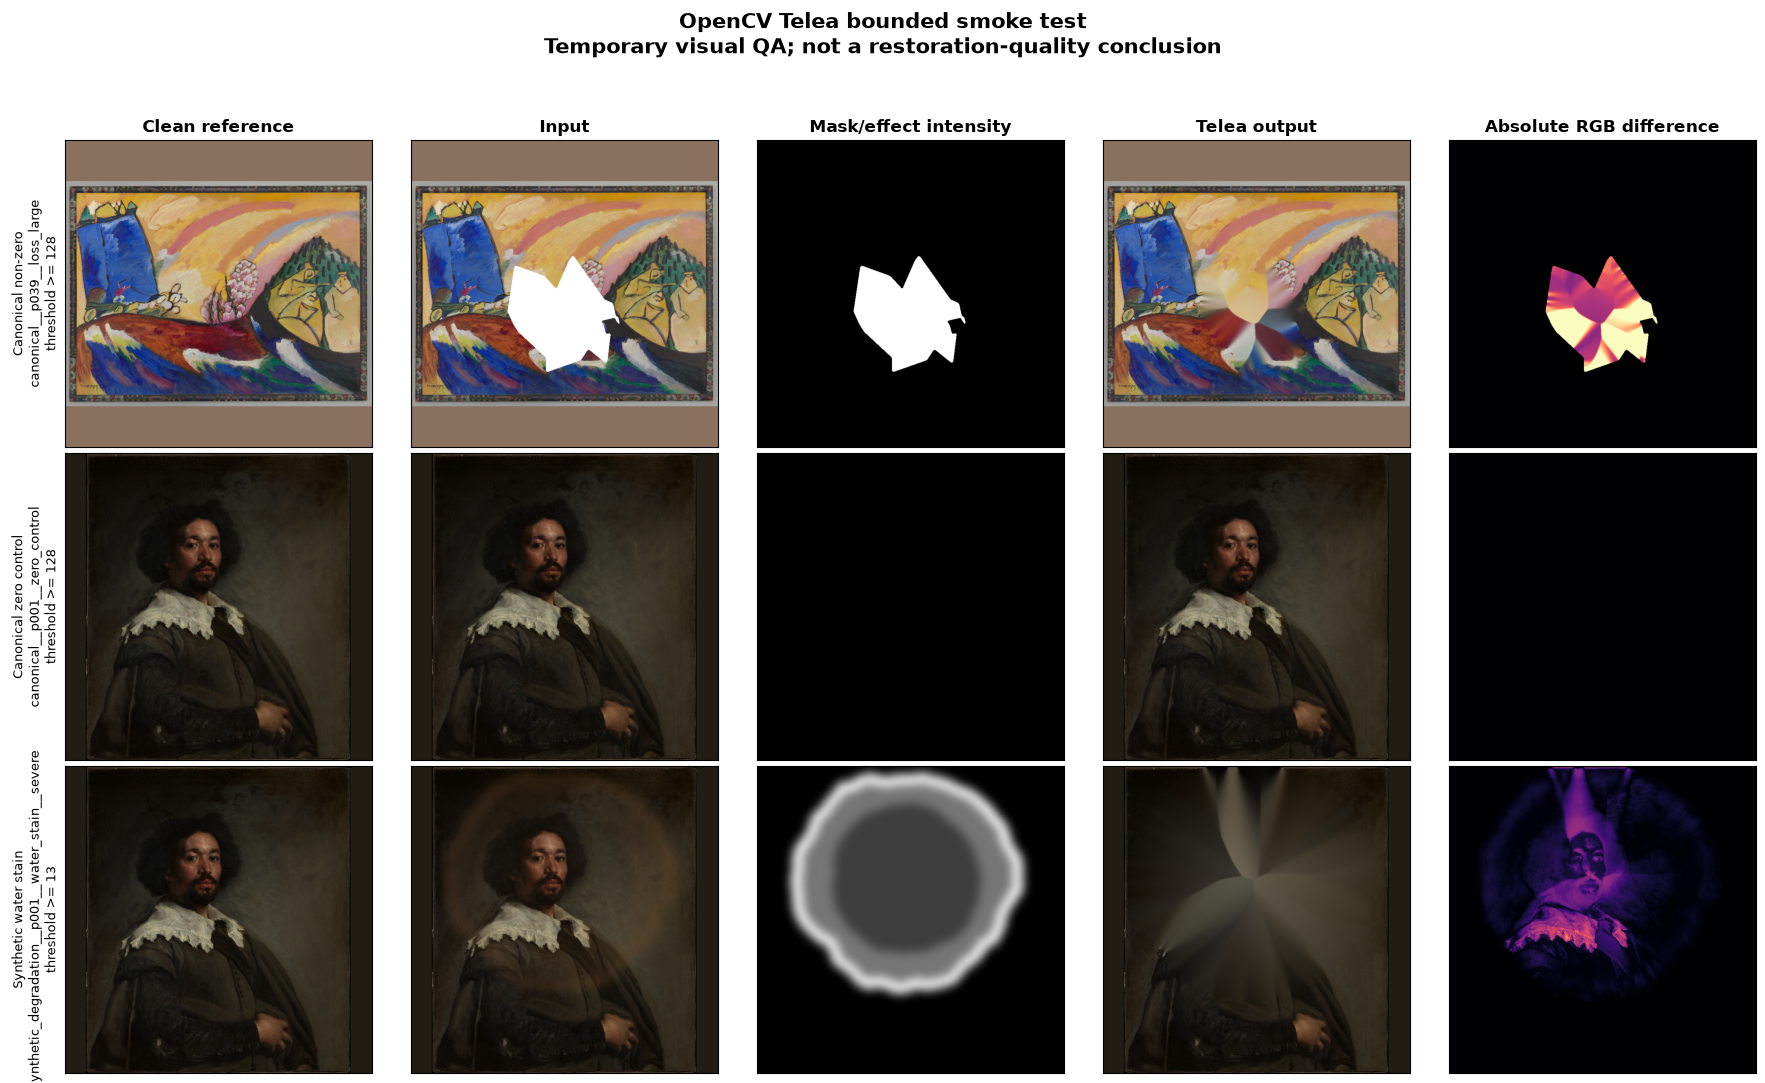

Batch 3 validation checks:


,check_id,expected,observed,passed
0,smoke_selection,"{""execution_count"": 4, ""roles"": [""primary_repe...","{""execution_count"": 4, ""roles"": [""primary_repe...",True
1,smoke_execution_status,"{""primary_repeat_1"": ""completed"", ""primary_rep...","{""primary_repeat_1"": ""completed"", ""primary_rep...",True
2,smoke_execution_actions,"{""primary_repeat_1"": ""telea_inpaint"", ""primary...","{""primary_repeat_1"": ""telea_inpaint"", ""primary...",True
3,smoke_threshold_dispatch,"{""primary_repeat_1"": 128, ""primary_repeat_2"": ...","{""primary_repeat_1"": 128, ""primary_repeat_2"": ...",True
4,exact_repeat_determinism,"{""checksum_identical"": true, ""maximum_absolute...","{""checksum_identical"": true, ""maximum_absolute...",True
5,smoke_file_contract,"{""audit_rows"": 4, ""checksum_matches"": 4, ""corr...","{""audit_rows"": 4, ""checksum_matches"": 4, ""corr...",True
6,smoke_spatial_invariants,"{""outside_invariance_valid"": 4, ""validation_pa...","{""outside_invariance_valid"": 4, ""validation_pa...",True
7,zero_control_identity,"{""changed_inside"": 0, ""changed_outside"": 0, ""m...","{""changed_inside"": 0, ""changed_outside"": 0, ""m...",True
8,nonzero_mask_behavior,"{""case_count"": 3, ""positive_inside_change_coun...","{""case_count"": 3, ""positive_inside_change_coun...",True
9,smoke_filesystem_scope,"{""all_within_smoke_root"": true, ""canonical_out...","{""all_within_smoke_root"": true, ""canonical_out...",True



Smoke execution evidence:


,smoke_role,case_id,execution_action,mask_threshold,runtime_seconds,status,restored_path
0,primary_repeat_1,canonical__p039__loss_large,telea_inpaint,128,0.456214,completed,outputs/09_opencv_telea_restoration/work/smoke...
1,primary_repeat_2,canonical__p039__loss_large,telea_inpaint,128,0.409681,completed,outputs/09_opencv_telea_restoration/work/smoke...
2,zero_control,canonical__p001__zero_control,identity_noop,128,0.496111,completed,outputs/09_opencv_telea_restoration/work/smoke...
3,synthetic_threshold,synthetic_degradation__p001__water_stain__severe,telea_inpaint,13,1.097603,completed,outputs/09_opencv_telea_restoration/work/smoke...



Reloaded smoke-output audit:


,smoke_role,restoration_id,case_id,file_exists,readable,width,height,mode,format,checksum_matches,mask_pixels,changed_inside_mask_pixels,changed_outside_mask_pixels,inside_change_valid,outside_invariance_valid,zero_control_valid,validation_passed,issue
0,primary_repeat_1,restoration__opencv_telea__canonical__p039__lo...,canonical__p039__loss_large,True,True,768,768,RGB,PNG,True,49001,49001,0,True,True,True,True,
1,primary_repeat_2,restoration__opencv_telea__canonical__p039__lo...,canonical__p039__loss_large,True,True,768,768,RGB,PNG,True,49001,49001,0,True,True,True,True,
2,zero_control,restoration__opencv_telea__canonical__p001__ze...,canonical__p001__zero_control,True,True,768,768,RGB,PNG,True,0,0,0,True,True,True,True,
3,synthetic_threshold,restoration__opencv_telea__synthetic_degradati...,synthetic_degradation__p001__water_stain__severe,True,True,768,768,RGB,PNG,True,283659,283502,0,True,True,True,True,



Determinism audit:


,case_id,repeat_1_sha256,repeat_2_sha256,checksum_identical,pixels_identical,maximum_absolute_pixel_difference
0,canonical__p039__loss_large,7c7921442cfb723e29eaccc5f1f024adab306f5c5ee76d...,7c7921442cfb723e29eaccc5f1f024adab306f5c5ee76d...,True,True,0



Batch 3 completed successfully.
Checks: 11
Passed: 11
Temporary smoke PNGs: 4
Canonical output files: 0
Next approved stage: Batch 4 - full 410-case OpenCV Telea execution.


In [17]:
# ---------------------------------------------------------------------------
# Render the bounded smoke-test visual panel
# ---------------------------------------------------------------------------

import matplotlib.pyplot as plt

visual_roles = [
    "primary_repeat_1",
    "zero_control",
    "synthetic_threshold",
]

visual_role_labels = {
    "primary_repeat_1": (
        "Canonical non-zero"
    ),
    "zero_control": (
        "Canonical zero control"
    ),
    "synthetic_threshold": (
        "Synthetic water stain"
    ),
}


visual_rows = []

for smoke_role in visual_roles:
    smoke_case = (
        smoke_case_by_role[
            smoke_role
        ]
    )

    smoke_record = (
        smoke_records_by_role[
            smoke_role
        ]
    )

    clean_path = (
        resolve_repo_path(
            smoke_case[
                "clean_image_path"
            ],
            PROJECT_ROOT,
            must_exist=True,
        )
    )

    input_path = (
        resolve_repo_path(
            smoke_case[
                "input_image_path"
            ],
            PROJECT_ROOT,
            must_exist=True,
        )
    )

    mask_path = (
        resolve_repo_path(
            smoke_case[
                "mask_or_effect_path"
            ],
            PROJECT_ROOT,
            must_exist=True,
        )
    )

    restored_path = (
        resolve_repo_path(
            smoke_record[
                "restored_path"
            ],
            PROJECT_ROOT,
            must_exist=True,
        )
    )

    with Image.open(
        clean_path
    ) as clean_image:
        clean_array = np.asarray(
            clean_image.convert(
                "RGB"
            )
        )

    with Image.open(
        input_path
    ) as input_image:
        input_array = np.asarray(
            input_image.convert(
                "RGB"
            )
        )

    with Image.open(
        mask_path
    ) as mask_image:
        mask_array = np.asarray(
            mask_image.convert(
                "L"
            )
        )

    with Image.open(
        restored_path
    ) as restored_image:
        restored_array = np.asarray(
            restored_image.convert(
                "RGB"
            )
        )

    difference_array = (
        np.abs(
            restored_array.astype(
                np.int16
            )
            - input_array.astype(
                np.int16
            )
        )
        .mean(
            axis=2
        )
    )

    visual_rows.append(
        {
            "smoke_role": smoke_role,
            "case_id": (
                smoke_case[
                    "case_id"
                ]
            ),
            "threshold": (
                smoke_record[
                    "mask_threshold"
                ]
            ),
            "clean": clean_array,
            "input": input_array,
            "mask": mask_array,
            "restored": restored_array,
            "difference": (
                difference_array
            ),
        }
    )


all_difference_values = np.concatenate(
    [
        visual_row[
            "difference"
        ].reshape(
            -1
        )
        for visual_row
        in visual_rows
    ]
)

difference_vmax = float(
    np.percentile(
        all_difference_values,
        99.0,
    )
)

difference_vmax = max(
    difference_vmax,
    1.0,
)


figure, axes = plt.subplots(
    nrows=len(
        visual_rows
    ),
    ncols=5,
    figsize=(
        18,
        11,
    ),
)

column_titles = [
    "Clean reference",
    "Input",
    "Mask/effect intensity",
    "Telea output",
    "Absolute RGB difference",
]

for column_index, column_title in enumerate(
    column_titles
):
    axes[
        0,
        column_index,
    ].set_title(
        column_title,
        fontsize=12,
        fontweight="bold",
    )


for row_index, visual_row in enumerate(
    visual_rows
):
    axes[
        row_index,
        0,
    ].imshow(
        visual_row[
            "clean"
        ]
    )

    axes[
        row_index,
        1,
    ].imshow(
        visual_row[
            "input"
        ]
    )

    axes[
        row_index,
        2,
    ].imshow(
        visual_row[
            "mask"
        ],
        cmap="gray",
        vmin=0,
        vmax=255,
    )

    axes[
        row_index,
        3,
    ].imshow(
        visual_row[
            "restored"
        ]
    )

    axes[
        row_index,
        4,
    ].imshow(
        visual_row[
            "difference"
        ],
        cmap="magma",
        vmin=0,
        vmax=(
            difference_vmax
        ),
    )

    row_label = (
        visual_role_labels[
            visual_row[
                "smoke_role"
            ]
        ]
        + "\n"
        + visual_row[
            "case_id"
        ]
        + "\n"
        + (
            "threshold >= "
            f"{visual_row['threshold']}"
        )
    )

    axes[
        row_index,
        0,
    ].set_ylabel(
        row_label,
        fontsize=9,
    )

    for axis in axes[
        row_index,
        :
    ]:
        axis.set_xticks([])
        axis.set_yticks([])


figure.suptitle(
    (
        "OpenCV Telea bounded smoke test\n"
        "Temporary visual QA; "
        "not a restoration-quality conclusion"
    ),
    fontsize=15,
    fontweight="bold",
)

figure.tight_layout(
    rect=(
        0,
        0,
        1,
        0.95,
    )
)

plt.show()


print(
    "Batch 3 validation checks:"
)

display(
    batch_3_checks_df[
        [
            "check_id",
            "expected",
            "observed",
            "passed",
        ]
    ]
)


print(
    "\nSmoke execution evidence:"
)

display(
    smoke_execution_summary_df[
        [
            "smoke_role",
            "case_id",
            "execution_action",
            "mask_threshold",
            "runtime_seconds",
            "status",
            "restored_path",
        ]
    ]
)


print(
    "\nReloaded smoke-output audit:"
)

display(
    smoke_output_audit_df
)


print(
    "\nDeterminism audit:"
)

display(
    determinism_audit_df
)


print(
    "\nBatch 3 completed successfully."
)

print(
    "Checks:",
    len(
        batch_3_checks_df
    ),
)

print(
    "Passed:",
    int(
        batch_3_checks_df[
            "passed"
        ].sum()
    ),
)

print(
    "Temporary smoke PNGs:",
    len(
        observed_smoke_png_paths
    ),
)

print(
    "Canonical output files:",
    len(
        canonical_output_files
    ),
)

print(
    "Next approved stage: "
    "Batch 4 - full 410-case "
    "OpenCV Telea execution."
)

## Batch 4 — Full OpenCV Telea execution

This batch executes the complete approved 410-case OpenCV Telea worklist.

Execution remains a fixed deterministic baseline:

- algorithm: `cv2.INPAINT_TELEA`;
- radius: 3 pixels;
- no per-case parameter tuning;
- binary missing-region threshold: `>=128`;
- synthetic active-effect threshold: `>=13`;
- zero controls: identity/no-op;
- progress reported every 10 cases;
- validated checkpoint resume under `work/`;
- failures retained as normalized records.

The restored images are canonical Notebook 09 outputs. The consolidated restoration table and other handoff artifacts are persisted only after subsequent validation.

In [18]:
from restoration_eval.restoration_opencv import (
    run_opencv_telea_cases,
    write_dataframe_atomic,
)


# ---------------------------------------------------------------------------
# Resolve and guard the canonical restored-image root
# ---------------------------------------------------------------------------

RESTORED_ROOT = (
    OUTPUTS[
        "restored_images"
    ]
    .resolve()
)

require_notebook_output_path(
    RESTORED_ROOT,
    NOTEBOOK_STEM,
    PROJECT_ROOT,
)

RESTORED_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


# ---------------------------------------------------------------------------
# Construct the exact approved canonical file set
# ---------------------------------------------------------------------------

EXPECTED_CANONICAL_PATH_BY_CASE = {
    str(
        row[
            "case_id"
        ]
    ): resolve_repo_path(
        row[
            "planned_restored_path"
        ],
        PROJECT_ROOT,
        must_exist=False,
    ).resolve()
    for _, row
    in execution_worklist_df.iterrows()
}

expected_canonical_file_paths = set(
    EXPECTED_CANONICAL_PATH_BY_CASE.values()
)

if (
    len(
        expected_canonical_file_paths
    )
    != EXPECTED_COUNTS[
        "restored_file_count"
    ]
):
    raise ValueError(
        "The canonical output plan does not "
        "contain exactly 410 unique files."
    )


# ---------------------------------------------------------------------------
# Detect and remove only stale files inside the guarded restored root
# ---------------------------------------------------------------------------

existing_restored_files_before = sorted(
    path.resolve()
    for path
    in RESTORED_ROOT.rglob(
        "*"
    )
    if path.is_file()
)

stale_restored_files = [
    path
    for path
    in existing_restored_files_before
    if path
    not in expected_canonical_file_paths
]

stale_file_action = (
    telea_config[
        "execution"
    ][
        "stale_file_action"
    ]
)

if (
    stale_restored_files
    and stale_file_action
    != "remove"
):
    raise ValueError(
        "Unexpected files exist under the "
        "canonical restoration directory, "
        "but stale_file_action is not remove."
    )

for stale_path in stale_restored_files:
    require_notebook_output_path(
        stale_path,
        NOTEBOOK_STEM,
        PROJECT_ROOT,
    )

    stale_path.relative_to(
        RESTORED_ROOT
    )

    stale_path.unlink()


# ---------------------------------------------------------------------------
# Load only normalized, schema-valid checkpoint evidence
# ---------------------------------------------------------------------------

resume_checkpoint_df = None
checkpoint_unknown_case_ids = []

if OUTPUTS[
    "checkpoint"
].is_file():
    loaded_checkpoint_df = (
        pd.read_csv(
            OUTPUTS[
                "checkpoint"
            ],
            keep_default_na=False,
        )
    )

    validate_restoration_records(
        loaded_checkpoint_df
    )

    approved_case_ids = set(
        execution_worklist_df[
            "case_id"
        ].astype(str)
    )

    checkpoint_unknown_case_ids = sorted(
        set(
            loaded_checkpoint_df[
                "case_id"
            ].astype(str)
        )
        - approved_case_ids
    )

    resume_checkpoint_df = (
        loaded_checkpoint_df.loc[
            loaded_checkpoint_df[
                "case_id"
            ]
            .astype(str)
            .isin(
                approved_case_ids
            )
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )


retained_expected_files = sorted(
    path
    for path
    in expected_canonical_file_paths
    if path.is_file()
)


print(
    "Batch 4 execution workspace prepared."
)

print(
    "Approved worklist rows:",
    len(
        execution_worklist_df
    ),
)

print(
    "Expected canonical images:",
    len(
        expected_canonical_file_paths
    ),
)

print(
    "Existing approved images:",
    len(
        retained_expected_files
    ),
)

print(
    "Removed stale files:",
    len(
        stale_restored_files
    ),
)

print(
    "Checkpoint rows available:",
    (
        0
        if resume_checkpoint_df is None
        else len(
            resume_checkpoint_df
        )
    ),
)

print(
    "Unknown checkpoint case IDs ignored:",
    len(
        checkpoint_unknown_case_ids
    ),
)

print(
    "Progress interval:",
    telea_config[
        "execution"
    ][
        "progress_interval_cases"
    ],
    "cases",
)

Batch 4 execution workspace prepared.
Approved worklist rows: 410
Expected canonical images: 410
Existing approved images: 0
Removed stale files: 0
Checkpoint rows available: 0
Unknown checkpoint case IDs ignored: 0
Progress interval: 10 cases


In [19]:
from time import perf_counter


# ---------------------------------------------------------------------------
# Persist normalized checkpoint snapshots atomically
# ---------------------------------------------------------------------------

def persist_restoration_checkpoint(
    checkpoint_df,
):
    validate_restoration_records(
        checkpoint_df
    )

    write_dataframe_atomic(
        checkpoint_df,
        OUTPUTS[
            "checkpoint"
        ],
    )


# ---------------------------------------------------------------------------
# Run the complete deterministic worklist
# ---------------------------------------------------------------------------

FULL_EXECUTION_STARTED_AT_UTC = (
    utc_now_iso()
)

full_execution_timer = (
    perf_counter()
)

print(
    "Starting full OpenCV Telea execution."
)

print(
    "Cases:",
    len(
        execution_worklist_df
    ),
)

print(
    "Progress will be printed every",
    telea_config[
        "execution"
    ][
        "progress_interval_cases"
    ],
    "cases.",
)


full_restoration_records_df = (
    run_opencv_telea_cases(
        execution_worklist_df,
        restored_root=RESTORED_ROOT,
        project_root=PROJECT_ROOT,
        config=telea_config,
        resume_records=(
            resume_checkpoint_df
        ),
        progress_callback=print,
        checkpoint_callback=(
            persist_restoration_checkpoint
        ),
    )
)


full_execution_elapsed_seconds = (
    perf_counter()
    - full_execution_timer
)

FULL_EXECUTION_FINISHED_AT_UTC = (
    utc_now_iso()
)


# ---------------------------------------------------------------------------
# Validate and retain the final normalized checkpoint
# ---------------------------------------------------------------------------

validate_restoration_records(
    full_restoration_records_df
)

persist_restoration_checkpoint(
    full_restoration_records_df
)


print(
    "Full execution cell completed."
)

print(
    "Normalized records:",
    len(
        full_restoration_records_df
    ),
)

print(
    "Elapsed seconds:",
    round(
        full_execution_elapsed_seconds,
        3,
    ),
)

print(
    "Observed throughput:",
    round(
        len(
            full_restoration_records_df
        )
        / max(
            full_execution_elapsed_seconds,
            1e-12,
        ),
        3,
    ),
    "cases/second",
)

print(
    "Checkpoint:",
    to_repo_relative(
        OUTPUTS[
            "checkpoint"
        ],
        PROJECT_ROOT,
    ),
)

Starting full OpenCV Telea execution.
Cases: 410
Progress will be printed every 10 cases.
Completed 10/410 (2.4%) | elapsed=4.8s | throughput=2.09 cases/s | latest=canonical__p002__zero_control
Completed 20/410 (4.9%) | elapsed=9.8s | throughput=2.04 cases/s | latest=canonical__p004__zero_control
Completed 30/410 (7.3%) | elapsed=14.4s | throughput=2.09 cases/s | latest=canonical__p006__zero_control
Completed 40/410 (9.8%) | elapsed=19.2s | throughput=2.09 cases/s | latest=canonical__p008__zero_control
Completed 50/410 (12.2%) | elapsed=23.0s | throughput=2.17 cases/s | latest=canonical__p010__zero_control
Completed 60/410 (14.6%) | elapsed=28.4s | throughput=2.11 cases/s | latest=canonical__p012__zero_control
Completed 70/410 (17.1%) | elapsed=32.0s | throughput=2.19 cases/s | latest=canonical__p014__zero_control
Completed 80/410 (19.5%) | elapsed=35.2s | throughput=2.27 cases/s | latest=canonical__p016__zero_control
Completed 90/410 (22.0%) | elapsed=38.9s | throughput=2.31 cases/s |

In [20]:
# ---------------------------------------------------------------------------
# Join execution records to their approved contracts
# ---------------------------------------------------------------------------

execution_contract_df = (
    execution_worklist_df[
        [
            "case_id",
            "experiment_id",
            "mask_threshold",
            "planned_restored_path",
        ]
    ]
    .rename(
        columns={
            "mask_threshold": (
                "expected_mask_threshold"
            ),
            "planned_restored_path": (
                "expected_restored_path"
            ),
        }
    )
)


full_execution_audit_df = (
    full_restoration_records_df
    .merge(
        execution_contract_df,
        on="case_id",
        how="left",
        validate="one_to_one",
    )
)


full_execution_audit_df[
    "is_zero_control"
] = (
    full_execution_audit_df[
        "case_id"
    ]
    .astype(str)
    .str.contains(
        "zero_control",
        regex=False,
    )
)


# ---------------------------------------------------------------------------
# Reload and validate the completed checkpoint
# ---------------------------------------------------------------------------

reloaded_checkpoint_df = (
    pd.read_csv(
        OUTPUTS[
            "checkpoint"
        ],
        keep_default_na=False,
    )
)

validate_restoration_records(
    reloaded_checkpoint_df
)

checkpoint_signature = {
    str(
        row[
            "case_id"
        ]
    ): (
        str(
            row[
                "restored_path"
            ]
        ),
        str(
            row[
                "restored_sha256"
            ]
        ),
        str(
            row[
                "status"
            ]
        ),
    )
    for _, row
    in reloaded_checkpoint_df.iterrows()
}

execution_signature = {
    str(
        row[
            "case_id"
        ]
    ): (
        str(
            row[
                "restored_path"
            ]
        ),
        str(
            row[
                "restored_sha256"
            ]
        ),
        str(
            row[
                "status"
            ]
        ),
    )
    for _, row
    in full_restoration_records_df.iterrows()
}


# ---------------------------------------------------------------------------
# Inspect the exact canonical filesystem scope
# ---------------------------------------------------------------------------

observed_canonical_file_paths = set(
    path.resolve()
    for path
    in RESTORED_ROOT.rglob(
        "*"
    )
    if path.is_file()
)

recorded_canonical_file_paths = set(
    resolve_repo_path(
        relative_path,
        PROJECT_ROOT,
        must_exist=False,
    ).resolve()
    for relative_path
    in full_restoration_records_df[
        "restored_path"
    ].astype(str)
)


# ---------------------------------------------------------------------------
# Derive execution evidence
# ---------------------------------------------------------------------------

status_counts = {
    str(
        status
    ): int(
        count
    )
    for status, count
    in full_restoration_records_df[
        "status"
    ]
    .value_counts()
    .sort_index()
    .items()
}

action_counts = {
    str(
        action
    ): int(
        count
    )
    for action, count
    in full_restoration_records_df[
        "execution_action"
    ]
    .value_counts()
    .sort_index()
    .items()
}

threshold_counts = {
    int(
        threshold
    ): int(
        count
    )
    for threshold, count
    in full_restoration_records_df[
        "mask_threshold"
    ]
    .value_counts()
    .sort_index()
    .items()
}


zero_action_valid = bool(
    full_execution_audit_df.loc[
        full_execution_audit_df[
            "is_zero_control"
        ],
        "execution_action",
    ]
    .astype(str)
    .isin(
        {
            "identity_noop",
            "reused_validated",
        }
    )
    .all()
)

nonzero_action_valid = bool(
    full_execution_audit_df.loc[
        ~full_execution_audit_df[
            "is_zero_control"
        ],
        "execution_action",
    ]
    .astype(str)
    .isin(
        {
            "telea_inpaint",
            "reused_validated",
        }
    )
    .all()
)

threshold_assignment_valid = bool(
    pd.to_numeric(
        full_execution_audit_df[
            "mask_threshold"
        ],
        errors="coerce",
    )
    .eq(
        pd.to_numeric(
            full_execution_audit_df[
                "expected_mask_threshold"
            ],
            errors="coerce",
        )
    )
    .all()
)

restored_path_assignment_valid = bool(
    full_execution_audit_df[
        "restored_path"
    ]
    .astype(str)
    .eq(
        full_execution_audit_df[
            "expected_restored_path"
        ]
        .astype(str)
    )
    .all()
)


fixed_metadata_valid = bool(
    full_restoration_records_df[
        "model_id"
    ]
    .astype(str)
    .eq(
        telea_config[
            "model"
        ][
            "model_id"
        ]
    )
    .all()
    and full_restoration_records_df[
        "configuration_id"
    ]
    .astype(str)
    .eq(
        telea_config[
            "model"
        ][
            "configuration_id"
        ]
    )
    .all()
    and full_restoration_records_df[
        "algorithm"
    ]
    .astype(str)
    .eq(
        telea_config[
            "model"
        ][
            "algorithm"
        ]
    )
    .all()
    and pd.to_numeric(
        full_restoration_records_df[
            "inpaint_radius"
        ],
        errors="coerce",
    )
    .eq(
        telea_config[
            "model"
        ][
            "inpaint_radius"
        ]
    )
    .all()
    and full_restoration_records_df[
        "opencv_version"
    ]
    .astype(str)
    .eq(
        cv2.__version__
    )
    .all()
    and pd.to_numeric(
        full_restoration_records_df[
            "retry_count"
        ],
        errors="coerce",
    )
    .eq(0)
    .all()
    and full_restoration_records_df[
        "generator_version"
    ]
    .astype(str)
    .eq(
        RESTORATION_GENERATOR_VERSION
    )
    .all()
    and full_restoration_records_df[
        "cpu_environment"
    ]
    .astype(str)
    .str.len()
    .gt(0)
    .all()
)


failure_records_df = (
    full_restoration_records_df.loc[
        ~full_restoration_records_df[
            "status"
        ]
        .astype(str)
        .eq(
            "completed"
        )
    ]
    .copy()
)


# ---------------------------------------------------------------------------
# Register consolidated Batch 4 checks
# ---------------------------------------------------------------------------

def add_batch_4_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage=(
            "batch_4_full_execution"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=passed,
        details=details,
    )


add_batch_4_check(
    check_id=(
        "full_execution_cardinality"
    ),
    description=(
        "Full execution produced one "
        "normalized record per approved case."
    ),
    expected={
        "record_count": 410,
        "unique_case_ids": 410,
        "unique_restoration_ids": 410,
        "duplicate_case_ids": 0,
    },
    observed={
        "record_count": len(
            full_restoration_records_df
        ),
        "unique_case_ids": int(
            full_restoration_records_df[
                "case_id"
            ].nunique()
        ),
        "unique_restoration_ids": int(
            full_restoration_records_df[
                "restoration_id"
            ].nunique()
        ),
        "duplicate_case_ids": int(
            full_restoration_records_df[
                "case_id"
            ].duplicated().sum()
        ),
    },
    passed=(
        len(
            full_restoration_records_df
        )
        == 410
        and full_restoration_records_df[
            "case_id"
        ].nunique()
        == 410
        and full_restoration_records_df[
            "restoration_id"
        ].nunique()
        == 410
        and not full_restoration_records_df[
            "case_id"
        ].duplicated().any()
    ),
)


add_batch_4_check(
    check_id=(
        "full_execution_status"
    ),
    description=(
        "Every approved case completed and "
        "no failure was silently omitted."
    ),
    expected={
        "completed": 410,
        "failed": 0,
    },
    observed={
        "status_counts": status_counts,
        "failure_count": len(
            failure_records_df
        ),
    },
    passed=(
        status_counts
        == {
            "completed": 410,
        }
        and failure_records_df.empty
    ),
    details=(
        failure_records_df
        .head(
            20
        )
        .to_dict(
            orient="records"
        )
    ),
)


add_batch_4_check(
    check_id=(
        "execution_action_semantics"
    ),
    description=(
        "Fresh and checkpoint-reused records "
        "retain the expected zero/non-zero "
        "execution semantics."
    ),
    expected={
        "zero_controls": 50,
        "nonzero_cases": 360,
        "zero_actions_valid": True,
        "nonzero_actions_valid": True,
    },
    observed={
        "zero_controls": int(
            full_execution_audit_df[
                "is_zero_control"
            ].sum()
        ),
        "nonzero_cases": int(
            (
                ~full_execution_audit_df[
                    "is_zero_control"
                ]
            ).sum()
        ),
        "action_counts": (
            action_counts
        ),
        "zero_actions_valid": (
            zero_action_valid
        ),
        "nonzero_actions_valid": (
            nonzero_action_valid
        ),
    },
    passed=(
        int(
            full_execution_audit_df[
                "is_zero_control"
            ].sum()
        )
        == 50
        and int(
            (
                ~full_execution_audit_df[
                    "is_zero_control"
                ]
            ).sum()
        )
        == 360
        and zero_action_valid
        and nonzero_action_valid
    ),
)


add_batch_4_check(
    check_id=(
        "fixed_execution_metadata"
    ),
    description=(
        "Every record preserves the fixed "
        "OpenCV Telea configuration and CPU "
        "execution evidence."
    ),
    expected={
        "algorithm": (
            "cv2.INPAINT_TELEA"
        ),
        "inpaint_radius": 3,
        "opencv_version": (
            cv2.__version__
        ),
        "retry_count": 0,
        "metadata_valid": True,
    },
    observed={
        "algorithm_values": sorted(
            full_restoration_records_df[
                "algorithm"
            ]
            .astype(str)
            .unique()
            .tolist()
        ),
        "radius_values": sorted(
            pd.to_numeric(
                full_restoration_records_df[
                    "inpaint_radius"
                ],
                errors="coerce",
            )
            .dropna()
            .astype(int)
            .unique()
            .tolist()
        ),
        "opencv_versions": sorted(
            full_restoration_records_df[
                "opencv_version"
            ]
            .astype(str)
            .unique()
            .tolist()
        ),
        "retry_values": sorted(
            pd.to_numeric(
                full_restoration_records_df[
                    "retry_count"
                ],
                errors="coerce",
            )
            .dropna()
            .astype(int)
            .unique()
            .tolist()
        ),
        "metadata_valid": (
            fixed_metadata_valid
        ),
    },
    passed=(
        fixed_metadata_valid
    ),
)


add_batch_4_check(
    check_id=(
        "full_threshold_dispatch"
    ),
    description=(
        "All 410 records use their approved "
        "binary or synthetic mask thresholds."
    ),
    expected={
        13: 50,
        128: 360,
    },
    observed=threshold_counts,
    passed=(
        threshold_counts
        == {
            13: 50,
            128: 360,
        }
        and threshold_assignment_valid
    ),
)


add_batch_4_check(
    check_id=(
        "canonical_restored_paths"
    ),
    description=(
        "Every record points to its exact "
        "planned notebook-owned output path."
    ),
    expected={
        "path_assignments_valid": True,
        "recorded_path_count": 410,
    },
    observed={
        "path_assignments_valid": (
            restored_path_assignment_valid
        ),
        "recorded_path_count": len(
            recorded_canonical_file_paths
        ),
    },
    passed=(
        restored_path_assignment_valid
        and len(
            recorded_canonical_file_paths
        )
        == 410
    ),
)


add_batch_4_check(
    check_id=(
        "canonical_image_filesystem_scope"
    ),
    description=(
        "The canonical restored-image "
        "directory contains exactly the "
        "410 approved non-empty PNG files."
    ),
    expected={
        "expected_files": 410,
        "observed_files": 410,
        "missing_files": 0,
        "unexpected_files": 0,
        "empty_files": 0,
    },
    observed={
        "expected_files": len(
            expected_canonical_file_paths
        ),
        "observed_files": len(
            observed_canonical_file_paths
        ),
        "missing_files": len(
            expected_canonical_file_paths
            - observed_canonical_file_paths
        ),
        "unexpected_files": len(
            observed_canonical_file_paths
            - expected_canonical_file_paths
        ),
        "empty_files": sum(
            path.stat().st_size
            <= 0
            for path
            in observed_canonical_file_paths
        ),
    },
    passed=(
        observed_canonical_file_paths
        == expected_canonical_file_paths
        == recorded_canonical_file_paths
        and all(
            path.stat().st_size
            > 0
            for path
            in observed_canonical_file_paths
        )
    ),
)


add_batch_4_check(
    check_id=(
        "restored_checksum_evidence"
    ),
    description=(
        "Every completed output records a "
        "non-empty SHA-256 checksum and "
        "non-negative runtime."
    ),
    expected={
        "valid_hashes": 410,
        "nonnegative_runtimes": 410,
    },
    observed={
        "valid_hashes": int(
            full_restoration_records_df[
                "restored_sha256"
            ]
            .astype(str)
            .str.fullmatch(
                r"[0-9a-f]{64}"
            )
            .sum()
        ),
        "nonnegative_runtimes": int(
            pd.to_numeric(
                full_restoration_records_df[
                    "runtime_seconds"
                ],
                errors="coerce",
            )
            .ge(0)
            .sum()
        ),
    },
    passed=(
        full_restoration_records_df[
            "restored_sha256"
        ]
        .astype(str)
        .str.fullmatch(
            r"[0-9a-f]{64}"
        )
        .all()
        and pd.to_numeric(
            full_restoration_records_df[
                "runtime_seconds"
            ],
            errors="coerce",
        )
        .ge(0)
        .all()
    ),
)


add_batch_4_check(
    check_id=(
        "completed_checkpoint"
    ),
    description=(
        "The work checkpoint reloads with "
        "all normalized execution evidence."
    ),
    expected={
        "checkpoint_rows": 410,
        "checkpoint_matches_memory": True,
    },
    observed={
        "checkpoint_rows": len(
            reloaded_checkpoint_df
        ),
        "checkpoint_matches_memory": (
            checkpoint_signature
            == execution_signature
        ),
    },
    passed=(
        len(
            reloaded_checkpoint_df
        )
        == 410
        and checkpoint_signature
        == execution_signature
    ),
)


all_validation_checks_df = (
    VALIDATION.to_dataframe()
)

batch_4_checks_df = (
    all_validation_checks_df.loc[
        all_validation_checks_df[
            "validation_stage"
        ]
        == "batch_4_full_execution"
    ]
    .drop_duplicates(
        subset=[
            "check_id",
        ],
        keep="last",
    )
    .reset_index(
        drop=True
    )
)


VALIDATION.raise_for_blocking()


print(
    "Batch 4 validation cell completed."
)

print(
    "Checks passed:",
    int(
        batch_4_checks_df[
            "passed"
        ].sum()
    ),
    "/",
    len(
        batch_4_checks_df
    ),
)

print(
    "Canonical images:",
    len(
        observed_canonical_file_paths
    ),
)

print(
    "Failures:",
    len(
        failure_records_df
    ),
)

Batch 4 validation cell completed.
Checks passed: 9 / 9
Canonical images: 410
Failures: 0


In [21]:
# ---------------------------------------------------------------------------
# Compact execution summaries
# ---------------------------------------------------------------------------

execution_by_experiment_df = (
    full_execution_audit_df
    .groupby(
        "experiment_id",
        as_index=False,
    )
    .agg(
        case_count=(
            "case_id",
            "size",
        ),
        completed_count=(
            "status",
            lambda values: int(
                values.astype(str)
                .eq(
                    "completed"
                )
                .sum()
            ),
        ),
        total_runtime_seconds=(
            "runtime_seconds",
            "sum",
        ),
        median_runtime_seconds=(
            "runtime_seconds",
            "median",
        ),
        maximum_runtime_seconds=(
            "runtime_seconds",
            "max",
        ),
    )
    .sort_values(
        "experiment_id",
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)


execution_action_summary_df = (
    full_restoration_records_df
    .groupby(
        "execution_action",
        as_index=False,
    )
    .agg(
        case_count=(
            "case_id",
            "size",
        ),
        total_runtime_seconds=(
            "runtime_seconds",
            "sum",
        ),
        median_runtime_seconds=(
            "runtime_seconds",
            "median",
        ),
    )
    .sort_values(
        "execution_action",
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)


print(
    "Batch 4 validation checks:"
)

display(
    batch_4_checks_df[
        [
            "check_id",
            "expected",
            "observed",
            "passed",
        ]
    ]
)


print(
    "\nExecution by experiment:"
)

display(
    execution_by_experiment_df
)


print(
    "\nExecution actions:"
)

display(
    execution_action_summary_df
)


if not failure_records_df.empty:
    print(
        "\nVisible failure records:"
    )

    display(
        failure_records_df[
            [
                "case_id",
                "experiment_id",
                "execution_action",
                "status",
                "issue",
            ]
        ]
    )


print(
    "\nBatch 4 completed successfully."
)

print(
    "Records:",
    len(
        full_restoration_records_df
    ),
)

print(
    "Canonical restored PNGs:",
    len(
        observed_canonical_file_paths
    ),
)

print(
    "Full execution elapsed seconds:",
    round(
        full_execution_elapsed_seconds,
        3,
    ),
)

print(
    "Important interpretation: "
    "visual artifacts are baseline outcomes, "
    "not evidence of historically valid reconstruction."
)

print(
    "Next approved stage: "
    "Batch 5 - full scientific and "
    "filesystem validation."
)

Batch 4 validation checks:


,check_id,expected,observed,passed
0,full_execution_cardinality,"{""duplicate_case_ids"": 0, ""record_count"": 410,...","{""duplicate_case_ids"": 0, ""record_count"": 410,...",True
1,full_execution_status,"{""completed"": 410, ""failed"": 0}","{""failure_count"": 0, ""status_counts"": {""comple...",True
2,execution_action_semantics,"{""nonzero_actions_valid"": true, ""nonzero_cases...","{""action_counts"": {""identity_noop"": 50, ""telea...",True
3,fixed_execution_metadata,"{""algorithm"": ""cv2.INPAINT_TELEA"", ""inpaint_ra...","{""algorithm_values"": [""cv2.INPAINT_TELEA""], ""m...",True
4,full_threshold_dispatch,"{""13"": 50, ""128"": 360}","{""13"": 50, ""128"": 360}",True
5,canonical_restored_paths,"{""path_assignments_valid"": true, ""recorded_pat...","{""path_assignments_valid"": true, ""recorded_pat...",True
6,canonical_image_filesystem_scope,"{""empty_files"": 0, ""expected_files"": 410, ""mis...","{""empty_files"": 0, ""expected_files"": 410, ""mis...",True
7,restored_checksum_evidence,"{""nonnegative_runtimes"": 410, ""valid_hashes"": ...","{""nonnegative_runtimes"": 410, ""valid_hashes"": ...",True
8,completed_checkpoint,"{""checkpoint_matches_memory"": true, ""checkpoin...","{""checkpoint_matches_memory"": true, ""checkpoin...",True



Execution by experiment:


,experiment_id,case_count,completed_count,total_runtime_seconds,median_runtime_seconds,maximum_runtime_seconds
0,canonical_missing_region,250,250,104.413864,0.410636,0.714920
1,damage_size_sensitivity,35,35,17.550965,0.483976,0.833566
2,mask_robustness,75,75,32.703586,0.397811,0.711408
3,synthetic_degradation,50,50,30.945133,0.615850,1.019818



Execution actions:


,execution_action,case_count,total_runtime_seconds,median_runtime_seconds
0,identity_noop,50,18.023732,0.351664
1,telea_inpaint,360,167.589816,0.440147



Batch 4 completed successfully.
Records: 410
Canonical restored PNGs: 410
Full execution elapsed seconds: 188.562
Important interpretation: visual artifacts are baseline outcomes, not evidence of historically valid reconstruction.
Next approved stage: Batch 5 - full scientific and filesystem validation.


## Batch 5 — Scientific and filesystem validation

This batch reloads and validates every canonical restoration.

Validation covers:

- normalized execution-record integrity;
- exact record and file cardinalities;
- image readability, dimensions, mode, and format;
- persisted-file checksum agreement;
- zero-control identity;
- positive inside-mask change for every non-zero case;
- exact outside-mask invariance;
- stale, missing, orphaned, and empty-file detection;
- output-path ownership;
- consolidated validation results by experiment.

These checks validate execution integrity and spatial behavior. They do not claim that the generated content is historically or visually correct.

In [22]:
# ---------------------------------------------------------------------------
# Reload the normalized execution checkpoint
# ---------------------------------------------------------------------------

validation_records_df = (
    pd.read_csv(
        OUTPUTS[
            "checkpoint"
        ],
        keep_default_na=False,
    )
)

validate_restoration_records(
    validation_records_df
)


approved_validation_case_ids = set(
    execution_worklist_df[
        "case_id"
    ].astype(str)
)

observed_validation_case_ids = set(
    validation_records_df[
        "case_id"
    ].astype(str)
)

if (
    observed_validation_case_ids
    != approved_validation_case_ids
):
    raise ValueError(
        "The completed checkpoint does not "
        "match the exact approved worklist."
    )


# ---------------------------------------------------------------------------
# Reload images and validate them in progress-reporting chunks
# ---------------------------------------------------------------------------

VALIDATION_CHUNK_SIZE = int(
    telea_config[
        "execution"
    ][
        "progress_interval_cases"
    ]
)

ordered_validation_worklist_df = (
    execution_worklist_df
    .sort_values(
        [
            "experiment_id",
            "case_id",
        ],
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)

validation_audit_chunks = []

validation_timer = (
    perf_counter()
)

total_validation_cases = len(
    ordered_validation_worklist_df
)


print(
    "Starting persisted-output validation."
)

print(
    "Cases:",
    total_validation_cases,
)

print(
    "Progress interval:",
    VALIDATION_CHUNK_SIZE,
)


for chunk_start in range(
    0,
    total_validation_cases,
    VALIDATION_CHUNK_SIZE,
):
    chunk_end = min(
        chunk_start
        + VALIDATION_CHUNK_SIZE,
        total_validation_cases,
    )

    worklist_chunk_df = (
        ordered_validation_worklist_df
        .iloc[
            chunk_start:chunk_end
        ]
        .copy()
    )

    chunk_case_ids = set(
        worklist_chunk_df[
            "case_id"
        ].astype(str)
    )

    records_chunk_df = (
        validation_records_df.loc[
            validation_records_df[
                "case_id"
            ]
            .astype(str)
            .isin(
                chunk_case_ids
            )
        ]
        .copy()
    )

    if (
        len(
            records_chunk_df
        )
        != len(
            worklist_chunk_df
        )
    ):
        raise ValueError(
            "A validation chunk does not "
            "contain one record per worklist case."
        )

    audit_chunk_df = (
        validate_restoration_outputs(
            records_chunk_df,
            worklist_chunk_df,
            project_root=PROJECT_ROOT,
            config=telea_config,
        )
    )

    validation_audit_chunks.append(
        audit_chunk_df
    )

    completed_validation_cases = (
        chunk_end
    )

    elapsed_validation_seconds = max(
        perf_counter()
        - validation_timer,
        1e-12,
    )

    latest_validated_case_id = str(
        worklist_chunk_df.iloc[
            -1
        ][
            "case_id"
        ]
    )

    print(
        (
            f"Validated "
            f"{completed_validation_cases}/"
            f"{total_validation_cases} "
            f"({completed_validation_cases / total_validation_cases:.1%})"
            f" | elapsed={elapsed_validation_seconds:.1f}s"
            f" | throughput="
            f"{completed_validation_cases / elapsed_validation_seconds:.2f} "
            f"cases/s"
            f" | latest={latest_validated_case_id}"
        )
    )


full_output_audit_df = (
    pd.concat(
        validation_audit_chunks,
        ignore_index=True,
    )
)


validation_case_order = {
    str(
        case_id
    ): position
    for position, case_id
    in enumerate(
        ordered_validation_worklist_df[
            "case_id"
        ].astype(str)
    )
}

full_output_audit_df[
    "validation_order"
] = (
    full_output_audit_df[
        "case_id"
    ]
    .astype(str)
    .map(
        validation_case_order
    )
)

full_output_audit_df = (
    full_output_audit_df
    .sort_values(
        "validation_order",
        kind="stable",
    )
    .drop(
        columns=[
            "validation_order",
        ]
    )
    .reset_index(
        drop=True
    )
)


full_validation_elapsed_seconds = (
    perf_counter()
    - validation_timer
)


print(
    "Persisted-output validation cell completed."
)

print(
    "Audit rows:",
    len(
        full_output_audit_df
    ),
)

print(
    "Validation-passed rows:",
    int(
        full_output_audit_df[
            "validation_passed"
        ].sum()
    ),
)

print(
    "Elapsed seconds:",
    round(
        full_validation_elapsed_seconds,
        3,
    ),
)

Starting persisted-output validation.
Cases: 410
Progress interval: 10
Validated 10/410 (2.4%) | elapsed=0.8s | throughput=13.12 cases/s | latest=canonical__p002__zero_control
Validated 20/410 (4.9%) | elapsed=1.7s | throughput=12.11 cases/s | latest=canonical__p004__zero_control
Validated 30/410 (7.3%) | elapsed=2.5s | throughput=11.94 cases/s | latest=canonical__p006__zero_control
Validated 40/410 (9.8%) | elapsed=3.5s | throughput=11.41 cases/s | latest=canonical__p008__zero_control
Validated 50/410 (12.2%) | elapsed=4.6s | throughput=10.82 cases/s | latest=canonical__p010__zero_control
Validated 60/410 (14.6%) | elapsed=5.6s | throughput=10.72 cases/s | latest=canonical__p012__zero_control
Validated 70/410 (17.1%) | elapsed=6.5s | throughput=10.81 cases/s | latest=canonical__p014__zero_control
Validated 80/410 (19.5%) | elapsed=7.3s | throughput=10.93 cases/s | latest=canonical__p016__zero_control
Validated 90/410 (22.0%) | elapsed=8.2s | throughput=10.99 cases/s | latest=canonical

In [23]:
# ---------------------------------------------------------------------------
# Attach execution and experiment evidence to the image audit
# ---------------------------------------------------------------------------

full_scientific_audit_df = (
    full_output_audit_df
    .merge(
        validation_records_df[
            [
                "case_id",
                "restored_path",
                "mask_threshold",
                "execution_action",
                "status",
            ]
        ],
        on="case_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        execution_worklist_df[
            [
                "case_id",
                "experiment_id",
                "planned_restored_path",
            ]
        ],
        on="case_id",
        how="left",
        validate="one_to_one",
    )
)


full_scientific_audit_df[
    "is_zero_control"
] = (
    pd.to_numeric(
        full_scientific_audit_df[
            "mask_pixels"
        ],
        errors="coerce",
    )
    .eq(0)
)


zero_control_audit_df = (
    full_scientific_audit_df.loc[
        full_scientific_audit_df[
            "is_zero_control"
        ]
    ]
    .copy()
)

nonzero_case_audit_df = (
    full_scientific_audit_df.loc[
        ~full_scientific_audit_df[
            "is_zero_control"
        ]
    ]
    .copy()
)


# ---------------------------------------------------------------------------
# Rebuild the exact expected and observed filesystem sets
# ---------------------------------------------------------------------------

expected_validation_file_paths = set(
    resolve_repo_path(
        relative_path,
        PROJECT_ROOT,
        must_exist=False,
    ).resolve()
    for relative_path
    in execution_worklist_df[
        "planned_restored_path"
    ].astype(str)
)

recorded_validation_file_paths = set(
    resolve_repo_path(
        relative_path,
        PROJECT_ROOT,
        must_exist=False,
    ).resolve()
    for relative_path
    in validation_records_df[
        "restored_path"
    ].astype(str)
)

observed_validation_file_paths = set(
    path.resolve()
    for path
    in RESTORED_ROOT.rglob(
        "*"
    )
    if path.is_file()
)


missing_validation_files = (
    expected_validation_file_paths
    - observed_validation_file_paths
)

orphaned_validation_files = (
    observed_validation_file_paths
    - expected_validation_file_paths
)

empty_validation_files = {
    path
    for path
    in observed_validation_file_paths
    if path.stat().st_size
    <= 0
}


# ---------------------------------------------------------------------------
# Derive detailed validation conditions
# ---------------------------------------------------------------------------

file_geometry_valid = bool(
    full_scientific_audit_df[
        "file_exists"
    ]
    .astype(bool)
    .all()
    and full_scientific_audit_df[
        "readable"
    ]
    .astype(bool)
    .all()
    and pd.to_numeric(
        full_scientific_audit_df[
            "width"
        ],
        errors="coerce",
    )
    .eq(
        telea_config[
            "execution"
        ][
            "target_width"
        ]
    )
    .all()
    and pd.to_numeric(
        full_scientific_audit_df[
            "height"
        ],
        errors="coerce",
    )
    .eq(
        telea_config[
            "execution"
        ][
            "target_height"
        ]
    )
    .all()
    and full_scientific_audit_df[
        "mode"
    ]
    .astype(str)
    .eq(
        telea_config[
            "execution"
        ][
            "output_mode"
        ]
    )
    .all()
    and full_scientific_audit_df[
        "format"
    ]
    .astype(str)
    .eq(
        telea_config[
            "execution"
        ][
            "output_format"
        ]
    )
    .all()
)


checksum_integrity_valid = bool(
    full_scientific_audit_df[
        "checksum_matches"
    ]
    .astype(bool)
    .all()
)


zero_control_identity_valid = bool(
    len(
        zero_control_audit_df
    )
    == 50
    and pd.to_numeric(
        zero_control_audit_df[
            "changed_inside_mask_pixels"
        ],
        errors="coerce",
    )
    .eq(0)
    .all()
    and pd.to_numeric(
        zero_control_audit_df[
            "changed_outside_mask_pixels"
        ],
        errors="coerce",
    )
    .eq(0)
    .all()
    and zero_control_audit_df[
        "zero_control_valid"
    ]
    .astype(bool)
    .all()
)


nonzero_inside_change_valid = bool(
    len(
        nonzero_case_audit_df
    )
    == 360
    and pd.to_numeric(
        nonzero_case_audit_df[
            "mask_pixels"
        ],
        errors="coerce",
    )
    .gt(0)
    .all()
    and pd.to_numeric(
        nonzero_case_audit_df[
            "changed_inside_mask_pixels"
        ],
        errors="coerce",
    )
    .gt(0)
    .all()
    and nonzero_case_audit_df[
        "inside_change_valid"
    ]
    .astype(bool)
    .all()
)


outside_mask_invariance_valid = bool(
    pd.to_numeric(
        full_scientific_audit_df[
            "changed_outside_mask_pixels"
        ],
        errors="coerce",
    )
    .eq(0)
    .all()
    and full_scientific_audit_df[
        "outside_invariance_valid"
    ]
    .astype(bool)
    .all()
)


restored_path_ownership_valid = bool(
    full_scientific_audit_df[
        "restored_path"
    ]
    .astype(str)
    .eq(
        full_scientific_audit_df[
            "planned_restored_path"
        ]
        .astype(str)
    )
    .all()
    and full_scientific_audit_df[
        "restored_path"
    ]
    .astype(str)
    .str.startswith(
        (
            "outputs/"
            "09_opencv_telea_restoration/"
            "images/restored/"
        )
    )
    .all()
)


complete_audit_valid = bool(
    full_scientific_audit_df[
        "validation_passed"
    ]
    .astype(bool)
    .all()
    and full_scientific_audit_df[
        "issue"
    ]
    .fillna("")
    .astype(str)
    .str.len()
    .eq(0)
    .all()
)


failed_scientific_audit_df = (
    full_scientific_audit_df.loc[
        ~full_scientific_audit_df[
            "validation_passed"
        ]
        .astype(bool)
    ]
    .copy()
)


# ---------------------------------------------------------------------------
# Register Batch 5 validation evidence
# ---------------------------------------------------------------------------

def add_batch_5_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage=(
            "batch_5_scientific_validation"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=passed,
        details=details,
    )


add_batch_5_check(
    check_id=(
        "persisted_audit_cardinality"
    ),
    description=(
        "Every approved restoration has "
        "one unique persisted-output audit."
    ),
    expected={
        "audit_rows": 410,
        "unique_case_ids": 410,
        "unique_restoration_ids": 410,
    },
    observed={
        "audit_rows": len(
            full_scientific_audit_df
        ),
        "unique_case_ids": int(
            full_scientific_audit_df[
                "case_id"
            ].nunique()
        ),
        "unique_restoration_ids": int(
            full_scientific_audit_df[
                "restoration_id"
            ].nunique()
        ),
    },
    passed=(
        len(
            full_scientific_audit_df
        )
        == 410
        and full_scientific_audit_df[
            "case_id"
        ].nunique()
        == 410
        and full_scientific_audit_df[
            "restoration_id"
        ].nunique()
        == 410
    ),
)


add_batch_5_check(
    check_id=(
        "persisted_image_contract"
    ),
    description=(
        "All restored images reload as "
        "readable 768x768 RGB PNG files."
    ),
    expected={
        "valid_images": 410,
        "width": 768,
        "height": 768,
        "mode": "RGB",
        "format": "PNG",
    },
    observed={
        "existing_files": int(
            full_scientific_audit_df[
                "file_exists"
            ].sum()
        ),
        "readable_files": int(
            full_scientific_audit_df[
                "readable"
            ].sum()
        ),
        "width_values": sorted(
            pd.to_numeric(
                full_scientific_audit_df[
                    "width"
                ],
                errors="coerce",
            )
            .dropna()
            .astype(int)
            .unique()
            .tolist()
        ),
        "height_values": sorted(
            pd.to_numeric(
                full_scientific_audit_df[
                    "height"
                ],
                errors="coerce",
            )
            .dropna()
            .astype(int)
            .unique()
            .tolist()
        ),
        "mode_values": sorted(
            full_scientific_audit_df[
                "mode"
            ]
            .astype(str)
            .unique()
            .tolist()
        ),
        "format_values": sorted(
            full_scientific_audit_df[
                "format"
            ]
            .astype(str)
            .unique()
            .tolist()
        ),
    },
    passed=(
        file_geometry_valid
    ),
)


add_batch_5_check(
    check_id=(
        "persisted_checksum_integrity"
    ),
    description=(
        "Every restored file matches its "
        "recorded SHA-256 checksum."
    ),
    expected={
        "matching_checksums": 410,
    },
    observed={
        "matching_checksums": int(
            full_scientific_audit_df[
                "checksum_matches"
            ].sum()
        ),
    },
    passed=(
        checksum_integrity_valid
    ),
)


add_batch_5_check(
    check_id=(
        "zero_control_identity"
    ),
    description=(
        "All 50 zero controls remain exact "
        "identity/no-op outputs."
    ),
    expected={
        "zero_controls": 50,
        "changed_inside_pixels": 0,
        "changed_outside_pixels": 0,
        "all_identity_valid": True,
    },
    observed={
        "zero_controls": len(
            zero_control_audit_df
        ),
        "changed_inside_pixels": int(
            pd.to_numeric(
                zero_control_audit_df[
                    "changed_inside_mask_pixels"
                ],
                errors="coerce",
            )
            .sum()
        ),
        "changed_outside_pixels": int(
            pd.to_numeric(
                zero_control_audit_df[
                    "changed_outside_mask_pixels"
                ],
                errors="coerce",
            )
            .sum()
        ),
        "all_identity_valid": bool(
            zero_control_audit_df[
                "zero_control_valid"
            ]
            .astype(bool)
            .all()
        ),
    },
    passed=(
        zero_control_identity_valid
    ),
)


add_batch_5_check(
    check_id=(
        "nonzero_inside_mask_change"
    ),
    description=(
        "Every non-zero restoration changes "
        "at least one pixel inside its "
        "approved mask."
    ),
    expected={
        "nonzero_cases": 360,
        "positive_inside_change_cases": 360,
    },
    observed={
        "nonzero_cases": len(
            nonzero_case_audit_df
        ),
        "positive_inside_change_cases": int(
            pd.to_numeric(
                nonzero_case_audit_df[
                    "changed_inside_mask_pixels"
                ],
                errors="coerce",
            )
            .gt(0)
            .sum()
        ),
    },
    passed=(
        nonzero_inside_change_valid
    ),
)


add_batch_5_check(
    check_id=(
        "outside_mask_invariance"
    ),
    description=(
        "No restoration changes any pixel "
        "outside its approved mask."
    ),
    expected={
        "valid_cases": 410,
        "changed_outside_pixels": 0,
    },
    observed={
        "valid_cases": int(
            full_scientific_audit_df[
                "outside_invariance_valid"
            ]
            .astype(bool)
            .sum()
        ),
        "changed_outside_pixels": int(
            pd.to_numeric(
                full_scientific_audit_df[
                    "changed_outside_mask_pixels"
                ],
                errors="coerce",
            )
            .sum()
        ),
    },
    passed=(
        outside_mask_invariance_valid
    ),
)


add_batch_5_check(
    check_id=(
        "canonical_filesystem_exactness"
    ),
    description=(
        "Canonical restored-image storage "
        "contains no missing, orphaned, "
        "unexpected, or empty files."
    ),
    expected={
        "expected_files": 410,
        "recorded_files": 410,
        "observed_files": 410,
        "missing_files": 0,
        "orphaned_files": 0,
        "empty_files": 0,
    },
    observed={
        "expected_files": len(
            expected_validation_file_paths
        ),
        "recorded_files": len(
            recorded_validation_file_paths
        ),
        "observed_files": len(
            observed_validation_file_paths
        ),
        "missing_files": len(
            missing_validation_files
        ),
        "orphaned_files": len(
            orphaned_validation_files
        ),
        "empty_files": len(
            empty_validation_files
        ),
    },
    passed=(
        expected_validation_file_paths
        == recorded_validation_file_paths
        == observed_validation_file_paths
        and not missing_validation_files
        and not orphaned_validation_files
        and not empty_validation_files
    ),
)


add_batch_5_check(
    check_id=(
        "restored_output_ownership"
    ),
    description=(
        "Every canonical restored image "
        "belongs to the approved Notebook 09 "
        "output root and planned path."
    ),
    expected={
        "all_paths_owned": True,
        "all_paths_match_plan": True,
    },
    observed={
        "all_paths_owned_and_planned": (
            restored_path_ownership_valid
        ),
    },
    passed=(
        restored_path_ownership_valid
    ),
)


add_batch_5_check(
    check_id=(
        "complete_scientific_audit"
    ),
    description=(
        "All 410 helper-level scientific "
        "and file validations pass without "
        "recorded issues."
    ),
    expected={
        "passed_rows": 410,
        "failed_rows": 0,
    },
    observed={
        "passed_rows": int(
            full_scientific_audit_df[
                "validation_passed"
            ].sum()
        ),
        "failed_rows": len(
            failed_scientific_audit_df
        ),
    },
    passed=(
        complete_audit_valid
    ),
    details=(
        failed_scientific_audit_df
        .head(
            20
        )
        .to_dict(
            orient="records"
        )
    ),
)


all_validation_checks_df = (
    VALIDATION.to_dataframe()
)

batch_5_checks_df = (
    all_validation_checks_df.loc[
        all_validation_checks_df[
            "validation_stage"
        ]
        == "batch_5_scientific_validation"
    ]
    .drop_duplicates(
        subset=[
            "check_id",
        ],
        keep="last",
    )
    .reset_index(
        drop=True
    )
)


VALIDATION.raise_for_blocking()


print(
    "Batch 5 consolidated checks completed."
)

print(
    "Checks passed:",
    int(
        batch_5_checks_df[
            "passed"
        ].sum()
    ),
    "/",
    len(
        batch_5_checks_df
    ),
)

print(
    "Validated outputs:",
    len(
        full_scientific_audit_df
    ),
)

print(
    "Failed output audits:",
    len(
        failed_scientific_audit_df
    ),
)

Batch 5 consolidated checks completed.
Checks passed: 9 / 9
Validated outputs: 410
Failed output audits: 0


In [24]:
# ---------------------------------------------------------------------------
# Summarize validation evidence by experiment
# ---------------------------------------------------------------------------

validation_by_experiment_df = (
    full_scientific_audit_df
    .groupby(
        "experiment_id",
        as_index=False,
    )
    .agg(
        case_count=(
            "case_id",
            "size",
        ),
        validation_passed_count=(
            "validation_passed",
            "sum",
        ),
        zero_control_count=(
            "is_zero_control",
            "sum",
        ),
        total_mask_pixels=(
            "mask_pixels",
            "sum",
        ),
        changed_inside_mask_pixels=(
            "changed_inside_mask_pixels",
            "sum",
        ),
        changed_outside_mask_pixels=(
            "changed_outside_mask_pixels",
            "sum",
        ),
    )
    .sort_values(
        "experiment_id",
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)


file_contract_summary_df = pd.DataFrame(
    [
        {
            "contract": "file_exists",
            "passed_count": int(
                full_scientific_audit_df[
                    "file_exists"
                ].sum()
            ),
            "expected_count": 410,
        },
        {
            "contract": "readable",
            "passed_count": int(
                full_scientific_audit_df[
                    "readable"
                ].sum()
            ),
            "expected_count": 410,
        },
        {
            "contract": "checksum_matches",
            "passed_count": int(
                full_scientific_audit_df[
                    "checksum_matches"
                ].sum()
            ),
            "expected_count": 410,
        },
        {
            "contract": (
                "inside_change_valid"
            ),
            "passed_count": int(
                full_scientific_audit_df[
                    "inside_change_valid"
                ].sum()
            ),
            "expected_count": 410,
        },
        {
            "contract": (
                "outside_invariance_valid"
            ),
            "passed_count": int(
                full_scientific_audit_df[
                    "outside_invariance_valid"
                ].sum()
            ),
            "expected_count": 410,
        },
        {
            "contract": (
                "validation_passed"
            ),
            "passed_count": int(
                full_scientific_audit_df[
                    "validation_passed"
                ].sum()
            ),
            "expected_count": 410,
        },
    ]
)


print(
    "Batch 5 validation checks:"
)

display(
    batch_5_checks_df[
        [
            "check_id",
            "expected",
            "observed",
            "passed",
        ]
    ]
)


print(
    "\nValidation by experiment:"
)

display(
    validation_by_experiment_df
)


print(
    "\nPersisted-image contract summary:"
)

display(
    file_contract_summary_df
)


if not failed_scientific_audit_df.empty:
    print(
        "\nFailed scientific audits:"
    )

    display(
        failed_scientific_audit_df[
            [
                "case_id",
                "experiment_id",
                "issue",
            ]
        ]
    )


print(
    "\nBatch 5 completed successfully."
)

print(
    "Scientific/file checks:",
    len(
        batch_5_checks_df
    ),
)

print(
    "Passed:",
    int(
        batch_5_checks_df[
            "passed"
        ].sum()
    ),
)

print(
    "Zero controls validated:",
    len(
        zero_control_audit_df
    ),
)

print(
    "Non-zero cases validated:",
    len(
        nonzero_case_audit_df
    ),
)

print(
    "Outside-mask changed pixels:",
    int(
        pd.to_numeric(
            full_scientific_audit_df[
                "changed_outside_mask_pixels"
            ],
            errors="coerce",
        )
        .sum()
    ),
)

print(
    "Next approved stage: "
    "Batch 6 - analysis, runtime summary, "
    "and representative restoration figure."
)

Batch 5 validation checks:


,check_id,expected,observed,passed
0,persisted_audit_cardinality,"{""audit_rows"": 410, ""unique_case_ids"": 410, ""u...","{""audit_rows"": 410, ""unique_case_ids"": 410, ""u...",True
1,persisted_image_contract,"{""format"": ""PNG"", ""height"": 768, ""mode"": ""RGB""...","{""existing_files"": 410, ""format_values"": [""PNG...",True
2,persisted_checksum_integrity,"{""matching_checksums"": 410}","{""matching_checksums"": 410}",True
3,zero_control_identity,"{""all_identity_valid"": true, ""changed_inside_p...","{""all_identity_valid"": true, ""changed_inside_p...",True
4,nonzero_inside_mask_change,"{""nonzero_cases"": 360, ""positive_inside_change...","{""nonzero_cases"": 360, ""positive_inside_change...",True
5,outside_mask_invariance,"{""changed_outside_pixels"": 0, ""valid_cases"": 410}","{""changed_outside_pixels"": 0, ""valid_cases"": 410}",True
6,canonical_filesystem_exactness,"{""empty_files"": 0, ""expected_files"": 410, ""mis...","{""empty_files"": 0, ""expected_files"": 410, ""mis...",True
7,restored_output_ownership,"{""all_paths_match_plan"": true, ""all_paths_owne...","{""all_paths_owned_and_planned"": true}",True
8,complete_scientific_audit,"{""failed_rows"": 0, ""passed_rows"": 410}","{""failed_rows"": 0, ""passed_rows"": 410}",True



Validation by experiment:


,experiment_id,case_count,validation_passed_count,zero_control_count,total_mask_pixels,changed_inside_mask_pixels,changed_outside_mask_pixels
0,canonical_missing_region,250,250,50,6545883,6545876,0
1,damage_size_sensitivity,35,35,0,1434701,1434701,0
2,mask_robustness,75,75,0,2096870,2096870,0
3,synthetic_degradation,50,50,0,5223403,5221294,0



Persisted-image contract summary:


,contract,passed_count,expected_count
0,file_exists,410,410
1,readable,410,410
2,checksum_matches,410,410
3,inside_change_valid,410,410
4,outside_invariance_valid,410,410
5,validation_passed,410,410



Batch 5 completed successfully.
Scientific/file checks: 9
Passed: 9
Zero controls validated: 50
Non-zero cases validated: 360
Outside-mask changed pixels: 0
Next approved stage: Batch 6 - analysis, runtime summary, and representative restoration figure.


## Batch 6 — Runtime analysis and representative restoration preview

This batch produces the two analysis outputs owned by Notebook 09:

- `metrics/runtime_summary.csv`;
- `figures/restoration_examples.png`.

Runtime evidence contains one overall row and one row for each of the four experiment branches.

The representative figure uses the eight explicitly configured cases. It shows the clean reference, restoration input, mask or effect intensity, Telea output, and absolute change from the input.

The preview documents baseline behavior and failure modes. It does not imply historically valid reconstruction or conservation suitability.

In [25]:
from restoration_eval.restoration_opencv import (
    summarize_restoration_runtime,
)


# ---------------------------------------------------------------------------
# Build the normalized five-row runtime summary
# ---------------------------------------------------------------------------

runtime_summary_df = (
    summarize_restoration_runtime(
        validation_records_df,
        execution_worklist_df,
    )
)


runtime_summary_schema_result = (
    validate_dataframe(
        runtime_summary_df,
        RESTORATION_RUNTIME_SUMMARY_SCHEMA,
        allow_extra_columns=False,
    )
)

if not runtime_summary_schema_result.passed:
    raise ValueError(
        "The in-memory runtime summary does "
        "not match its normalized schema."
    )


# ---------------------------------------------------------------------------
# Persist and reload the canonical runtime summary
# ---------------------------------------------------------------------------

write_dataframe_atomic(
    runtime_summary_df,
    OUTPUTS[
        "runtime_summary"
    ],
)

reloaded_runtime_summary_df = (
    pd.read_csv(
        OUTPUTS[
            "runtime_summary"
        ],
        keep_default_na=False,
    )
)


reloaded_runtime_schema_result = (
    validate_dataframe(
        reloaded_runtime_summary_df,
        RESTORATION_RUNTIME_SUMMARY_SCHEMA,
        allow_extra_columns=False,
    )
)

if not reloaded_runtime_schema_result.passed:
    raise ValueError(
        "The persisted runtime summary does "
        "not match its normalized schema."
    )


print(
    "Runtime summary generated and persisted."
)

print(
    "Rows:",
    len(
        reloaded_runtime_summary_df
    ),
)

print(
    "Path:",
    to_repo_relative(
        OUTPUTS[
            "runtime_summary"
        ],
        PROJECT_ROOT,
    ),
)

display(
    reloaded_runtime_summary_df
)

Runtime summary generated and persisted.
Rows: 5
Path: outputs/09_opencv_telea_restoration/metrics/runtime_summary.csv


,summary_scope,experiment_id,case_count,completed_count,failed_count,total_runtime_seconds,mean_runtime_seconds,median_runtime_seconds,p95_runtime_seconds,max_runtime_seconds,throughput_cases_per_second,status
0,overall,all,410,410,0,185.613548,0.452716,0.423579,0.697902,1.019818,2.208890,completed
1,experiment,canonical_missing_region,250,250,0,104.413864,0.417655,0.410636,0.568627,0.714920,2.394318,completed
2,experiment,damage_size_sensitivity,35,35,0,17.550965,0.501456,0.483976,0.735717,0.833566,1.994192,completed
3,experiment,mask_robustness,75,75,0,32.703586,0.436048,0.397811,0.616086,0.711408,2.293327,completed
4,experiment,synthetic_degradation,50,50,0,30.945133,0.618903,0.615850,0.912572,1.019818,1.615763,completed


In [26]:
# ---------------------------------------------------------------------------
# Select exactly the configured representative cases
# ---------------------------------------------------------------------------

representative_case_order = {
    str(
        case_id
    ): position
    for position, case_id
    in enumerate(
        representative_case_ids
    )
}


representative_analysis_df = (
    execution_worklist_df.loc[
        execution_worklist_df[
            "case_id"
        ]
        .astype(str)
        .isin(
            representative_case_ids
        ),
        [
            "case_id",
            "experiment_id",
            "painting_id",
            "clean_image_path",
            "input_image_path",
            "mask_or_effect_path",
            "mask_threshold",
            "planned_restored_path",
        ],
    ]
    .merge(
        validation_records_df[
            [
                "case_id",
                "restored_path",
                "execution_action",
                "runtime_seconds",
                "status",
            ]
        ],
        on="case_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        full_output_audit_df[
            [
                "case_id",
                "validation_passed",
                "changed_inside_mask_pixels",
                "changed_outside_mask_pixels",
            ]
        ],
        on="case_id",
        how="left",
        validate="one_to_one",
    )
)


representative_analysis_df[
    "representative_order"
] = (
    representative_analysis_df[
        "case_id"
    ]
    .astype(str)
    .map(
        representative_case_order
    )
)

representative_analysis_df = (
    representative_analysis_df
    .sort_values(
        "representative_order",
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)


observed_representative_case_ids = (
    representative_analysis_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)

if (
    observed_representative_case_ids
    != representative_case_ids
):
    raise ValueError(
        "Representative case selection or "
        "ordering differs from configuration."
    )


# ---------------------------------------------------------------------------
# Load the visual evidence
# ---------------------------------------------------------------------------

representative_visual_rows = []

for representative_record in (
    representative_analysis_df
    .to_dict(
        orient="records"
    )
):
    clean_path = (
        resolve_repo_path(
            representative_record[
                "clean_image_path"
            ],
            PROJECT_ROOT,
            must_exist=True,
        )
    )

    input_path = (
        resolve_repo_path(
            representative_record[
                "input_image_path"
            ],
            PROJECT_ROOT,
            must_exist=True,
        )
    )

    mask_path = (
        resolve_repo_path(
            representative_record[
                "mask_or_effect_path"
            ],
            PROJECT_ROOT,
            must_exist=True,
        )
    )

    restored_path = (
        resolve_repo_path(
            representative_record[
                "restored_path"
            ],
            PROJECT_ROOT,
            must_exist=True,
        )
    )

    with Image.open(
        clean_path
    ) as image:
        clean_array = np.asarray(
            image.convert(
                "RGB"
            )
        )

    with Image.open(
        input_path
    ) as image:
        input_array = np.asarray(
            image.convert(
                "RGB"
            )
        )

    with Image.open(
        mask_path
    ) as image:
        mask_array = np.asarray(
            image.convert(
                "L"
            )
        )

    with Image.open(
        restored_path
    ) as image:
        restored_array = np.asarray(
            image.convert(
                "RGB"
            )
        )

    input_change_array = (
        np.abs(
            restored_array.astype(
                np.int16
            )
            - input_array.astype(
                np.int16
            )
        )
        .mean(
            axis=2
        )
    )

    representative_visual_rows.append(
        {
            **representative_record,
            "clean": clean_array,
            "input": input_array,
            "mask_or_effect": (
                mask_array
            ),
            "restored": restored_array,
            "input_change": (
                input_change_array
            ),
        }
    )


print(
    "Representative visual evidence prepared."
)

print(
    "Cases:",
    len(
        representative_visual_rows
    ),
)

print(
    "Experiment counts:",
    representative_analysis_df[
        "experiment_id"
    ]
    .value_counts()
    .sort_index()
    .to_dict(),
)

display(
    representative_analysis_df[
        [
            "case_id",
            "experiment_id",
            "mask_threshold",
            "execution_action",
            "runtime_seconds",
            "validation_passed",
        ]
    ]
)

Representative visual evidence prepared.
Cases: 8
Experiment counts: {'canonical_missing_region': 2, 'damage_size_sensitivity': 1, 'mask_robustness': 1, 'synthetic_degradation': 4}


,case_id,experiment_id,mask_threshold,execution_action,runtime_seconds,validation_passed
0,canonical__p039__loss_large,canonical_missing_region,128,telea_inpaint,0.445366,True
1,canonical__p001__zero_control,canonical_missing_region,128,identity_noop,0.479488,True
2,damage_size__p001__loss_large__size_02pct,damage_size_sensitivity,128,telea_inpaint,0.711965,True
3,mask_robustness__p001__loss_large__target_12p5...,mask_robustness,128,telea_inpaint,0.612602,True
4,synthetic_degradation__p001__dirt_dust__mild,synthetic_degradation,13,telea_inpaint,0.527866,True
5,synthetic_degradation__p001__partial_transpare...,synthetic_degradation,13,telea_inpaint,0.778765,True
6,synthetic_degradation__p001__water_stain__severe,synthetic_degradation,13,telea_inpaint,1.019818,True
7,synthetic_degradation__p001__water_stain_dirt_...,synthetic_degradation,13,telea_inpaint,0.897906,True


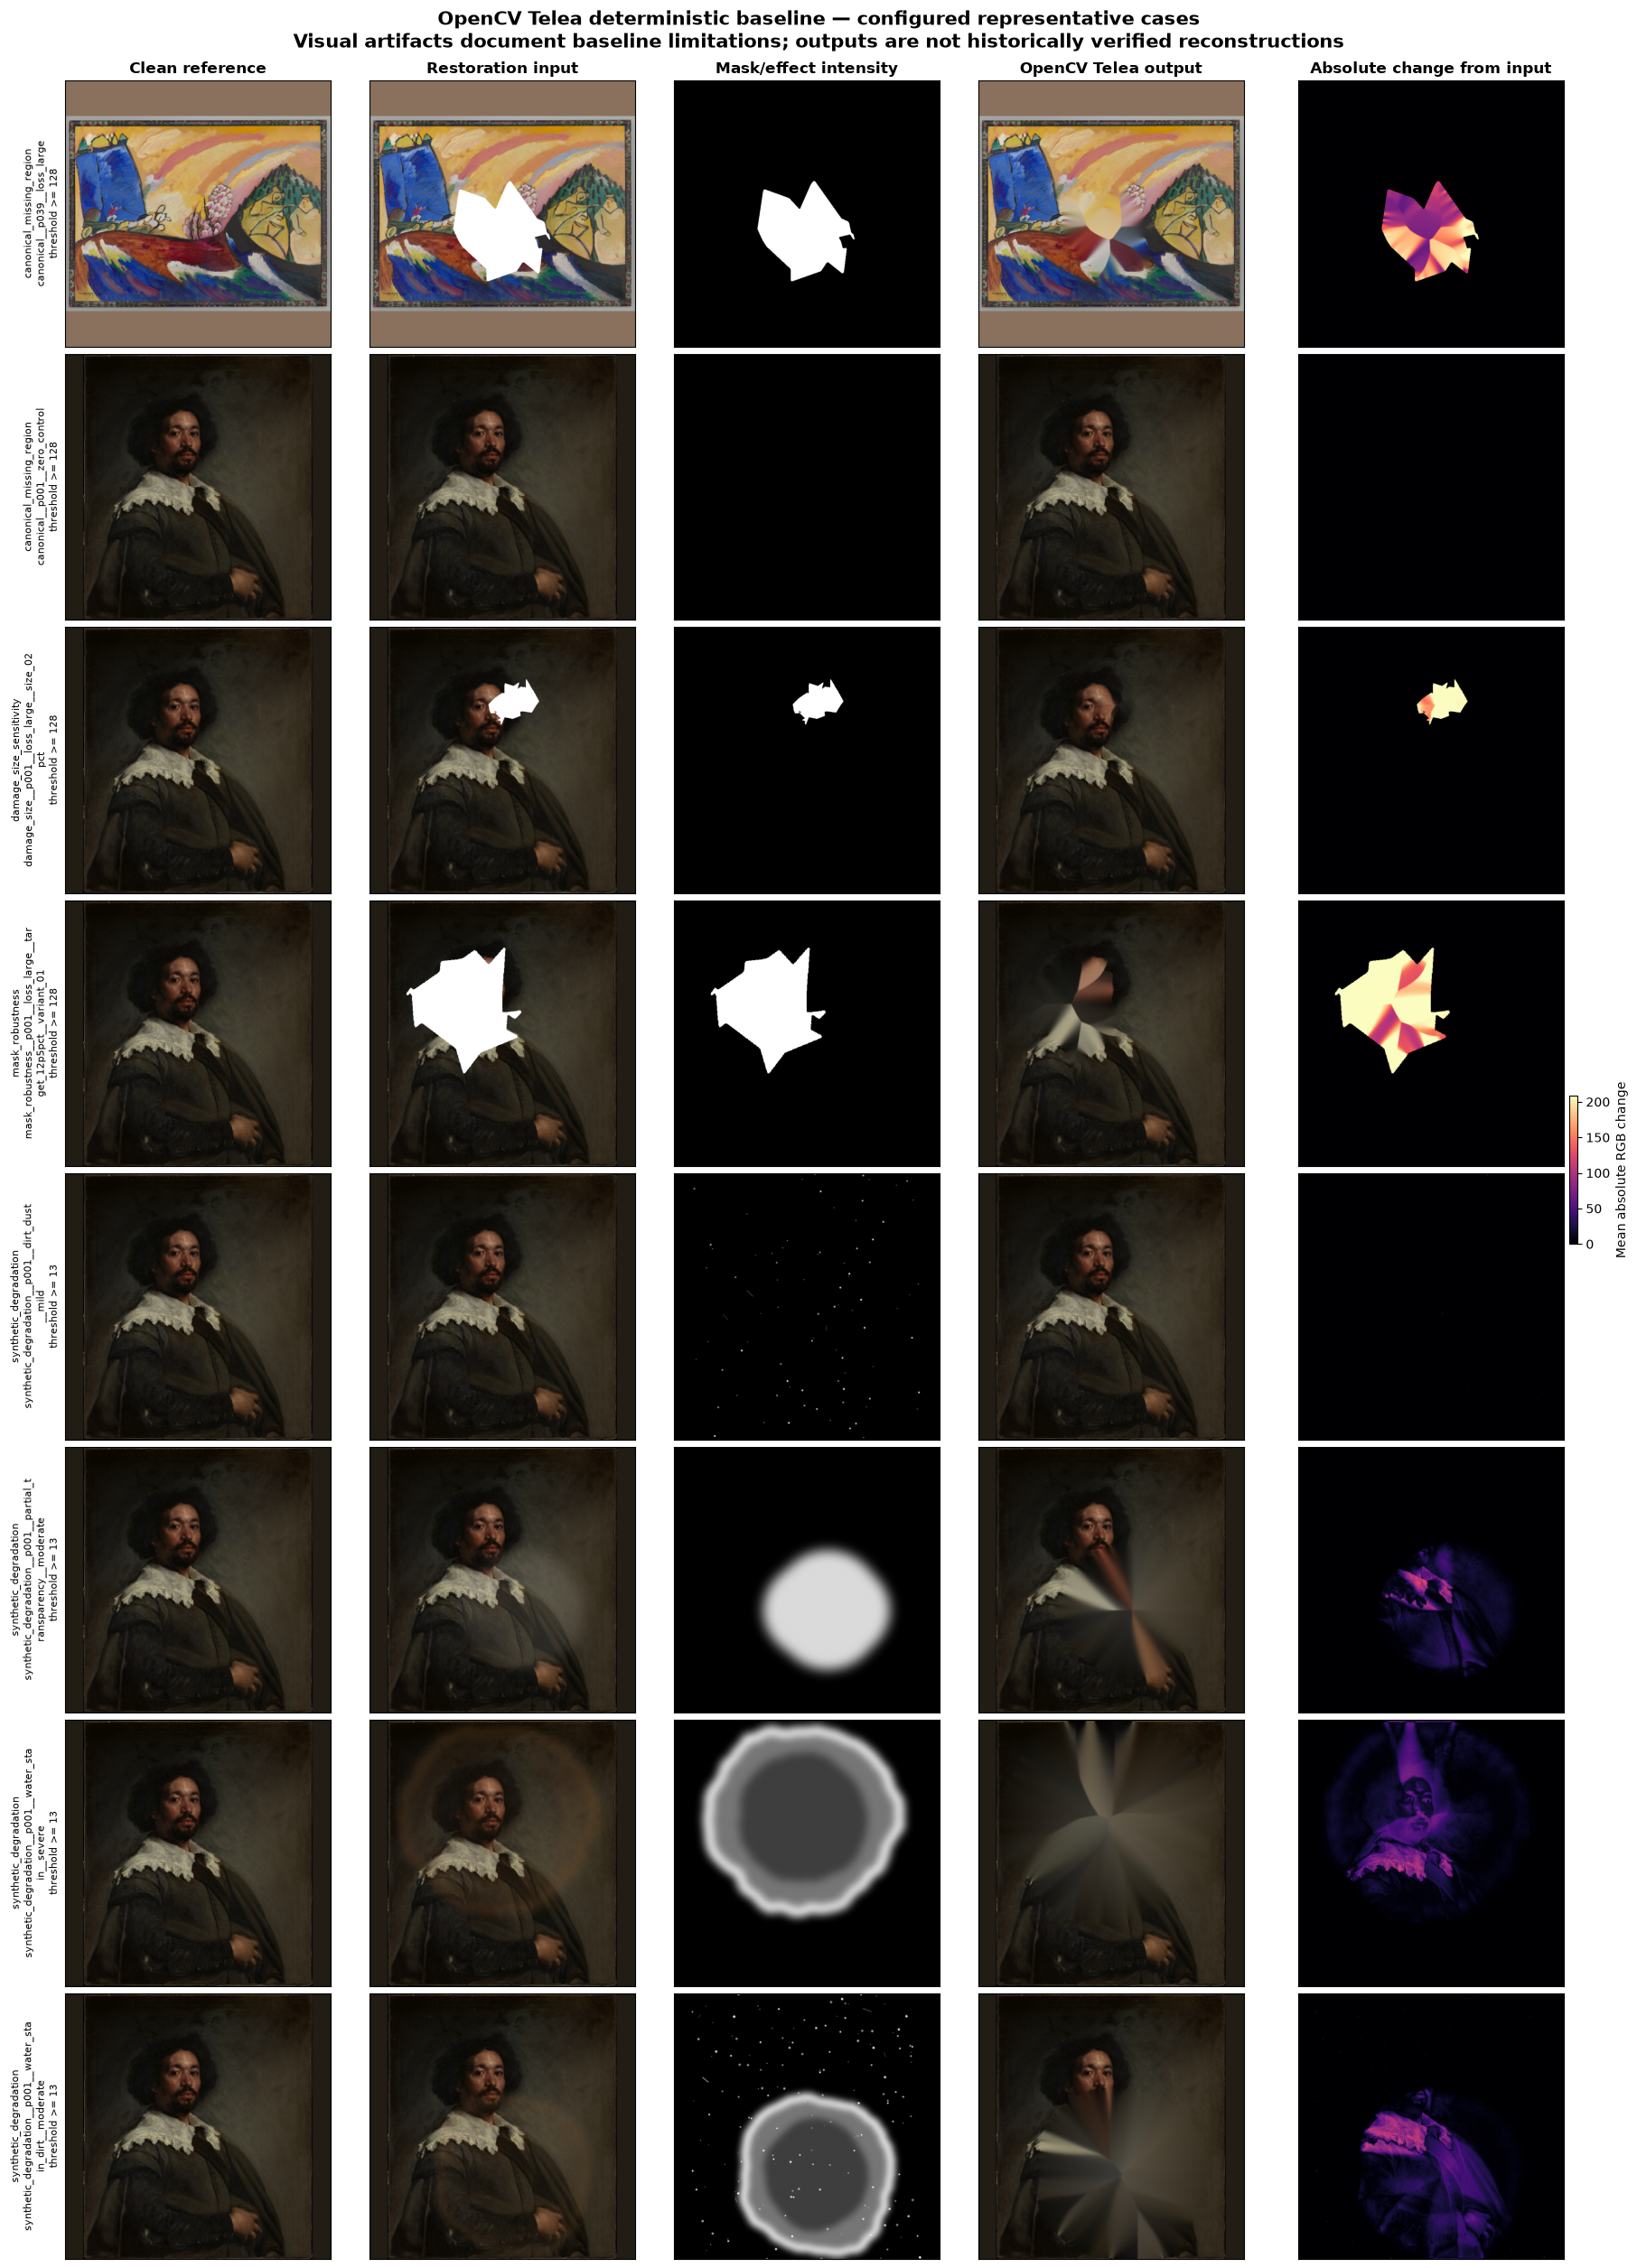

Representative restoration figure persisted.
Path: outputs/09_opencv_telea_restoration/figures/restoration_examples.png
Dimensions: (2718, 3767)
Mode: RGBA
Format: PNG
Shared change-map maximum: 208.667


In [27]:
import os
import textwrap


# ---------------------------------------------------------------------------
# Use one shared scale for all absolute-change panels
# ---------------------------------------------------------------------------

representative_change_values = np.concatenate(
    [
        row[
            "input_change"
        ].reshape(
            -1
        )
        for row
        in representative_visual_rows
    ]
)

representative_change_vmax = float(
    np.percentile(
        representative_change_values,
        99.0,
    )
)

representative_change_vmax = max(
    representative_change_vmax,
    1.0,
)


# ---------------------------------------------------------------------------
# Render all eight configured representative cases
# ---------------------------------------------------------------------------

figure, axes = plt.subplots(
    nrows=len(
        representative_visual_rows
    ),
    ncols=5,
    figsize=(
        18,
        25,
    ),
    constrained_layout=True,
)


column_titles = [
    "Clean reference",
    "Restoration input",
    "Mask/effect intensity",
    "OpenCV Telea output",
    "Absolute change from input",
]

for column_index, title in enumerate(
    column_titles
):
    axes[
        0,
        column_index,
    ].set_title(
        title,
        fontsize=12,
        fontweight="bold",
    )


difference_artist = None

for row_index, visual_row in enumerate(
    representative_visual_rows
):
    axes[
        row_index,
        0,
    ].imshow(
        visual_row[
            "clean"
        ]
    )

    axes[
        row_index,
        1,
    ].imshow(
        visual_row[
            "input"
        ]
    )

    axes[
        row_index,
        2,
    ].imshow(
        visual_row[
            "mask_or_effect"
        ],
        cmap="gray",
        vmin=0,
        vmax=255,
    )

    axes[
        row_index,
        3,
    ].imshow(
        visual_row[
            "restored"
        ]
    )

    difference_artist = (
        axes[
            row_index,
            4,
        ]
        .imshow(
            visual_row[
                "input_change"
            ],
            cmap="magma",
            vmin=0,
            vmax=(
                representative_change_vmax
            ),
        )
    )

    wrapped_case_id = (
        textwrap.fill(
            str(
                visual_row[
                    "case_id"
                ]
            ),
            width=38,
        )
    )

    row_label = (
        str(
            visual_row[
                "experiment_id"
            ]
        )
        + "\n"
        + wrapped_case_id
        + "\n"
        + (
            "threshold >= "
            f"{int(visual_row['mask_threshold'])}"
        )
    )

    axes[
        row_index,
        0,
    ].set_ylabel(
        row_label,
        fontsize=8,
    )

    for axis in axes[
        row_index,
        :
    ]:
        axis.set_xticks([])
        axis.set_yticks([])


if difference_artist is None:
    raise RuntimeError(
        "No representative difference "
        "artist was created."
    )


colorbar = figure.colorbar(
    difference_artist,
    ax=axes[
        :,
        4,
    ],
    orientation="vertical",
    fraction=0.025,
    pad=0.02,
)

colorbar.set_label(
    "Mean absolute RGB change",
    fontsize=10,
)


figure.suptitle(
    (
        "OpenCV Telea deterministic baseline — "
        "configured representative cases\n"
        "Visual artifacts document baseline limitations; "
        "outputs are not historically verified reconstructions"
    ),
    fontsize=15,
    fontweight="bold",
)


# ---------------------------------------------------------------------------
# Atomically persist the canonical figure
# ---------------------------------------------------------------------------

OUTPUTS[
    "restoration_examples"
].parent.mkdir(
    parents=True,
    exist_ok=True,
)

temporary_figure_path = (
    OUTPUTS[
        "restoration_examples"
    ]
    .with_suffix(
        ".tmp.png"
    )
)

try:
    figure.savefig(
        temporary_figure_path,
        format="png",
        dpi=150,
        facecolor="white",
        bbox_inches="tight",
    )

    os.replace(
        temporary_figure_path,
        OUTPUTS[
            "restoration_examples"
        ],
    )
finally:
    temporary_figure_path.unlink(
        missing_ok=True
    )


plt.show()


# ---------------------------------------------------------------------------
# Reload the saved figure
# ---------------------------------------------------------------------------

with Image.open(
    OUTPUTS[
        "restoration_examples"
    ]
) as saved_figure:
    saved_figure.load()

    restoration_figure_width = (
        saved_figure.width
    )

    restoration_figure_height = (
        saved_figure.height
    )

    restoration_figure_mode = (
        saved_figure.mode
    )

    restoration_figure_format = (
        saved_figure.format
    )


print(
    "Representative restoration figure persisted."
)

print(
    "Path:",
    to_repo_relative(
        OUTPUTS[
            "restoration_examples"
        ],
        PROJECT_ROOT,
    ),
)

print(
    "Dimensions:",
    (
        restoration_figure_width,
        restoration_figure_height,
    ),
)

print(
    "Mode:",
    restoration_figure_mode,
)

print(
    "Format:",
    restoration_figure_format,
)

print(
    "Shared change-map maximum:",
    round(
        representative_change_vmax,
        3,
    ),
)

In [28]:
# ---------------------------------------------------------------------------
# Runtime-summary contract
# ---------------------------------------------------------------------------

overall_runtime_rows_df = (
    reloaded_runtime_summary_df.loc[
        reloaded_runtime_summary_df[
            "summary_scope"
        ]
        .astype(str)
        .eq(
            "overall"
        )
    ]
)

experiment_runtime_rows_df = (
    reloaded_runtime_summary_df.loc[
        reloaded_runtime_summary_df[
            "summary_scope"
        ]
        .astype(str)
        .eq(
            "experiment"
        )
    ]
)


runtime_experiment_counts = {
    str(
        row[
            "experiment_id"
        ]
    ): int(
        row[
            "case_count"
        ]
    )
    for _, row
    in experiment_runtime_rows_df.iterrows()
}


expected_runtime_experiment_counts = {
    str(
        experiment_id
    ): int(
        case_count
    )
    for experiment_id, case_count
    in EXPECTED_COUNTS[
        "eligible_case_count_by_experiment"
    ].items()
}


runtime_numeric_columns = [
    "total_runtime_seconds",
    "mean_runtime_seconds",
    "median_runtime_seconds",
    "p95_runtime_seconds",
    "max_runtime_seconds",
    "throughput_cases_per_second",
]

runtime_numeric_values = (
    reloaded_runtime_summary_df[
        runtime_numeric_columns
    ]
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
)


runtime_values_valid = bool(
    np.isfinite(
        runtime_numeric_values
        .to_numpy(
            dtype=float
        )
    )
    .all()
    and runtime_numeric_values
    .ge(0)
    .all()
    .all()
)


overall_runtime_contract_valid = bool(
    len(
        overall_runtime_rows_df
    )
    == 1
    and int(
        overall_runtime_rows_df.iloc[
            0
        ][
            "case_count"
        ]
    )
    == 410
    and int(
        overall_runtime_rows_df.iloc[
            0
        ][
            "completed_count"
        ]
    )
    == 410
    and int(
        overall_runtime_rows_df.iloc[
            0
        ][
            "failed_count"
        ]
    )
    == 0
    and str(
        overall_runtime_rows_df.iloc[
            0
        ][
            "status"
        ]
    )
    == "completed"
)


# ---------------------------------------------------------------------------
# Representative and figure contracts
# ---------------------------------------------------------------------------

representative_experiment_counts = {
    str(
        experiment_id
    ): int(
        case_count
    )
    for experiment_id, case_count
    in representative_analysis_df[
        "experiment_id"
    ]
    .value_counts()
    .sort_index()
    .items()
}

expected_representative_experiment_counts = {
    "canonical_missing_region": 2,
    "damage_size_sensitivity": 1,
    "mask_robustness": 1,
    "synthetic_degradation": 4,
}


representative_validation_valid = bool(
    len(
        representative_analysis_df
    )
    == EXPECTED_COUNTS[
        "representative_case_count"
    ]
    and representative_analysis_df[
        "validation_passed"
    ]
    .astype(bool)
    .all()
    and pd.to_numeric(
        representative_analysis_df[
            "changed_outside_mask_pixels"
        ],
        errors="coerce",
    )
    .eq(0)
    .all()
)


figure_file_valid = bool(
    OUTPUTS[
        "restoration_examples"
    ].is_file()
    and OUTPUTS[
        "restoration_examples"
    ].stat().st_size
    > 0
    and restoration_figure_format
    == "PNG"
    and restoration_figure_width
    >= 1000
    and restoration_figure_height
    >= 1000
)


observed_metrics_files = set(
    path.resolve()
    for path
    in OUTPUTS[
        "runtime_summary"
    ].parent.rglob(
        "*"
    )
    if path.is_file()
)

observed_figure_files = set(
    path.resolve()
    for path
    in OUTPUTS[
        "restoration_examples"
    ].parent.rglob(
        "*"
    )
    if path.is_file()
)

expected_metrics_files = {
    OUTPUTS[
        "runtime_summary"
    ].resolve(),
}

expected_figure_files = {
    OUTPUTS[
        "restoration_examples"
    ].resolve(),
}


# ---------------------------------------------------------------------------
# Register Batch 6 checks
# ---------------------------------------------------------------------------

def add_batch_6_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage=(
            "batch_6_analysis_visualization"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=passed,
        details=details,
    )


add_batch_6_check(
    check_id=(
        "runtime_summary_schema"
    ),
    description=(
        "The persisted runtime summary "
        "matches its normalized exact schema."
    ),
    expected={
        "schema_valid": True,
        "row_count": 5,
    },
    observed={
        "schema_valid": (
            reloaded_runtime_schema_result.passed
        ),
        "row_count": len(
            reloaded_runtime_summary_df
        ),
    },
    passed=(
        reloaded_runtime_schema_result.passed
        and len(
            reloaded_runtime_summary_df
        )
        == 5
    ),
)


add_batch_6_check(
    check_id=(
        "runtime_summary_scopes"
    ),
    description=(
        "Runtime evidence contains one "
        "overall row and four experiment rows."
    ),
    expected={
        "overall_rows": 1,
        "experiment_rows": 4,
        "experiment_counts": (
            expected_runtime_experiment_counts
        ),
    },
    observed={
        "overall_rows": len(
            overall_runtime_rows_df
        ),
        "experiment_rows": len(
            experiment_runtime_rows_df
        ),
        "experiment_counts": (
            runtime_experiment_counts
        ),
    },
    passed=(
        len(
            overall_runtime_rows_df
        )
        == 1
        and len(
            experiment_runtime_rows_df
        )
        == 4
        and runtime_experiment_counts
        == expected_runtime_experiment_counts
    ),
)


add_batch_6_check(
    check_id=(
        "runtime_completion_evidence"
    ),
    description=(
        "Runtime evidence records all 410 "
        "cases as completed with finite "
        "non-negative measurements."
    ),
    expected={
        "case_count": 410,
        "completed_count": 410,
        "failed_count": 0,
        "runtime_values_valid": True,
    },
    observed={
        "overall_contract_valid": (
            overall_runtime_contract_valid
        ),
        "runtime_values_valid": (
            runtime_values_valid
        ),
    },
    passed=(
        overall_runtime_contract_valid
        and runtime_values_valid
    ),
)


add_batch_6_check(
    check_id=(
        "representative_case_selection"
    ),
    description=(
        "The preview uses exactly the eight "
        "configured representative cases "
        "across all four experiment branches."
    ),
    expected={
        "case_count": 8,
        "experiment_counts": (
            expected_representative_experiment_counts
        ),
        "ordered_case_ids": (
            representative_case_ids
        ),
    },
    observed={
        "case_count": len(
            representative_analysis_df
        ),
        "experiment_counts": (
            representative_experiment_counts
        ),
        "ordered_case_ids": (
            observed_representative_case_ids
        ),
    },
    passed=(
        len(
            representative_analysis_df
        )
        == 8
        and representative_experiment_counts
        == expected_representative_experiment_counts
        and observed_representative_case_ids
        == representative_case_ids
    ),
)


add_batch_6_check(
    check_id=(
        "representative_case_validation"
    ),
    description=(
        "Every previewed restoration passed "
        "full output validation and preserves "
        "outside-mask invariance."
    ),
    expected={
        "validated_cases": 8,
        "changed_outside_pixels": 0,
    },
    observed={
        "validated_cases": int(
            representative_analysis_df[
                "validation_passed"
            ].sum()
        ),
        "changed_outside_pixels": int(
            pd.to_numeric(
                representative_analysis_df[
                    "changed_outside_mask_pixels"
                ],
                errors="coerce",
            )
            .sum()
        ),
    },
    passed=(
        representative_validation_valid
    ),
)


add_batch_6_check(
    check_id=(
        "representative_figure_contract"
    ),
    description=(
        "The representative figure is a "
        "readable, non-empty, sufficiently "
        "detailed PNG."
    ),
    expected={
        "file_exists": True,
        "format": "PNG",
        "minimum_width": 1000,
        "minimum_height": 1000,
    },
    observed={
        "file_exists": OUTPUTS[
            "restoration_examples"
        ].is_file(),
        "file_size_bytes": (
            OUTPUTS[
                "restoration_examples"
            ].stat().st_size
            if OUTPUTS[
                "restoration_examples"
            ].is_file()
            else 0
        ),
        "format": (
            restoration_figure_format
        ),
        "width": (
            restoration_figure_width
        ),
        "height": (
            restoration_figure_height
        ),
        "mode": (
            restoration_figure_mode
        ),
    },
    passed=(
        figure_file_valid
    ),
)


add_batch_6_check(
    check_id=(
        "analysis_output_filesystem_scope"
    ),
    description=(
        "The metrics and figures directories "
        "contain only the two approved "
        "Batch 6 outputs."
    ),
    expected={
        "metrics_files": [
            to_repo_relative(
                OUTPUTS[
                    "runtime_summary"
                ],
                PROJECT_ROOT,
            ),
        ],
        "figure_files": [
            to_repo_relative(
                OUTPUTS[
                    "restoration_examples"
                ],
                PROJECT_ROOT,
            ),
        ],
    },
    observed={
        "metrics_files": sorted(
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path
            in observed_metrics_files
        ),
        "figure_files": sorted(
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path
            in observed_figure_files
        ),
    },
    passed=(
        observed_metrics_files
        == expected_metrics_files
        and observed_figure_files
        == expected_figure_files
    ),
)


all_validation_checks_df = (
    VALIDATION.to_dataframe()
)

batch_6_checks_df = (
    all_validation_checks_df.loc[
        all_validation_checks_df[
            "validation_stage"
        ]
        == "batch_6_analysis_visualization"
    ]
    .drop_duplicates(
        subset=[
            "check_id",
        ],
        keep="last",
    )
    .reset_index(
        drop=True
    )
)


VALIDATION.raise_for_blocking()


print(
    "Batch 6 validation checks:"
)

display(
    batch_6_checks_df[
        [
            "check_id",
            "expected",
            "observed",
            "passed",
        ]
    ]
)


print(
    "\nFinal runtime summary:"
)

display(
    reloaded_runtime_summary_df
)


print(
    "\nRepresentative-case evidence:"
)

display(
    representative_analysis_df[
        [
            "case_id",
            "experiment_id",
            "mask_threshold",
            "execution_action",
            "runtime_seconds",
            "validation_passed",
        ]
    ]
)


print(
    "\nBatch 6 completed successfully."
)

print(
    "Checks:",
    len(
        batch_6_checks_df
    ),
)

print(
    "Passed:",
    int(
        batch_6_checks_df[
            "passed"
        ].sum()
    ),
)

print(
    "Runtime-summary rows:",
    len(
        reloaded_runtime_summary_df
    ),
)

print(
    "Representative cases:",
    len(
        representative_analysis_df
    ),
)

print(
    "Next approved stage: "
    "Batch 7 - canonical persistence, "
    "manifests, and validation handoff."
)

Batch 6 validation checks:


,check_id,expected,observed,passed
0,runtime_summary_schema,"{""row_count"": 5, ""schema_valid"": true}","{""row_count"": 5, ""schema_valid"": true}",True
1,runtime_summary_scopes,"{""experiment_counts"": {""canonical_missing_regi...","{""experiment_counts"": {""canonical_missing_regi...",True
2,runtime_completion_evidence,"{""case_count"": 410, ""completed_count"": 410, ""f...","{""overall_contract_valid"": true, ""runtime_valu...",True
3,representative_case_selection,"{""case_count"": 8, ""experiment_counts"": {""canon...","{""case_count"": 8, ""experiment_counts"": {""canon...",True
4,representative_case_validation,"{""changed_outside_pixels"": 0, ""validated_cases...","{""changed_outside_pixels"": 0, ""validated_cases...",True
5,representative_figure_contract,"{""file_exists"": true, ""format"": ""PNG"", ""minimu...","{""file_exists"": true, ""file_size_bytes"": 64625...",True
6,analysis_output_filesystem_scope,"{""figure_files"": [""outputs/09_opencv_telea_res...","{""figure_files"": [""outputs/09_opencv_telea_res...",True



Final runtime summary:


,summary_scope,experiment_id,case_count,completed_count,failed_count,total_runtime_seconds,mean_runtime_seconds,median_runtime_seconds,p95_runtime_seconds,max_runtime_seconds,throughput_cases_per_second,status
0,overall,all,410,410,0,185.613548,0.452716,0.423579,0.697902,1.019818,2.208890,completed
1,experiment,canonical_missing_region,250,250,0,104.413864,0.417655,0.410636,0.568627,0.714920,2.394318,completed
2,experiment,damage_size_sensitivity,35,35,0,17.550965,0.501456,0.483976,0.735717,0.833566,1.994192,completed
3,experiment,mask_robustness,75,75,0,32.703586,0.436048,0.397811,0.616086,0.711408,2.293327,completed
4,experiment,synthetic_degradation,50,50,0,30.945133,0.618903,0.615850,0.912572,1.019818,1.615763,completed



Representative-case evidence:


,case_id,experiment_id,mask_threshold,execution_action,runtime_seconds,validation_passed
0,canonical__p039__loss_large,canonical_missing_region,128,telea_inpaint,0.445366,True
1,canonical__p001__zero_control,canonical_missing_region,128,identity_noop,0.479488,True
2,damage_size__p001__loss_large__size_02pct,damage_size_sensitivity,128,telea_inpaint,0.711965,True
3,mask_robustness__p001__loss_large__target_12p5...,mask_robustness,128,telea_inpaint,0.612602,True
4,synthetic_degradation__p001__dirt_dust__mild,synthetic_degradation,13,telea_inpaint,0.527866,True
5,synthetic_degradation__p001__partial_transpare...,synthetic_degradation,13,telea_inpaint,0.778765,True
6,synthetic_degradation__p001__water_stain__severe,synthetic_degradation,13,telea_inpaint,1.019818,True
7,synthetic_degradation__p001__water_stain_dirt_...,synthetic_degradation,13,telea_inpaint,0.897906,True



Batch 6 completed successfully.
Checks: 7
Passed: 7
Runtime-summary rows: 5
Representative cases: 8
Next approved stage: Batch 7 - canonical persistence, manifests, and validation handoff.


## Batch 7 — Canonical persistence and provisional handoff

This batch persists and validates the complete downstream-facing Notebook 09 handoff:

- `data/restorations.csv`;
- `metrics/runtime_summary.csv`;
- `figures/restoration_examples.png`;
- 410 files under `images/restored/`;
- `validation/checks.csv`;
- `manifests/artifacts.csv`;
- `manifests/run_manifest.json`.

The artifact manifest contains five records: restoration records, restored-image directory, runtime summary, representative figure, and validation evidence.

The run manifest remains in a provisional `running` state until Batch 8 completes the roadmap audit and project-path registry update.

Checkpoint and smoke-test files remain isolated under `work/` during this batch. They are not canonical outputs and will be removed only after the final completion gate passes.

In [30]:
from restoration_eval.manifests import (
    RUN_MANIFEST_SCHEMA_VERSION,
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
    configuration_checksums,
    sha256_path,
    write_artifact_manifest,
    write_run_manifest,
)

from restoration_eval.schemas import (
    RUN_MANIFEST_REQUIRED_KEYS,
)


# ---------------------------------------------------------------------------
# Approved validation and output cardinalities
# ---------------------------------------------------------------------------

EXPECTED_VALIDATION_STAGE_COUNTS = {
    "batch_1_preflight": 19,
    "batch_2_input_loading": 17,
    "batch_3_smoke_test": 11,
    "batch_4_full_execution": 9,
    "batch_5_scientific_validation": 9,
    "batch_6_analysis_visualization": 7,
}

EXPECTED_CONSOLIDATED_VALIDATION_ROWS = sum(
    EXPECTED_VALIDATION_STAGE_COUNTS.values()
)

EXPECTED_ARTIFACT_RECORD_COUNT = (
    EXPECTED_COUNTS[
        "artifact_record_count"
    ]
)

EXPECTED_CANONICAL_OUTPUT_FILE_COUNT = (
    EXPECTED_COUNTS[
        "total_output_file_count"
    ]
)


# ---------------------------------------------------------------------------
# Pre-persistence validation gate
# ---------------------------------------------------------------------------

if not VALIDATION.overall_passed:
    raise RuntimeError(
        "The cumulative Notebook 09 "
        "validation gate has not passed."
    )


validation_checks_df = (
    VALIDATION.to_dataframe()
    .drop_duplicates(
        subset=[
            "validation_stage",
            "check_id",
        ],
        keep="last",
    )
    .reset_index(
        drop=True
    )
)


observed_validation_stage_counts = {
    str(
        validation_stage
    ): int(
        count
    )
    for validation_stage, count
    in validation_checks_df[
        "validation_stage"
    ]
    .value_counts()
    .sort_index()
    .items()
}


print(
    "Observed validation stage counts:",
    observed_validation_stage_counts,
)


if (
    observed_validation_stage_counts
    != EXPECTED_VALIDATION_STAGE_COUNTS
):
    raise RuntimeError(
        "Consolidated validation stage counts "
        "do not match the approved Batch 1-6 "
        "contract."
    )


validation_schema_result = (
    validate_dataframe(
        validation_checks_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)

if not validation_schema_result.passed:
    raise RuntimeError(
        "Consolidated validation evidence "
        "does not match validation_checks.v1."
    )


if (
    len(
        validation_checks_df
    )
    != EXPECTED_CONSOLIDATED_VALIDATION_ROWS
):
    raise RuntimeError(
        "Expected exactly "
        f"{EXPECTED_CONSOLIDATED_VALIDATION_ROWS} "
        "unique Batch 1-6 validation rows; "
        f"observed {len(validation_checks_df)}."
    )


# ---------------------------------------------------------------------------
# Validate ownership of every declared path
# ---------------------------------------------------------------------------

output_ownership_failures = []

for output_key, output_path in (
    OUTPUTS.items()
):
    try:
        validated_path = (
            require_notebook_output_path(
                output_path,
                NOTEBOOK_STEM,
                PROJECT_ROOT,
            )
        )

        if (
            validated_path
            != output_path.resolve()
        ):
            output_ownership_failures.append(
                {
                    "output_key": (
                        output_key
                    ),
                    "path": str(
                        output_path
                    ),
                    "issue": (
                        "resolved_path_mismatch"
                    ),
                }
            )

    except Exception as exc:
        output_ownership_failures.append(
            {
                "output_key": (
                    output_key
                ),
                "path": str(
                    output_path
                ),
                "issue": (
                    f"{type(exc).__name__}: "
                    f"{exc}"
                ),
            }
        )


if output_ownership_failures:
    raise RuntimeError(
        "One or more Notebook 09 output "
        "paths violate output ownership: "
        f"{output_ownership_failures}"
    )


# ---------------------------------------------------------------------------
# Persist canonical restoration and validation tables
# ---------------------------------------------------------------------------

canonical_restorations_df = (
    validation_records_df
    .copy()
    .reset_index(
        drop=True
    )
)

validate_restoration_records(
    canonical_restorations_df
)


write_dataframe_atomic(
    canonical_restorations_df,
    OUTPUTS[
        "restorations"
    ],
)

write_dataframe_atomic(
    validation_checks_df,
    OUTPUTS[
        "validation_checks"
    ],
)


# ---------------------------------------------------------------------------
# Independently reload every canonical table
# ---------------------------------------------------------------------------

restorations_reloaded_df = (
    pd.read_csv(
        OUTPUTS[
            "restorations"
        ],
        keep_default_na=False,
    )
)

runtime_summary_reloaded_df = (
    pd.read_csv(
        OUTPUTS[
            "runtime_summary"
        ],
        keep_default_na=False,
    )
)

validation_checks_reloaded_df = (
    pd.read_csv(
        OUTPUTS[
            "validation_checks"
        ],
        keep_default_na=False,
    )
)


restorations_reload_result = (
    validate_dataframe(
        restorations_reloaded_df,
        RESTORATIONS_SCHEMA,
        allow_extra_columns=False,
    )
)

runtime_summary_reload_result = (
    validate_dataframe(
        runtime_summary_reloaded_df,
        RESTORATION_RUNTIME_SUMMARY_SCHEMA,
        allow_extra_columns=False,
    )
)

validation_checks_reload_result = (
    validate_dataframe(
        validation_checks_reloaded_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)


if not restorations_reload_result.passed:
    raise RuntimeError(
        "Persisted restorations.csv does "
        "not match restorations.v1."
    )

if not runtime_summary_reload_result.passed:
    raise RuntimeError(
        "Persisted runtime_summary.csv does "
        "not match its normalized schema."
    )

if not validation_checks_reload_result.passed:
    raise RuntimeError(
        "Persisted checks.csv does not "
        "match validation_checks.v1."
    )


# ---------------------------------------------------------------------------
# Reload the representative figure
# ---------------------------------------------------------------------------

with Image.open(
    OUTPUTS[
        "restoration_examples"
    ]
) as persisted_figure:
    persisted_figure.load()

    persisted_figure_evidence = {
        "format": str(
            persisted_figure.format
        ),
        "mode": str(
            persisted_figure.mode
        ),
        "width": int(
            persisted_figure.width
        ),
        "height": int(
            persisted_figure.height
        ),
        "size_bytes": int(
            OUTPUTS[
                "restoration_examples"
            ]
            .stat()
            .st_size
        ),
        "sha256": (
            sha256_file(
                OUTPUTS[
                    "restoration_examples"
                ]
            )
        ),
    }


print(
    "Canonical tables persisted and reloaded."
)

print(
    "Restoration rows:",
    len(
        restorations_reloaded_df
    ),
)

print(
    "Runtime-summary rows:",
    len(
        runtime_summary_reloaded_df
    ),
)

print(
    "Consolidated validation rows:",
    len(
        validation_checks_reloaded_df
    ),
)

print(
    "Validation stage counts:",
    observed_validation_stage_counts,
)

print(
    "Representative figure:",
    persisted_figure_evidence,
)

Observed validation stage counts: {'batch_1_preflight': 19, 'batch_2_input_loading': 17, 'batch_3_smoke_test': 11, 'batch_4_full_execution': 9, 'batch_5_scientific_validation': 9, 'batch_6_analysis_visualization': 7}
Canonical tables persisted and reloaded.
Restoration rows: 410
Runtime-summary rows: 5
Consolidated validation rows: 72
Validation stage counts: {'batch_1_preflight': 19, 'batch_2_input_loading': 17, 'batch_3_smoke_test': 11, 'batch_4_full_execution': 9, 'batch_5_scientific_validation': 9, 'batch_6_analysis_visualization': 7}
Representative figure: {'format': 'PNG', 'mode': 'RGBA', 'width': 2718, 'height': 3767, 'size_bytes': 6462582, 'sha256': '3c5eaa21afef37dbe30f093de4e3ae65868dfebc9c7cd1d1488d2de5f0168527'}


In [31]:
# ---------------------------------------------------------------------------
# Stable identity and reload evidence
# ---------------------------------------------------------------------------

expected_restoration_case_ids = set(
    validation_records_df[
        "case_id"
    ].astype(str)
)

reloaded_restoration_case_ids = set(
    restorations_reloaded_df[
        "case_id"
    ].astype(str)
)


expected_restoration_signatures = {
    str(
        row[
            "case_id"
        ]
    ): (
        str(
            row[
                "restored_path"
            ]
        ),
        str(
            row[
                "restored_sha256"
            ]
        ),
        str(
            row[
                "status"
            ]
        ),
    )
    for _, row
    in validation_records_df.iterrows()
}

reloaded_restoration_signatures = {
    str(
        row[
            "case_id"
        ]
    ): (
        str(
            row[
                "restored_path"
            ]
        ),
        str(
            row[
                "restored_sha256"
            ]
        ),
        str(
            row[
                "status"
            ]
        ),
    )
    for _, row
    in restorations_reloaded_df.iterrows()
}


expected_validation_keys = {
    (
        str(
            row[
                "validation_stage"
            ]
        ),
        str(
            row[
                "check_id"
            ]
        ),
    )
    for _, row
    in validation_checks_df.iterrows()
}

reloaded_validation_keys = {
    (
        str(
            row[
                "validation_stage"
            ]
        ),
        str(
            row[
                "check_id"
            ]
        ),
    )
    for _, row
    in validation_checks_reloaded_df.iterrows()
}


all_reloaded_validation_checks_passed = bool(
    validation_checks_reloaded_df[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq(
        "true"
    )
    .all()
)


# ---------------------------------------------------------------------------
# Canonical image and work-file scopes
# ---------------------------------------------------------------------------

persisted_restored_files = set(
    path.resolve()
    for path
    in OUTPUTS[
        "restored_images"
    ].rglob(
        "*"
    )
    if path.is_file()
)


expected_persisted_restored_files = set(
    resolve_repo_path(
        relative_path,
        PROJECT_ROOT,
        must_exist=False,
    ).resolve()
    for relative_path
    in restorations_reloaded_df[
        "restored_path"
    ].astype(str)
)


observed_smoke_work_files = set(
    path.resolve()
    for path
    in OUTPUTS[
        "smoke_directory"
    ].rglob(
        "*"
    )
    if path.is_file()
)


observed_work_files = set(
    path.resolve()
    for path
    in (
        OUTPUT_ROOT
        / "work"
    ).rglob(
        "*"
    )
    if path.is_file()
)


expected_work_files = (
    observed_smoke_work_files
    | {
        OUTPUTS[
            "checkpoint"
        ].resolve(),
    }
)


temporary_work_files = {
    path
    for path
    in observed_work_files
    if (
        ".tmp"
        in path.name.lower()
        or path.suffix.lower()
        in {
            ".temp",
            ".part",
        }
    )
}


# ---------------------------------------------------------------------------
# Separate persistence validation layer
# ---------------------------------------------------------------------------

PERSISTENCE_VALIDATION = (
    ValidationCollector()
)


def add_persistence_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    PERSISTENCE_VALIDATION.add(
        validation_stage=(
            "canonical_persistence"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=passed,
        details=details,
    )


add_persistence_check(
    check_id=(
        "output_path_ownership"
    ),
    description=(
        "Every declared Notebook 09 path "
        "resolves inside its exact owned "
        "output root."
    ),
    expected={
        "ownership_failures": 0,
    },
    observed={
        "ownership_failures": len(
            output_ownership_failures
        ),
    },
    passed=(
        not output_ownership_failures
    ),
    details=(
        output_ownership_failures
    ),
)


add_persistence_check(
    check_id=(
        "restorations_csv_reload"
    ),
    description=(
        "restorations.csv reloads under "
        "restorations.v1 with all 410 "
        "normalized completed records."
    ),
    expected={
        "rows": 410,
        "unique_case_ids": 410,
        "schema_valid": True,
        "signatures_match": True,
        "completed_rows": 410,
    },
    observed={
        "rows": len(
            restorations_reloaded_df
        ),
        "unique_case_ids": int(
            restorations_reloaded_df[
                "case_id"
            ].nunique()
        ),
        "schema_valid": (
            restorations_reload_result.passed
        ),
        "signatures_match": (
            reloaded_restoration_signatures
            == expected_restoration_signatures
        ),
        "completed_rows": int(
            restorations_reloaded_df[
                "status"
            ]
            .astype(str)
            .eq(
                "completed"
            )
            .sum()
        ),
    },
    passed=(
        restorations_reload_result.passed
        and len(
            restorations_reloaded_df
        )
        == 410
        and restorations_reloaded_df[
            "case_id"
        ].is_unique
        and reloaded_restoration_case_ids
        == expected_restoration_case_ids
        and reloaded_restoration_signatures
        == expected_restoration_signatures
        and restorations_reloaded_df[
            "status"
        ]
        .astype(str)
        .eq(
            "completed"
        )
        .all()
    ),
)


add_persistence_check(
    check_id=(
        "runtime_summary_csv_reload"
    ),
    description=(
        "runtime_summary.csv reloads under "
        "restoration_runtime_summary.v1 "
        "with five completed summary rows."
    ),
    expected={
        "rows": 5,
        "schema_valid": True,
        "completed_status_rows": 5,
    },
    observed={
        "rows": len(
            runtime_summary_reloaded_df
        ),
        "schema_valid": (
            runtime_summary_reload_result.passed
        ),
        "completed_status_rows": int(
            runtime_summary_reloaded_df[
                "status"
            ]
            .astype(str)
            .eq(
                "completed"
            )
            .sum()
        ),
    },
    passed=(
        runtime_summary_reload_result.passed
        and len(
            runtime_summary_reloaded_df
        )
        == 5
        and runtime_summary_reloaded_df[
            "status"
        ]
        .astype(str)
        .eq(
            "completed"
        )
        .all()
    ),
)


add_persistence_check(
    check_id=(
        "validation_csv_reload"
    ),
    description=(
        "checks.csv reloads under "
        "validation_checks.v1 with all "
        "72 unique passed Batch 1-6 checks."
    ),
    expected={
        "rows": (
            EXPECTED_CONSOLIDATED_VALIDATION_ROWS
        ),
        "schema_valid": True,
        "keys_match": True,
        "all_passed": True,
    },
    observed={
        "rows": len(
            validation_checks_reloaded_df
        ),
        "schema_valid": (
            validation_checks_reload_result.passed
        ),
        "keys_match": (
            reloaded_validation_keys
            == expected_validation_keys
        ),
        "all_passed": (
            all_reloaded_validation_checks_passed
        ),
    },
    passed=(
        validation_checks_reload_result.passed
        and len(
            validation_checks_reloaded_df
        )
        == EXPECTED_CONSOLIDATED_VALIDATION_ROWS
        and reloaded_validation_keys
        == expected_validation_keys
        and all_reloaded_validation_checks_passed
    ),
)


add_persistence_check(
    check_id=(
        "restored_image_directory"
    ),
    description=(
        "The canonical restored-image "
        "directory contains exactly the "
        "410 paths declared by restorations.csv."
    ),
    expected={
        "recorded_files": 410,
        "observed_files": 410,
        "exact_set": True,
    },
    observed={
        "recorded_files": len(
            expected_persisted_restored_files
        ),
        "observed_files": len(
            persisted_restored_files
        ),
        "exact_set": (
            persisted_restored_files
            == expected_persisted_restored_files
        ),
    },
    passed=(
        len(
            persisted_restored_files
        )
        == 410
        and persisted_restored_files
        == expected_persisted_restored_files
    ),
)


add_persistence_check(
    check_id=(
        "representative_figure_reload"
    ),
    description=(
        "The representative restoration "
        "figure reloads as the validated "
        "non-empty PNG produced in Batch 6."
    ),
    expected={
        "format": "PNG",
        "minimum_width": 1000,
        "minimum_height": 1000,
    },
    observed=(
        persisted_figure_evidence
    ),
    passed=(
        persisted_figure_evidence[
            "format"
        ]
        == "PNG"
        and persisted_figure_evidence[
            "width"
        ]
        >= 1000
        and persisted_figure_evidence[
            "height"
        ]
        >= 1000
        and persisted_figure_evidence[
            "size_bytes"
        ]
        > 0
    ),
)


add_persistence_check(
    check_id=(
        "temporary_work_isolation"
    ),
    description=(
        "The checkpoint and four smoke PNGs "
        "remain isolated under work/ with "
        "no temporary partial files."
    ),
    expected={
        "work_files": 5,
        "smoke_files": 4,
        "checkpoint_exists": True,
        "unexpected_work_files": 0,
        "temporary_files": 0,
    },
    observed={
        "work_files": len(
            observed_work_files
        ),
        "smoke_files": len(
            observed_smoke_work_files
        ),
        "checkpoint_exists": OUTPUTS[
            "checkpoint"
        ].is_file(),
        "unexpected_work_files": len(
            observed_work_files
            - expected_work_files
        ),
        "temporary_files": len(
            temporary_work_files
        ),
    },
    passed=(
        len(
            observed_work_files
        )
        == 5
        and len(
            observed_smoke_work_files
        )
        == 4
        and OUTPUTS[
            "checkpoint"
        ].is_file()
        and observed_work_files
        == expected_work_files
        and not temporary_work_files
    ),
)


persistence_checks_df = (
    PERSISTENCE_VALIDATION
    .to_dataframe()
)

PERSISTENCE_VALIDATION.raise_for_blocking()


print(
    "Canonical persistence validation passed."
)

print(
    "Checks:",
    len(
        persistence_checks_df
    ),
)

print(
    "Passed:",
    int(
        persistence_checks_df[
            "passed"
        ].sum()
    ),
)

display(
    persistence_checks_df[
        [
            "check_id",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

Canonical persistence validation passed.
Checks: 7
Passed: 7


,check_id,expected,observed,passed
0,output_path_ownership,"{""ownership_failures"": 0}","{""ownership_failures"": 0}",True
1,restorations_csv_reload,"{""completed_rows"": 410, ""rows"": 410, ""schema_v...","{""completed_rows"": 410, ""rows"": 410, ""schema_v...",True
2,runtime_summary_csv_reload,"{""completed_status_rows"": 5, ""rows"": 5, ""schem...","{""completed_status_rows"": 5, ""rows"": 5, ""schem...",True
3,validation_csv_reload,"{""all_passed"": true, ""keys_match"": true, ""rows...","{""all_passed"": true, ""keys_match"": true, ""rows...",True
4,restored_image_directory,"{""exact_set"": true, ""observed_files"": 410, ""re...","{""exact_set"": true, ""observed_files"": 410, ""re...",True
5,representative_figure_reload,"{""format"": ""PNG"", ""minimum_height"": 1000, ""min...","{""format"": ""PNG"", ""height"": 3767, ""mode"": ""RGB...",True
6,temporary_work_isolation,"{""checkpoint_exists"": true, ""smoke_files"": 4, ...","{""checkpoint_exists"": true, ""smoke_files"": 4, ...",True


In [33]:
# ---------------------------------------------------------------------------
# Notebook 09 artifact identity
# ---------------------------------------------------------------------------

DATASET_SCOPE = (
    telea_config[
        "dataset"
    ][
        "dataset_scope"
    ]
)

RUN_EXPERIMENT_ID = (
    telea_config[
        "dataset"
    ][
        "experiment_id"
    ]
)


# ---------------------------------------------------------------------------
# Build the five normalized artifact records
# ---------------------------------------------------------------------------

artifact_specifications = [
    {
        "artifact_key": (
            "opencv_telea.restorations"
        ),
        "path": OUTPUTS[
            "restorations"
        ],
        "artifact_type": "table",
        "artifact_role": (
            "primary_restoration_records"
        ),
        "schema_version": (
            RESTORATIONS_SCHEMA.version
        ),
        "row_count": 410,
    },
    {
        "artifact_key": (
            "opencv_telea.restored_images"
        ),
        "path": OUTPUTS[
            "restored_images"
        ],
        "artifact_type": (
            "image_directory"
        ),
        "artifact_role": (
            "primary_restored_images"
        ),
        "schema_version": (
            telea_config[
                "schema_versions"
            ][
                "restored_images"
            ]
        ),
        "row_count": 410,
    },
    {
        "artifact_key": (
            "opencv_telea.runtime_summary"
        ),
        "path": OUTPUTS[
            "runtime_summary"
        ],
        "artifact_type": "table",
        "artifact_role": (
            "runtime_evidence"
        ),
        "schema_version": (
            RUNTIME_SUMMARY_SCHEMA_VERSION
        ),
        "row_count": 5,
    },
    {
        "artifact_key": (
            "opencv_telea.restoration_examples"
        ),
        "path": OUTPUTS[
            "restoration_examples"
        ],
        "artifact_type": "figure",
        "artifact_role": (
            "representative_visual_evidence"
        ),
        "schema_version": (
            telea_config[
                "schema_versions"
            ][
                "examples_figure"
            ]
        ),
        "row_count": 8,
    },
    {
        "artifact_key": (
            "validation."
            "09_opencv_telea_restoration"
        ),
        "path": OUTPUTS[
            "validation_checks"
        ],
        "artifact_type": "table",
        "artifact_role": (
            "validation_evidence"
        ),
        "schema_version": (
            VALIDATION_CHECKS_SCHEMA.version
        ),
        "row_count": (
            EXPECTED_CONSOLIDATED_VALIDATION_ROWS
        ),
    },
]


artifact_records = [
    build_artifact_record(
        artifact_key=specification[
            "artifact_key"
        ],
        producer_notebook=(
            NOTEBOOK_STEM
        ),
        path=specification[
            "path"
        ],
        artifact_type=specification[
            "artifact_type"
        ],
        artifact_role=specification[
            "artifact_role"
        ],
        schema_version=specification[
            "schema_version"
        ],
        dataset_scope=DATASET_SCOPE,
        experiment_id=RUN_EXPERIMENT_ID,
        validation_status="passed",
        row_count=specification[
            "row_count"
        ],
        project_root=PROJECT_ROOT,
    )
    for specification
    in artifact_specifications
]


artifact_manifest_df = (
    artifact_records_dataframe(
        artifact_records
    )
)

if (
    len(
        artifact_manifest_df
    )
    != EXPECTED_ARTIFACT_RECORD_COUNT
):
    raise RuntimeError(
        "Artifact manifest must contain "
        "exactly five records."
    )


write_artifact_manifest(
    OUTPUTS[
        "artifact_manifest"
    ],
    artifact_records,
)


# ---------------------------------------------------------------------------
# JSON normalization helper
# ---------------------------------------------------------------------------

def to_json_safe(
    value,
):
    def convert_value(
        item,
    ):
        if isinstance(
            item,
            np.generic,
        ):
            return item.item()

        if isinstance(
            item,
            Path,
        ):
            return str(
                item
            )

        return str(
            item
        )

    return json.loads(
        json.dumps(
            value,
            ensure_ascii=False,
            default=convert_value,
        )
    )


# ---------------------------------------------------------------------------
# Configuration and upstream provenance
# ---------------------------------------------------------------------------

configuration_path_objects = [
    CONFIG_PATH,
    INPUTS[
        "evaluation_contract_config"
    ],
    INPUTS[
        "synthetic_degradation_config"
    ],
]

configuration_paths = [
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path
    in configuration_path_objects
]

configuration_checksums_by_path = (
    configuration_checksums(
        configuration_path_objects,
        PROJECT_ROOT,
    )
)


run_inputs = to_json_safe(
    INPUT_CONTRACT.to_dict(
        orient="records"
    )
)

run_outputs = to_json_safe(
    OUTPUT_CONTRACT.to_dict(
        orient="records"
    )
)


upstream_run_id = str(
    upstream_run_manifest[
        "run_id"
    ]
)

upstream_manifest_checksum = (
    sha256_file(
        INPUTS[
            "upstream_run_manifest"
        ]
    )
)


inventory_checksum = str(
    inventory_run.get(
        "inventory_sha256",
        "",
    )
)

if (
    len(
        inventory_checksum
    )
    != 64
):
    raise RuntimeError(
        "inventory_run.json does not contain "
        "a valid inventory_sha256 value."
    )


# ---------------------------------------------------------------------------
# Expected and observed run counts
# ---------------------------------------------------------------------------

expected_run_counts = to_json_safe(
    {
        **EXPECTED_COUNTS,
        "consolidated_validation_rows": (
            EXPECTED_CONSOLIDATED_VALIDATION_ROWS
        ),
        "canonical_output_files": (
            EXPECTED_CANONICAL_OUTPUT_FILE_COUNT
        ),
        "temporary_work_files_before_completion": 5,
    }
)


observed_run_counts = {
    "case_registry_rows": int(
        len(
            case_registry_df
        )
    ),
    "model_eligibility_rows": int(
        len(
            model_eligibility_df
        )
    ),
    "eligible_case_count": int(
        len(
            restorations_reloaded_df
        )
    ),
    "restored_file_count": int(
        len(
            persisted_restored_files
        )
    ),
    "restorations_row_count": int(
        len(
            restorations_reloaded_df
        )
    ),
    "runtime_summary_row_count": int(
        len(
            runtime_summary_reloaded_df
        )
    ),
    "representative_case_count": int(
        len(
            representative_analysis_df
        )
    ),
    "artifact_record_count": int(
        len(
            artifact_manifest_df
        )
    ),
    "consolidated_validation_rows": int(
        len(
            validation_checks_reloaded_df
        )
    ),
    "canonical_output_files": int(
        EXPECTED_CANONICAL_OUTPUT_FILE_COUNT
    ),
    "temporary_work_files_before_completion": int(
        len(
            observed_work_files
        )
    ),
}


# ---------------------------------------------------------------------------
# Build the provisional run manifest
# ---------------------------------------------------------------------------

run_manifest = build_run_manifest(
    notebook_id=NOTEBOOK_ID,
    notebook_name=NOTEBOOK_NAME,
    origin=ORIGIN,
    run_status="running",
    started_at_utc=RUN_STARTED_AT_UTC,
    completed_at_utc="",
    inventory_run_id=str(
        inventory_run[
            "inventory_run_id"
        ]
    ),
    dataset_versions={
        "dataset_id": (
            telea_config[
                "dataset"
            ][
                "dataset_id"
            ]
        ),
        "dataset_version": (
            telea_config[
                "dataset"
            ][
                "dataset_version"
            ]
        ),
        "dataset_scope": DATASET_SCOPE,
        "experiment_id": (
            RUN_EXPERIMENT_ID
        ),
        "configuration_schema": (
            telea_config[
                "config_schema_version"
            ]
        ),
        "configuration_version": (
            telea_config[
                "config_version"
            ]
        ),
        "configuration_id": (
            telea_config[
                "model"
            ][
                "configuration_id"
            ]
        ),
        "algorithm": (
            telea_config[
                "model"
            ][
                "algorithm"
            ]
        ),
        "inpaint_radius": int(
            telea_config[
                "model"
            ][
                "inpaint_radius"
            ]
        ),
        "restorations_schema": (
            RESTORATIONS_SCHEMA_VERSION
        ),
        "runtime_summary_schema": (
            RUNTIME_SUMMARY_SCHEMA_VERSION
        ),
        "upstream_notebook": (
            "08_experiment_contracts_"
            "and_region_policy"
        ),
        "upstream_run_id": (
            upstream_run_id
        ),
        "upstream_manifest_checksum": (
            upstream_manifest_checksum
        ),
        "inventory_checksum": (
            inventory_checksum
        ),
        "restoration_helper_sha256": (
            sha256_file(
                HELPER_PATH
            )
        ),
        "schemas_helper_sha256": (
            sha256_file(
                SCHEMAS_PATH
            )
        ),
    },
    configuration_paths=(
        configuration_paths
    ),
    configuration_checksums_by_path=(
        configuration_checksums_by_path
    ),
    helper_versions=HELPER_VERSIONS,
    inputs=run_inputs,
    outputs=run_outputs,
    expected_counts=(
        expected_run_counts
    ),
    observed_counts=(
        observed_run_counts
    ),
    validation_summary={
        "consolidated": (
            VALIDATION.summary()
        ),
        "canonical_persistence": (
            PERSISTENCE_VALIDATION
            .summary()
        ),
        "manifest_handoff": {
            "status": "pending",
            "passed": False,
        },
        "completion_gate": {
            "status": "pending",
            "passed": False,
        },
    },
    known_limitations=(
        telea_config[
            "known_limitations"
        ]
    ),
    project_root=PROJECT_ROOT,
    package_names=(
        "numpy",
        "pandas",
        "Pillow",
        "PyYAML",
        "matplotlib",
        "opencv-python",
    ),
    hardware={
        "execution_device": "CPU",
        "gpu_required": False,
        "execution_backend": (
            telea_config[
                "model"
            ][
                "execution_backend"
            ]
        ),
        "cpu_environment": str(
            restorations_reloaded_df.iloc[
                0
            ][
                "cpu_environment"
            ]
        ),
    },
)


# ---------------------------------------------------------------------------
# Notebook-specific provisional state
# ---------------------------------------------------------------------------

run_manifest.update(
    {
        "refactor_status": (
            "refactored_pending_completion_gate"
        ),
        "validation_status": (
            "passed_pending_completion_gate"
        ),
        "depends_on": [
            (
                "experiment_contracts."
                "case_registry"
            ),
            (
                "experiment_contracts."
                "model_eligibility"
            ),
            (
                "experiment_contracts."
                "schema_registry"
            ),
            (
                "08_experiment_contracts_"
                "and_region_policy.run_manifest"
            ),
            "opencv_telea_config",
            "current_inventory",
            "project_paths_registry",
        ],
        "applicable_dataset_scopes": [
            DATASET_SCOPE,
        ],
        "applicable_experiment_scopes": [
            "canonical_missing_region",
            "damage_size_sensitivity",
            "mask_robustness",
            "synthetic_degradation",
            RUN_EXPERIMENT_ID,
        ],
        "expensive_execution": False,
        "completion_gate_passed": False,
    }
)


RUN_ID = str(
    run_manifest[
        "run_id"
    ]
)


write_run_manifest(
    OUTPUTS[
        "run_manifest"
    ],
    run_manifest,
)


print(
    "Artifact and provisional run "
    "manifests written."
)

print(
    "Artifact records:",
    len(
        artifact_manifest_df
    ),
)

print(
    "Inventory checksum:",
    inventory_checksum,
)

print(
    "Run ID:",
    RUN_ID,
)

print(
    "Run status:",
    run_manifest[
        "run_status"
    ],
)

print(
    "Completion gate passed:",
    run_manifest[
        "completion_gate_passed"
    ],
)

Artifact and provisional run manifests written.
Artifact records: 5
Inventory checksum: a9af8179bf21e4a986858e1d8fcdce40ff0a83db34e9ee815280bd2b5bbf6225
Run ID: run_eafa3b4f805e472688f1df65b894b96e
Run status: running
Completion gate passed: False


In [34]:
# ---------------------------------------------------------------------------
# Reload both normalized manifests
# ---------------------------------------------------------------------------

artifact_manifest_reloaded_df = (
    pd.read_csv(
        OUTPUTS[
            "artifact_manifest"
        ],
        keep_default_na=False,
    )
)

with OUTPUTS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8",
) as run_manifest_file:
    run_manifest_reloaded = (
        json.load(
            run_manifest_file
        )
    )


artifact_manifest_reload_result = (
    validate_dataframe(
        artifact_manifest_reloaded_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)


# ---------------------------------------------------------------------------
# Artifact-manifest evidence
# ---------------------------------------------------------------------------

expected_artifact_keys = {
    "opencv_telea.restorations",
    "opencv_telea.restored_images",
    "opencv_telea.runtime_summary",
    "opencv_telea.restoration_examples",
    (
        "validation."
        "09_opencv_telea_restoration"
    ),
}

observed_artifact_keys = set(
    artifact_manifest_reloaded_df[
        "artifact_key"
    ].astype(str)
)


artifact_path_failures = []
artifact_checksum_failures = []

for artifact_row in (
    artifact_manifest_reloaded_df
    .itertuples(
        index=False
    )
):
    try:
        artifact_path = (
            resolve_repo_path(
                str(
                    artifact_row.relative_path
                ),
                PROJECT_ROOT,
                must_exist=True,
            )
        )

        require_notebook_output_path(
            artifact_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )

        observed_artifact_checksum = (
            sha256_path(
                artifact_path
            )
        )

        if (
            observed_artifact_checksum
            != str(
                artifact_row.checksum
            )
        ):
            artifact_checksum_failures.append(
                {
                    "artifact_key": (
                        artifact_row.artifact_key
                    ),
                    "expected_checksum": (
                        artifact_row.checksum
                    ),
                    "observed_checksum": (
                        observed_artifact_checksum
                    ),
                }
            )

    except Exception as exc:
        artifact_path_failures.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "relative_path": (
                    artifact_row.relative_path
                ),
                "issue": (
                    f"{type(exc).__name__}: "
                    f"{exc}"
                ),
            }
        )


# ---------------------------------------------------------------------------
# Provisional run-manifest evidence
# ---------------------------------------------------------------------------

run_manifest_missing_keys = sorted(
    set(
        RUN_MANIFEST_REQUIRED_KEYS
    )
    - set(
        run_manifest_reloaded
    )
)

run_manifest_matches_memory = bool(
    run_manifest_reloaded
    == to_json_safe(
        run_manifest
    )
)

run_manifest_state_valid = bool(
    not run_manifest_missing_keys
    and run_manifest_matches_memory
    and run_manifest_reloaded[
        "manifest_schema_version"
    ]
    == RUN_MANIFEST_SCHEMA_VERSION
    and run_manifest_reloaded[
        "run_status"
    ]
    == "running"
    and run_manifest_reloaded[
        "completed_at_utc"
    ]
    == ""
    and run_manifest_reloaded[
        "run_id"
    ]
    == RUN_ID
    and run_manifest_reloaded[
        "inventory_run_id"
    ]
    == str(
        inventory_run[
            "inventory_run_id"
        ]
    )
    and run_manifest_reloaded[
        "completion_gate_passed"
    ]
    is False
)


# ---------------------------------------------------------------------------
# Exact canonical 416-file output contract
# ---------------------------------------------------------------------------

expected_canonical_output_paths = (
    expected_persisted_restored_files
    | {
        OUTPUTS[
            "restorations"
        ].resolve(),
        OUTPUTS[
            "runtime_summary"
        ].resolve(),
        OUTPUTS[
            "restoration_examples"
        ].resolve(),
        OUTPUTS[
            "run_manifest"
        ].resolve(),
        OUTPUTS[
            "artifact_manifest"
        ].resolve(),
        OUTPUTS[
            "validation_checks"
        ].resolve(),
    }
)


observed_canonical_output_paths = set()

for observed_path in OUTPUT_ROOT.rglob(
    "*"
):
    if not observed_path.is_file():
        continue

    relative_to_output_root = (
        observed_path.resolve()
        .relative_to(
            OUTPUT_ROOT.resolve()
        )
    )

    if (
        relative_to_output_root.parts
        and relative_to_output_root.parts[
            0
        ]
        == "work"
    ):
        continue

    observed_canonical_output_paths.add(
        observed_path.resolve()
    )


missing_canonical_output_paths = (
    expected_canonical_output_paths
    - observed_canonical_output_paths
)

undeclared_canonical_output_paths = (
    observed_canonical_output_paths
    - expected_canonical_output_paths
)

temporary_canonical_output_paths = {
    path
    for path
    in observed_canonical_output_paths
    if (
        ".tmp"
        in path.name.lower()
        or ".staging"
        in path.name.lower()
        or path.suffix.lower()
        in {
            ".temp",
            ".part",
        }
    )
}


exact_canonical_output_set_valid = bool(
    len(
        observed_canonical_output_paths
    )
    == EXPECTED_CANONICAL_OUTPUT_FILE_COUNT
    and observed_canonical_output_paths
    == expected_canonical_output_paths
    and not missing_canonical_output_paths
    and not undeclared_canonical_output_paths
    and not temporary_canonical_output_paths
)


# ---------------------------------------------------------------------------
# Separate manifest-handoff validation layer
# ---------------------------------------------------------------------------

MANIFEST_HANDOFF_VALIDATION = (
    ValidationCollector()
)


def add_manifest_handoff_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    MANIFEST_HANDOFF_VALIDATION.add(
        validation_stage=(
            "manifest_handoff"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=passed,
        details=details,
    )


add_manifest_handoff_check(
    check_id=(
        "artifact_manifest_contract"
    ),
    description=(
        "artifacts.csv satisfies "
        "artifact_manifest.v1 and contains "
        "the five declared artifact records."
    ),
    expected={
        "records": 5,
        "artifact_keys": sorted(
            expected_artifact_keys
        ),
        "schema_valid": True,
    },
    observed={
        "records": len(
            artifact_manifest_reloaded_df
        ),
        "artifact_keys": sorted(
            observed_artifact_keys
        ),
        "schema_valid": (
            artifact_manifest_reload_result
            .passed
        ),
    },
    passed=(
        artifact_manifest_reload_result
        .passed
        and len(
            artifact_manifest_reloaded_df
        )
        == 5
        and observed_artifact_keys
        == expected_artifact_keys
        and artifact_manifest_reloaded_df[
            "validation_status"
        ]
        .astype(str)
        .eq(
            "passed"
        )
        .all()
    ),
)


add_manifest_handoff_check(
    check_id=(
        "artifact_paths_and_checksums"
    ),
    description=(
        "Every artifact path exists inside "
        "Notebook 09 and matches its "
        "recorded checksum."
    ),
    expected={
        "path_failures": 0,
        "checksum_failures": 0,
    },
    observed={
        "path_failures": len(
            artifact_path_failures
        ),
        "checksum_failures": len(
            artifact_checksum_failures
        ),
    },
    passed=(
        not artifact_path_failures
        and not artifact_checksum_failures
    ),
    details={
        "path_failures": (
            artifact_path_failures
        ),
        "checksum_failures": (
            artifact_checksum_failures
        ),
    },
)


add_manifest_handoff_check(
    check_id=(
        "provisional_run_manifest"
    ),
    description=(
        "run_manifest.json reloads under "
        "run_manifest.v1 with the stable "
        "provisional run state."
    ),
    expected={
        "missing_required_keys": 0,
        "run_status": "running",
        "completion_gate_passed": False,
        "matches_memory": True,
    },
    observed={
        "missing_required_keys": (
            run_manifest_missing_keys
        ),
        "run_status": (
            run_manifest_reloaded.get(
                "run_status"
            )
        ),
        "completion_gate_passed": (
            run_manifest_reloaded.get(
                "completion_gate_passed"
            )
        ),
        "matches_memory": (
            run_manifest_matches_memory
        ),
    },
    passed=(
        run_manifest_state_valid
    ),
)


add_manifest_handoff_check(
    check_id=(
        "exact_canonical_output_set"
    ),
    description=(
        "The Notebook 09 output root "
        "contains exactly 416 canonical "
        "files outside work/."
    ),
    expected={
        "canonical_files": 416,
        "missing_files": 0,
        "undeclared_files": 0,
        "temporary_files": 0,
    },
    observed={
        "canonical_files": len(
            observed_canonical_output_paths
        ),
        "missing_files": len(
            missing_canonical_output_paths
        ),
        "undeclared_files": len(
            undeclared_canonical_output_paths
        ),
        "temporary_files": len(
            temporary_canonical_output_paths
        ),
    },
    passed=(
        exact_canonical_output_set_valid
    ),
    details={
        "missing_files": sorted(
            str(
                path
            )
            for path
            in missing_canonical_output_paths
        ),
        "undeclared_files": sorted(
            str(
                path
            )
            for path
            in undeclared_canonical_output_paths
        ),
        "temporary_files": sorted(
            str(
                path
            )
            for path
            in temporary_canonical_output_paths
        ),
    },
)


add_manifest_handoff_check(
    check_id=(
        "work_files_remain_noncanonical"
    ),
    description=(
        "The five temporary checkpoint and "
        "smoke files remain isolated under "
        "work/ and are excluded from the "
        "canonical file count."
    ),
    expected={
        "work_files": 5,
        "canonical_files": 416,
        "overlap": 0,
    },
    observed={
        "work_files": len(
            observed_work_files
        ),
        "canonical_files": len(
            observed_canonical_output_paths
        ),
        "overlap": len(
            observed_work_files
            & observed_canonical_output_paths
        ),
    },
    passed=(
        len(
            observed_work_files
        )
        == 5
        and not (
            observed_work_files
            & observed_canonical_output_paths
        )
    ),
)


manifest_handoff_checks_df = (
    MANIFEST_HANDOFF_VALIDATION
    .to_dataframe()
)

MANIFEST_HANDOFF_VALIDATION.raise_for_blocking()


print(
    "Manifest handoff validation passed."
)

display(
    manifest_handoff_checks_df[
        [
            "check_id",
            "expected",
            "observed",
            "passed",
        ]
    ]
)


print(
    "\nCanonical artifact manifest:"
)

display(
    artifact_manifest_reloaded_df
)


print(
    "\nCanonical output summary:"
)

display(
    pd.DataFrame(
        [
            {
                "scope": "canonical",
                "file_count": len(
                    observed_canonical_output_paths
                ),
                "expected_count": 416,
                "status": (
                    "passed"
                    if exact_canonical_output_set_valid
                    else "failed"
                ),
            },
            {
                "scope": "temporary_work",
                "file_count": len(
                    observed_work_files
                ),
                "expected_count": 5,
                "status": (
                    "isolated"
                    if not (
                        observed_work_files
                        & observed_canonical_output_paths
                    )
                    else "failed"
                ),
            },
        ]
    )
)


print(
    "\nBatch 7 completed successfully."
)

print(
    "Consolidated scientific checks:",
    len(
        validation_checks_reloaded_df
    ),
)

print(
    "Persistence checks:",
    len(
        persistence_checks_df
    ),
)

print(
    "Manifest-handoff checks:",
    len(
        manifest_handoff_checks_df
    ),
)

print(
    "Artifact records:",
    len(
        artifact_manifest_reloaded_df
    ),
)

print(
    "Canonical output files:",
    len(
        observed_canonical_output_paths
    ),
)

print(
    "Provisional run status:",
    run_manifest_reloaded[
        "run_status"
    ],
)

print(
    "Next approved stage: "
    "Batch 8 - roadmap completion gate, "
    "completed run manifest, project-path "
    "registry update, and work cleanup."
)

Manifest handoff validation passed.


,check_id,expected,observed,passed
0,artifact_manifest_contract,"{""artifact_keys"": [""opencv_telea.restoration_e...","{""artifact_keys"": [""opencv_telea.restoration_e...",True
1,artifact_paths_and_checksums,"{""checksum_failures"": 0, ""path_failures"": 0}","{""checksum_failures"": 0, ""path_failures"": 0}",True
2,provisional_run_manifest,"{""completion_gate_passed"": false, ""matches_mem...","{""completion_gate_passed"": false, ""matches_mem...",True
3,exact_canonical_output_set,"{""canonical_files"": 416, ""missing_files"": 0, ""...","{""canonical_files"": 416, ""missing_files"": 0, ""...",True
4,work_files_remain_noncanonical,"{""canonical_files"": 416, ""overlap"": 0, ""work_f...","{""canonical_files"": 416, ""overlap"": 0, ""work_f...",True



Canonical artifact manifest:


,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_52307f28825ee567ed69,opencv_telea.restorations,09_opencv_telea_restoration,table,primary_restoration_records,outputs/09_opencv_telea_restoration/data/resto...,csv,controlled_50,cross_experiment_opencv_telea,restorations.v1,410,1,345159,c5e464f849d892cabbbbc0b4ee06022e09363541c765e9...,passed
1,artifact_f5f0a0715fe866e2bdd6,opencv_telea.restored_images,09_opencv_telea_restoration,image_directory,primary_restored_images,outputs/09_opencv_telea_restoration/images/res...,directory,controlled_50,cross_experiment_opencv_telea,restored_images.opencv_telea.v1,410,410,294606024,ffe29eac266f9376d5bda284c55d35e51119327e7afe3b...,passed
2,artifact_527f84f88869425daba5,opencv_telea.runtime_summary,09_opencv_telea_restoration,table,runtime_evidence,outputs/09_opencv_telea_restoration/metrics/ru...,csv,controlled_50,cross_experiment_opencv_telea,restoration_runtime_summary.v1,5,1,1019,9bd52af44354e12276f4dec9b92e0b2487c4db1aba37a5...,passed
3,artifact_165477317fdb1c6216e8,opencv_telea.restoration_examples,09_opencv_telea_restoration,figure,representative_visual_evidence,outputs/09_opencv_telea_restoration/figures/re...,png,controlled_50,cross_experiment_opencv_telea,figure.restoration_examples.v1,8,1,6462582,3c5eaa21afef37dbe30f093de4e3ae65868dfebc9c7cd1...,passed
4,artifact_b9763ff3dcc937f16986,validation.09_opencv_telea_restoration,09_opencv_telea_restoration,table,validation_evidence,outputs/09_opencv_telea_restoration/validation...,csv,controlled_50,cross_experiment_opencv_telea,validation_checks.v1,72,1,24700,72383a5b124ea2f58ffc73a62ebf273a8f06a66aa8d366...,passed



Canonical output summary:


,scope,file_count,expected_count,status
0,canonical,416,416,passed
1,temporary_work,5,5,isolated



Batch 7 completed successfully.
Consolidated scientific checks: 72
Persistence checks: 7
Manifest-handoff checks: 5
Artifact records: 5
Canonical output files: 416
Provisional run status: running
Next approved stage: Batch 8 - roadmap completion gate, completed run manifest, project-path registry update, and work cleanup.


## Batch 8 — Final completion gate and project registry

This batch performs the final Notebook 09 completion audit.

It:

- maps every Notebook 09 roadmap responsibility to implementation evidence;
- verifies the final normalized tables, images, figure, validation evidence, and manifests;
- updates the global JSON and Markdown project-path registries with five validated Notebook 09 artifacts;
- removes the validated checkpoint and smoke-test files from `work/`;
- preserves the canonical 416-file output set;
- changes the run manifest from `running` to `completed`;
- records the final completion-gate evidence.

The notebook header status and global project inventory are updated only after this batch has passed and the notebook has been saved.

In [35]:
# ---------------------------------------------------------------------------
# Independently reload the complete Notebook 09 handoff
# ---------------------------------------------------------------------------

final_restorations_df = (
    pd.read_csv(
        OUTPUTS[
            "restorations"
        ],
        keep_default_na=False,
    )
)

final_runtime_summary_df = (
    pd.read_csv(
        OUTPUTS[
            "runtime_summary"
        ],
        keep_default_na=False,
    )
)

final_validation_df = (
    pd.read_csv(
        OUTPUTS[
            "validation_checks"
        ],
        keep_default_na=False,
    )
)

final_artifact_manifest_df = (
    pd.read_csv(
        OUTPUTS[
            "artifact_manifest"
        ],
        keep_default_na=False,
    )
)

with OUTPUTS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8",
) as manifest_file:
    final_precompletion_run_manifest = (
        json.load(
            manifest_file
        )
    )


# ---------------------------------------------------------------------------
# Exact schema validation
# ---------------------------------------------------------------------------

final_restorations_schema_result = (
    validate_dataframe(
        final_restorations_df,
        RESTORATIONS_SCHEMA,
        allow_extra_columns=False,
    )
)

final_runtime_schema_result = (
    validate_dataframe(
        final_runtime_summary_df,
        RESTORATION_RUNTIME_SUMMARY_SCHEMA,
        allow_extra_columns=False,
    )
)

final_validation_schema_result = (
    validate_dataframe(
        final_validation_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)

final_artifact_schema_result = (
    validate_dataframe(
        final_artifact_manifest_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)


# ---------------------------------------------------------------------------
# Restoration identity and experiment coverage
# ---------------------------------------------------------------------------

final_restoration_context_df = (
    final_restorations_df
    .merge(
        execution_worklist_df[
            [
                "case_id",
                "experiment_id",
                "planned_restored_path",
            ]
        ],
        on="case_id",
        how="left",
        validate="one_to_one",
    )
)


final_experiment_counts = {
    str(
        experiment_id
    ): int(
        case_count
    )
    for experiment_id, case_count
    in final_restoration_context_df[
        "experiment_id"
    ]
    .value_counts()
    .sort_index()
    .items()
}

expected_final_experiment_counts = {
    str(
        experiment_id
    ): int(
        case_count
    )
    for experiment_id, case_count
    in EXPECTED_COUNTS[
        "eligible_case_count_by_experiment"
    ].items()
}


final_case_identity_valid = bool(
    len(
        final_restorations_df
    )
    == 410
    and final_restorations_df[
        "case_id"
    ].is_unique
    and set(
        final_restorations_df[
            "case_id"
        ].astype(str)
    )
    == set(
        execution_worklist_df[
            "case_id"
        ].astype(str)
    )
)


final_fixed_parameter_valid = bool(
    final_restorations_df[
        "algorithm"
    ]
    .astype(str)
    .eq(
        telea_config[
            "model"
        ][
            "algorithm"
        ]
    )
    .all()
    and pd.to_numeric(
        final_restorations_df[
            "inpaint_radius"
        ],
        errors="coerce",
    )
    .eq(
        telea_config[
            "model"
        ][
            "inpaint_radius"
        ]
    )
    .all()
    and final_restorations_df[
        "configuration_id"
    ]
    .astype(str)
    .eq(
        telea_config[
            "model"
        ][
            "configuration_id"
        ]
    )
    .all()
)


final_metadata_valid = bool(
    final_restorations_df[
        "opencv_version"
    ]
    .astype(str)
    .str.len()
    .gt(0)
    .all()
    and final_restorations_df[
        "cpu_environment"
    ]
    .astype(str)
    .str.len()
    .gt(0)
    .all()
    and pd.to_numeric(
        final_restorations_df[
            "runtime_seconds"
        ],
        errors="coerce",
    )
    .ge(0)
    .all()
    and pd.to_numeric(
        final_restorations_df[
            "retry_count"
        ],
        errors="coerce",
    )
    .eq(0)
    .all()
    and final_restorations_df[
        "status"
    ]
    .astype(str)
    .eq(
        "completed"
    )
    .all()
)


final_zero_control_df = (
    final_restorations_df.loc[
        final_restorations_df[
            "case_id"
        ]
        .astype(str)
        .str.contains(
            "zero_control",
            regex=False,
        )
    ]
)

final_zero_control_valid = bool(
    len(
        final_zero_control_df
    )
    == 50
    and final_zero_control_df[
        "execution_action"
    ]
    .astype(str)
    .isin(
        {
            "identity_noop",
            "reused_validated",
        }
    )
    .all()
)


# ---------------------------------------------------------------------------
# Artifact and canonical-file integrity
# ---------------------------------------------------------------------------

final_artifact_path_failures = []
final_artifact_checksum_failures = []

for artifact_row in (
    final_artifact_manifest_df
    .itertuples(
        index=False
    )
):
    try:
        artifact_path = (
            resolve_repo_path(
                str(
                    artifact_row.relative_path
                ),
                PROJECT_ROOT,
                must_exist=True,
            )
        )

        require_notebook_output_path(
            artifact_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )

        observed_checksum = (
            sha256_path(
                artifact_path
            )
        )

        if (
            observed_checksum
            != str(
                artifact_row.checksum
            )
        ):
            final_artifact_checksum_failures.append(
                {
                    "artifact_key": (
                        artifact_row.artifact_key
                    ),
                    "expected": str(
                        artifact_row.checksum
                    ),
                    "observed": (
                        observed_checksum
                    ),
                }
            )

    except Exception as exc:
        final_artifact_path_failures.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "issue": (
                    f"{type(exc).__name__}: "
                    f"{exc}"
                ),
            }
        )


final_canonical_output_paths = set()

for output_path in OUTPUT_ROOT.rglob(
    "*"
):
    if not output_path.is_file():
        continue

    relative_output_path = (
        output_path.resolve()
        .relative_to(
            OUTPUT_ROOT.resolve()
        )
    )

    if (
        relative_output_path.parts
        and relative_output_path.parts[
            0
        ]
        == "work"
    ):
        continue

    final_canonical_output_paths.add(
        output_path.resolve()
    )


final_canonical_output_set_valid = bool(
    final_canonical_output_paths
    == expected_canonical_output_paths
    and len(
        final_canonical_output_paths
    )
    == 416
)


# ---------------------------------------------------------------------------
# Persisted validation and visual evidence
# ---------------------------------------------------------------------------

final_validation_passed = bool(
    final_validation_schema_result.passed
    and len(
        final_validation_df
    )
    == 72
    and not final_validation_df
    .duplicated(
        [
            "validation_stage",
            "check_id",
        ]
    )
    .any()
    and final_validation_df[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq(
        "true"
    )
    .all()
)


final_spatial_validation_passed = bool(
    batch_5_checks_df[
        "passed"
    ]
    .astype(bool)
    .all()
    and len(
        zero_control_audit_df
    )
    == 50
    and len(
        nonzero_case_audit_df
    )
    == 360
    and pd.to_numeric(
        full_scientific_audit_df[
            "changed_outside_mask_pixels"
        ],
        errors="coerce",
    )
    .eq(0)
    .all()
)


final_representative_figure_valid = bool(
    OUTPUTS[
        "restoration_examples"
    ].is_file()
    and len(
        representative_analysis_df
    )
    == 8
    and representative_analysis_df[
        "validation_passed"
    ]
    .astype(bool)
    .all()
    and persisted_figure_evidence[
        "format"
    ]
    == "PNG"
)


final_runtime_valid = bool(
    final_runtime_schema_result.passed
    and len(
        final_runtime_summary_df
    )
    == 5
    and final_runtime_summary_df[
        "status"
    ]
    .astype(str)
    .eq(
        "completed"
    )
    .all()
)


final_failure_visibility_valid = bool(
    len(
        final_restorations_df
    )
    == 410
    and int(
        final_restorations_df[
            "status"
        ]
        .astype(str)
        .eq(
            "failed"
        )
        .sum()
    )
    == 0
    and "issue"
    in final_restorations_df.columns
)


final_manifest_handoff_valid = bool(
    final_artifact_schema_result.passed
    and len(
        final_artifact_manifest_df
    )
    == 5
    and not final_artifact_path_failures
    and not final_artifact_checksum_failures
    and final_precompletion_run_manifest[
        "run_status"
    ]
    == "running"
    and final_precompletion_run_manifest[
        "run_id"
    ]
    == RUN_ID
)


# ---------------------------------------------------------------------------
# Map every roadmap responsibility to evidence
# ---------------------------------------------------------------------------

completion_requirement_records = [
    {
        "requirement_id": (
            "all_eligible_experiment_branches"
        ),
        "description": (
            "Process canonical, damage-size, "
            "mask-robustness, and eligible "
            "synthetic-degradation cases."
        ),
        "passed": (
            final_experiment_counts
            == expected_final_experiment_counts
        ),
        "evidence": (
            str(
                final_experiment_counts
            )
        ),
    },
    {
        "requirement_id": (
            "model_eligibility_routing"
        ),
        "description": (
            "Respect the authoritative "
            "Notebook 08 model-eligibility table."
        ),
        "passed": (
            final_case_identity_valid
        ),
        "evidence": (
            "410 unique approved case IDs"
        ),
    },
    {
        "requirement_id": (
            "fixed_telea_parameters"
        ),
        "description": (
            "Use fixed documented Telea "
            "parameters without per-case tuning."
        ),
        "passed": (
            final_fixed_parameter_valid
        ),
        "evidence": (
            "cv2.INPAINT_TELEA, radius 3, "
            "one configuration ID"
        ),
    },
    {
        "requirement_id": (
            "execution_metadata"
        ),
        "description": (
            "Record algorithm, radius, OpenCV "
            "version, runtime, CPU environment, "
            "retry count, and status."
        ),
        "passed": (
            final_metadata_valid
        ),
        "evidence": (
            "410 complete normalized records"
        ),
    },
    {
        "requirement_id": (
            "zero_control_policy"
        ),
        "description": (
            "Preserve all zero controls under "
            "the identity/no-op policy."
        ),
        "passed": (
            final_zero_control_valid
            and zero_control_identity_valid
        ),
        "evidence": (
            "50 exact identity controls"
        ),
    },
    {
        "requirement_id": (
            "persisted_image_contract"
        ),
        "description": (
            "Validate dimensions, mode, format, "
            "readability, and checksums."
        ),
        "passed": (
            file_geometry_valid
            and checksum_integrity_valid
        ),
        "evidence": (
            "410 readable 768x768 RGB PNGs"
        ),
    },
    {
        "requirement_id": (
            "spatial_invariants"
        ),
        "description": (
            "Validate inside-mask changes and "
            "outside-mask invariance."
        ),
        "passed": (
            final_spatial_validation_passed
        ),
        "evidence": (
            "360 non-zero changes; zero "
            "outside-mask changed pixels"
        ),
    },
    {
        "requirement_id": (
            "failure_visibility"
        ),
        "description": (
            "Retain failure evidence without "
            "silently dropping cases."
        ),
        "passed": (
            final_failure_visibility_valid
        ),
        "evidence": (
            "410 recorded cases, zero failures, "
            "issue field retained"
        ),
    },
    {
        "requirement_id": (
            "normalized_restoration_records"
        ),
        "description": (
            "Produce normalized restoration "
            "records rather than copied "
            "upstream tables."
        ),
        "passed": (
            final_restorations_schema_result
            .passed
            and final_case_identity_valid
        ),
        "evidence": (
            "restorations.v1 with 410 rows"
        ),
    },
    {
        "requirement_id": (
            "runtime_summary"
        ),
        "description": (
            "Produce standardized overall and "
            "per-experiment runtime evidence."
        ),
        "passed": (
            final_runtime_valid
        ),
        "evidence": (
            "One overall plus four experiment rows"
        ),
    },
    {
        "requirement_id": (
            "representative_preview"
        ),
        "description": (
            "Produce representative previews "
            "selected by explicit rules."
        ),
        "passed": (
            final_representative_figure_valid
        ),
        "evidence": (
            "Eight configured cases in one "
            "canonical PNG figure"
        ),
    },
    {
        "requirement_id": (
            "canonical_output_contract"
        ),
        "description": (
            "Persist the exact approved "
            "Notebook 09 canonical output set."
        ),
        "passed": (
            final_canonical_output_set_valid
        ),
        "evidence": (
            "416 canonical files"
        ),
    },
    {
        "requirement_id": (
            "manifest_handoff"
        ),
        "description": (
            "Provide validated artifact and run "
            "manifests for downstream consumers."
        ),
        "passed": (
            final_manifest_handoff_valid
        ),
        "evidence": (
            "Five checksum-backed artifacts and "
            "stable provisional run ID"
        ),
    },
    {
        "requirement_id": (
            "validation_handoff"
        ),
        "description": (
            "Persist consolidated validation "
            "evidence."
        ),
        "passed": (
            final_validation_passed
        ),
        "evidence": (
            "72 unique passed Batch 1-6 checks"
        ),
    },
    {
        "requirement_id": (
            "limitations_and_interpretation"
        ),
        "description": (
            "Document baseline limitations and "
            "separate synthetic diagnostics from "
            "conservation-treatment claims."
        ),
        "passed": (
            len(
                telea_config[
                    "known_limitations"
                ]
            )
            >= 4
            and "supplementary"
            in " ".join(
                telea_config[
                    "known_limitations"
                ]
            ).lower()
        ),
        "evidence": (
            "Four configured methodological "
            "limitations"
        ),
    },
]


completion_gate_df = pd.DataFrame(
    completion_requirement_records
)

completion_gate_df[
    "status"
] = np.where(
    completion_gate_df[
        "passed"
    ],
    "passed",
    "failed",
)


PRE_REGISTRY_COMPLETION_PASSED = bool(
    completion_gate_df[
        "passed"
    ]
    .astype(bool)
    .all()
    and VALIDATION.overall_passed
    and PERSISTENCE_VALIDATION
    .overall_passed
    and MANIFEST_HANDOFF_VALIDATION
    .overall_passed
)


if not PRE_REGISTRY_COMPLETION_PASSED:
    raise RuntimeError(
        "The Notebook 09 pre-registry "
        "completion gate failed."
    )


print(
    "Pre-registry completion audit passed."
)

print(
    "Roadmap requirements:",
    len(
        completion_gate_df
    ),
)

print(
    "Passed requirements:",
    int(
        completion_gate_df[
            "passed"
        ].sum()
    ),
)

display(
    completion_gate_df[
        [
            "requirement_id",
            "description",
            "status",
            "evidence",
        ]
    ]
)

Pre-registry completion audit passed.
Roadmap requirements: 15
Passed requirements: 15


,requirement_id,description,status,evidence
0,all_eligible_experiment_branches,"Process canonical, damage-size, mask-robustnes...",passed,"{'canonical_missing_region': 250, 'damage_size..."
1,model_eligibility_routing,Respect the authoritative Notebook 08 model-el...,passed,410 unique approved case IDs
2,fixed_telea_parameters,Use fixed documented Telea parameters without ...,passed,"cv2.INPAINT_TELEA, radius 3, one configuration ID"
3,execution_metadata,"Record algorithm, radius, OpenCV version, runt...",passed,410 complete normalized records
4,zero_control_policy,Preserve all zero controls under the identity/...,passed,50 exact identity controls
5,persisted_image_contract,"Validate dimensions, mode, format, readability...",passed,410 readable 768x768 RGB PNGs
6,spatial_invariants,Validate inside-mask changes and outside-mask ...,passed,360 non-zero changes; zero outside-mask change...
7,failure_visibility,Retain failure evidence without silently dropp...,passed,"410 recorded cases, zero failures, issue field..."
8,normalized_restoration_records,Produce normalized restoration records rather ...,passed,restorations.v1 with 410 rows
9,runtime_summary,Produce standardized overall and per-experimen...,passed,One overall plus four experiment rows


In [36]:
from restoration_eval.paths import (
    PROJECT_PATHS_MARKDOWN_PATH,
    upsert_project_path_artifacts,
    write_project_paths_registry,
)


# ---------------------------------------------------------------------------
# Convert artifact-manifest rows into project-registry records
# ---------------------------------------------------------------------------

def normalize_optional_integer(
    value,
):
    text = str(
        value
    ).strip()

    if not text:
        return ""

    return int(
        float(
            text
        )
    )


registry_artifact_records = []

for artifact_row in (
    final_artifact_manifest_df
    .itertuples(
        index=False
    )
):
    registry_artifact_records.append(
        {
            "artifact_key": str(
                artifact_row.artifact_key
            ),
            "producer_notebook": (
                NOTEBOOK_STEM
            ),
            "relative_path": str(
                artifact_row.relative_path
            ),
            "artifact_type": str(
                artifact_row.artifact_type
            ),
            "artifact_role": str(
                artifact_row.artifact_role
            ),
            "schema_version": str(
                artifact_row.schema_version
            ),
            "dataset_scope": str(
                artifact_row.dataset_scope
            ),
            "experiment_scope": str(
                artifact_row.experiment_id
            ),
            "validation_status": "passed",
            "row_count": (
                normalize_optional_integer(
                    artifact_row.row_count
                )
            ),
            "file_count": int(
                artifact_row.file_count
            ),
            "checksum": str(
                artifact_row.checksum
            ),
        }
    )


# ---------------------------------------------------------------------------
# Atomically update JSON and Markdown registry views
# ---------------------------------------------------------------------------

project_paths_registry_before = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

registry_keys_before = {
    str(
        artifact[
            "artifact_key"
        ]
    )
    for artifact
    in project_paths_registry_before[
        "artifacts"
    ]
}

expected_registry_keys = {
    str(
        record[
            "artifact_key"
        ]
    )
    for record
    in registry_artifact_records
}

new_registry_keys = (
    expected_registry_keys
    - registry_keys_before
)

expected_registry_count_after = (
    len(
        project_paths_registry_before[
            "artifacts"
        ]
    )
    + len(
        new_registry_keys
    )
)


updated_project_paths_registry = (
    upsert_project_path_artifacts(
        project_paths_registry_before,
        registry_artifact_records,
    )
)

(
    written_registry_json_path,
    written_registry_markdown_path,
) = write_project_paths_registry(
    updated_project_paths_registry,
    PROJECT_ROOT,
)


project_paths_registry_after = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

registry_validation_errors = (
    validate_project_paths_registry(
        project_paths_registry_after
    )
)


registry_artifacts_by_key = {
    str(
        artifact[
            "artifact_key"
        ]
    ): artifact
    for artifact
    in project_paths_registry_after[
        "artifacts"
    ]
}


missing_registry_keys = sorted(
    expected_registry_keys
    - set(
        registry_artifacts_by_key
    )
)


registry_record_failures = []

for expected_record in (
    registry_artifact_records
):
    artifact_key = str(
        expected_record[
            "artifact_key"
        ]
    )

    observed_record = (
        registry_artifacts_by_key.get(
            artifact_key
        )
    )

    if observed_record is None:
        continue

    fields_to_compare = [
        "producer_notebook",
        "relative_path",
        "artifact_type",
        "artifact_role",
        "schema_version",
        "dataset_scope",
        "experiment_scope",
        "validation_status",
        "row_count",
        "file_count",
        "checksum",
    ]

    mismatched_fields = {
        field: {
            "expected": (
                expected_record[
                    field
                ]
            ),
            "observed": (
                observed_record.get(
                    field
                )
            ),
        }
        for field
        in fields_to_compare
        if observed_record.get(
            field
        )
        != expected_record[
            field
        ]
    }

    if mismatched_fields:
        registry_record_failures.append(
            {
                "artifact_key": (
                    artifact_key
                ),
                "mismatched_fields": (
                    mismatched_fields
                ),
            }
        )


registry_markdown_text = (
    PROJECT_PATHS_MARKDOWN_PATH
    .read_text(
        encoding="utf-8"
    )
)

missing_markdown_registry_keys = sorted(
    artifact_key
    for artifact_key
    in expected_registry_keys
    if artifact_key
    not in registry_markdown_text
)


# ---------------------------------------------------------------------------
# Registry-update validation
# ---------------------------------------------------------------------------

REGISTRY_UPDATE_VALIDATION = (
    ValidationCollector()
)


REGISTRY_UPDATE_VALIDATION.add(
    validation_stage=(
        "project_registry_update"
    ),
    check_id="registry_schema",
    check_description=(
        "The updated project-path registry "
        "reloads without schema errors."
    ),
    severity="blocking",
    expected={
        "errors": 0,
    },
    observed={
        "errors": len(
            registry_validation_errors
        ),
    },
    passed=(
        not registry_validation_errors
    ),
    details=(
        registry_validation_errors
    ),
)


REGISTRY_UPDATE_VALIDATION.add(
    validation_stage=(
        "project_registry_update"
    ),
    check_id=(
        "notebook_09_registry_keys"
    ),
    check_description=(
        "All five Notebook 09 artifact keys "
        "are present exactly once."
    ),
    severity="blocking",
    expected={
        "keys": sorted(
            expected_registry_keys
        ),
        "missing_keys": 0,
    },
    observed={
        "keys": sorted(
            expected_registry_keys
            & set(
                registry_artifacts_by_key
            )
        ),
        "missing_keys": (
            missing_registry_keys
        ),
    },
    passed=(
        not missing_registry_keys
        and len(
            expected_registry_keys
        )
        == 5
    ),
)


REGISTRY_UPDATE_VALIDATION.add(
    validation_stage=(
        "project_registry_update"
    ),
    check_id=(
        "notebook_09_registry_records"
    ),
    check_description=(
        "Every Notebook 09 registry record "
        "matches its artifact-manifest "
        "metadata and checksum."
    ),
    severity="blocking",
    expected={
        "record_failures": 0,
    },
    observed={
        "record_failures": len(
            registry_record_failures
        ),
    },
    passed=(
        not registry_record_failures
    ),
    details=(
        registry_record_failures
    ),
)


REGISTRY_UPDATE_VALIDATION.add(
    validation_stage=(
        "project_registry_update"
    ),
    check_id=(
        "registry_markdown_view"
    ),
    check_description=(
        "The generated Markdown registry "
        "contains all five Notebook 09 keys."
    ),
    severity="blocking",
    expected={
        "missing_keys": 0,
        "registry_count": (
            expected_registry_count_after
        ),
    },
    observed={
        "missing_keys": (
            missing_markdown_registry_keys
        ),
        "registry_count": len(
            project_paths_registry_after[
                "artifacts"
            ]
        ),
    },
    passed=(
        not missing_markdown_registry_keys
        and len(
            project_paths_registry_after[
                "artifacts"
            ]
        )
        == expected_registry_count_after
    ),
)


registry_update_checks_df = (
    REGISTRY_UPDATE_VALIDATION
    .to_dataframe()
)

REGISTRY_UPDATE_VALIDATION.raise_for_blocking()


print(
    "Project registry update passed."
)

display(
    registry_update_checks_df[
        [
            "check_id",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print(
    "Registry JSON:",
    to_repo_relative(
        written_registry_json_path,
        PROJECT_ROOT,
    ),
)

print(
    "Registry Markdown:",
    to_repo_relative(
        written_registry_markdown_path,
        PROJECT_ROOT,
    ),
)

print(
    "Registered Notebook 09 artifacts:",
    len(
        expected_registry_keys
    ),
)

print(
    "Total registered project artifacts:",
    len(
        project_paths_registry_after[
            "artifacts"
        ]
    ),
)

Project registry update passed.


,check_id,expected,observed,passed
0,registry_schema,"{""errors"": 0}","{""errors"": 0}",True
1,notebook_09_registry_keys,"{""keys"": [""opencv_telea.restoration_examples"",...","{""keys"": [""opencv_telea.restoration_examples"",...",True
2,notebook_09_registry_records,"{""record_failures"": 0}","{""record_failures"": 0}",True
3,registry_markdown_view,"{""missing_keys"": 0, ""registry_count"": 53}","{""missing_keys"": [], ""registry_count"": 53}",True


Registry JSON: outputs/inventory/project_paths.json
Registry Markdown: outputs/inventory/project_paths.md
Registered Notebook 09 artifacts: 5
Total registered project artifacts: 53


In [37]:
# ---------------------------------------------------------------------------
# Require every completion layer before cleanup
# ---------------------------------------------------------------------------

if not (
    PRE_REGISTRY_COMPLETION_PASSED
    and PERSISTENCE_VALIDATION
    .overall_passed
    and MANIFEST_HANDOFF_VALIDATION
    .overall_passed
    and REGISTRY_UPDATE_VALIDATION
    .overall_passed
):
    raise RuntimeError(
        "Work cleanup and run completion are "
        "blocked because a required gate "
        "has not passed."
    )


# ---------------------------------------------------------------------------
# Resolve and guard the exact Notebook 09 work root
# ---------------------------------------------------------------------------

WORK_ROOT = (
    OUTPUT_ROOT
    / "work"
).resolve()

require_notebook_output_path(
    WORK_ROOT,
    NOTEBOOK_STEM,
    PROJECT_ROOT,
)

expected_work_root = (
    OUTPUT_ROOT.resolve()
    / "work"
)

if (
    WORK_ROOT
    != expected_work_root
):
    raise RuntimeError(
        "Resolved work root differs from "
        "the approved Notebook 09 work path."
    )


work_files_before_cleanup = sorted(
    path.resolve()
    for path
    in WORK_ROOT.rglob(
        "*"
    )
    if path.is_file()
)


if (
    len(
        work_files_before_cleanup
    )
    not in {
        0,
        5,
    }
):
    raise RuntimeError(
        "Expected either five validated work "
        "files or an already-clean work root; "
        f"observed {len(work_files_before_cleanup)}."
    )


# ---------------------------------------------------------------------------
# Delete only the individually validated Notebook 09 work files
# ---------------------------------------------------------------------------

for work_file in (
    work_files_before_cleanup
):
    require_notebook_output_path(
        work_file,
        NOTEBOOK_STEM,
        PROJECT_ROOT,
    )

    work_file.relative_to(
        WORK_ROOT
    )

    work_file.unlink()


# Remove empty child directories, retaining work/ itself.
work_child_directories = sorted(
    (
        path.resolve()
        for path
        in WORK_ROOT.rglob(
            "*"
        )
        if path.is_dir()
    ),
    key=lambda path: len(
        path.parts
    ),
    reverse=True,
)

for work_directory in (
    work_child_directories
):
    work_directory.relative_to(
        WORK_ROOT
    )

    if work_directory != WORK_ROOT:
        work_directory.rmdir()


WORK_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


work_files_after_cleanup = sorted(
    path.resolve()
    for path
    in WORK_ROOT.rglob(
        "*"
    )
    if path.is_file()
)

if work_files_after_cleanup:
    raise RuntimeError(
        "Notebook 09 work cleanup left "
        "unexpected files."
    )


# ---------------------------------------------------------------------------
# Write the completed run manifest with the stable run ID
# ---------------------------------------------------------------------------

completed_at_utc = (
    utc_now_iso()
)

completed_run_manifest = dict(
    final_precompletion_run_manifest
)

completed_run_manifest[
    "run_status"
] = "completed"

completed_run_manifest[
    "completed_at_utc"
] = (
    completed_at_utc
)

completed_run_manifest[
    "refactor_status"
] = "complete"

completed_run_manifest[
    "validation_status"
] = "passed"

completed_run_manifest[
    "completion_gate_passed"
] = True


completed_run_manifest[
    "observed_counts"
] = dict(
    completed_run_manifest[
        "observed_counts"
    ]
)

completed_run_manifest[
    "observed_counts"
].update(
    {
        "canonical_output_files": 416,
        "temporary_work_files_after_completion": 0,
        "registered_project_artifacts": 5,
    }
)


completed_run_manifest[
    "validation_summary"
] = {
    "consolidated": (
        VALIDATION.summary()
    ),
    "canonical_persistence": (
        PERSISTENCE_VALIDATION
        .summary()
    ),
    "manifest_handoff": (
        MANIFEST_HANDOFF_VALIDATION
        .summary()
    ),
    "completion_gate": {
        "status": "passed",
        "passed": True,
        "requirement_count": len(
            completion_gate_df
        ),
        "failed_requirement_ids": [],
    },
    "registry_update": (
        REGISTRY_UPDATE_VALIDATION
        .summary()
    ),
    "work_cleanup": {
        "status": "passed",
        "passed": True,
        "files_before": len(
            work_files_before_cleanup
        ),
        "files_after": len(
            work_files_after_cleanup
        ),
    },
    "final_completion_gate": {
        "status": "pending",
        "passed": False,
    },
}


if (
    completed_run_manifest[
        "run_id"
    ]
    != RUN_ID
):
    raise RuntimeError(
        "Completed run manifest changed "
        "the stable Batch 7 run ID."
    )


write_run_manifest(
    OUTPUTS[
        "run_manifest"
    ],
    completed_run_manifest,
)


with OUTPUTS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8",
) as completed_manifest_file:
    completed_manifest_reloaded = (
        json.load(
            completed_manifest_file
        )
    )


completed_manifest_missing_keys = sorted(
    set(
        RUN_MANIFEST_REQUIRED_KEYS
    )
    - set(
        completed_manifest_reloaded
    )
)


completed_manifest_state_valid = bool(
    not completed_manifest_missing_keys
    and completed_manifest_reloaded[
        "manifest_schema_version"
    ]
    == RUN_MANIFEST_SCHEMA_VERSION
    and completed_manifest_reloaded[
        "run_id"
    ]
    == RUN_ID
    and completed_manifest_reloaded[
        "run_status"
    ]
    == "completed"
    and bool(
        completed_manifest_reloaded[
            "completed_at_utc"
        ]
    )
    and completed_manifest_reloaded[
        "refactor_status"
    ]
    == "complete"
    and completed_manifest_reloaded[
        "validation_status"
    ]
    == "passed"
    and completed_manifest_reloaded[
        "completion_gate_passed"
    ]
    is True
)


if not completed_manifest_state_valid:
    raise RuntimeError(
        "The completed run manifest does not "
        "satisfy its final state contract."
    )


print(
    "Temporary work cleanup and run "
    "completion succeeded."
)

print(
    "Work files before:",
    len(
        work_files_before_cleanup
    ),
)

print(
    "Work files after:",
    len(
        work_files_after_cleanup
    ),
)

print(
    "Run ID:",
    completed_manifest_reloaded[
        "run_id"
    ],
)

print(
    "Run status:",
    completed_manifest_reloaded[
        "run_status"
    ],
)

print(
    "Completion gate passed:",
    completed_manifest_reloaded[
        "completion_gate_passed"
    ],
)

Temporary work cleanup and run completion succeeded.
Work files before: 5
Work files after: 0
Run ID: run_eafa3b4f805e472688f1df65b894b96e
Run status: completed
Completion gate passed: True


In [38]:
# ---------------------------------------------------------------------------
# Recheck the completed canonical output set
# ---------------------------------------------------------------------------

post_completion_canonical_paths = set()

for output_path in OUTPUT_ROOT.rglob(
    "*"
):
    if not output_path.is_file():
        continue

    relative_output_path = (
        output_path.resolve()
        .relative_to(
            OUTPUT_ROOT.resolve()
        )
    )

    if (
        relative_output_path.parts
        and relative_output_path.parts[
            0
        ]
        == "work"
    ):
        continue

    post_completion_canonical_paths.add(
        output_path.resolve()
    )


post_completion_output_valid = bool(
    post_completion_canonical_paths
    == expected_canonical_output_paths
    and len(
        post_completion_canonical_paths
    )
    == 416
)


# ---------------------------------------------------------------------------
# Recheck final artifact checksums
# ---------------------------------------------------------------------------

post_completion_artifact_failures = []

for artifact_row in (
    final_artifact_manifest_df
    .itertuples(
        index=False
    )
):
    artifact_path = (
        resolve_repo_path(
            str(
                artifact_row.relative_path
            ),
            PROJECT_ROOT,
            must_exist=True,
        )
    )

    observed_checksum = (
        sha256_path(
            artifact_path
        )
    )

    if (
        observed_checksum
        != str(
            artifact_row.checksum
        )
    ):
        post_completion_artifact_failures.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "expected": str(
                    artifact_row.checksum
                ),
                "observed": (
                    observed_checksum
                ),
            }
        )


# ---------------------------------------------------------------------------
# Recheck final registry records
# ---------------------------------------------------------------------------

final_project_paths_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

final_registry_by_key = {
    str(
        artifact[
            "artifact_key"
        ]
    ): artifact
    for artifact
    in final_project_paths_registry[
        "artifacts"
    ]
}

final_missing_registry_keys = sorted(
    expected_registry_keys
    - set(
        final_registry_by_key
    )
)

final_registry_checksum_failures = []

for artifact_key in (
    expected_registry_keys
):
    registry_record = (
        final_registry_by_key.get(
            artifact_key
        )
    )

    if registry_record is None:
        continue

    manifest_record = (
        final_artifact_manifest_df.loc[
            final_artifact_manifest_df[
                "artifact_key"
            ]
            .astype(str)
            .eq(
                artifact_key
            )
        ]
        .iloc[
            0
        ]
    )

    if (
        str(
            registry_record[
                "checksum"
            ]
        )
        != str(
            manifest_record[
                "checksum"
            ]
        )
    ):
        final_registry_checksum_failures.append(
            {
                "artifact_key": (
                    artifact_key
                ),
                "registry_checksum": (
                    registry_record[
                        "checksum"
                    ]
                ),
                "manifest_checksum": (
                    manifest_record[
                        "checksum"
                    ]
                ),
            }
        )


# ---------------------------------------------------------------------------
# Final completion validation layer
# ---------------------------------------------------------------------------

FINAL_COMPLETION_VALIDATION = (
    ValidationCollector()
)


FINAL_COMPLETION_VALIDATION.add(
    validation_stage=(
        "final_completion"
    ),
    check_id=(
        "completed_run_manifest"
    ),
    check_description=(
        "The run manifest retains its stable "
        "ID and completed passing state."
    ),
    severity="blocking",
    expected={
        "run_status": "completed",
        "completion_gate_passed": True,
        "missing_required_keys": 0,
    },
    observed={
        "run_status": (
            completed_manifest_reloaded.get(
                "run_status"
            )
        ),
        "completion_gate_passed": (
            completed_manifest_reloaded.get(
                "completion_gate_passed"
            )
        ),
        "missing_required_keys": (
            completed_manifest_missing_keys
        ),
    },
    passed=(
        completed_manifest_state_valid
    ),
)


FINAL_COMPLETION_VALIDATION.add(
    validation_stage=(
        "final_completion"
    ),
    check_id=(
        "all_validation_layers"
    ),
    check_description=(
        "Scientific, persistence, manifest, "
        "roadmap, and registry layers all pass."
    ),
    severity="blocking",
    expected={
        "all_layers_passed": True,
    },
    observed={
        "scientific": (
            VALIDATION.overall_passed
        ),
        "persistence": (
            PERSISTENCE_VALIDATION
            .overall_passed
        ),
        "manifest_handoff": (
            MANIFEST_HANDOFF_VALIDATION
            .overall_passed
        ),
        "roadmap_completion": (
            PRE_REGISTRY_COMPLETION_PASSED
        ),
        "registry_update": (
            REGISTRY_UPDATE_VALIDATION
            .overall_passed
        ),
    },
    passed=(
        VALIDATION.overall_passed
        and PERSISTENCE_VALIDATION
        .overall_passed
        and MANIFEST_HANDOFF_VALIDATION
        .overall_passed
        and PRE_REGISTRY_COMPLETION_PASSED
        and REGISTRY_UPDATE_VALIDATION
        .overall_passed
    ),
)


FINAL_COMPLETION_VALIDATION.add(
    validation_stage=(
        "final_completion"
    ),
    check_id=(
        "final_artifact_integrity"
    ),
    check_description=(
        "All five artifact records retain "
        "their final path checksums."
    ),
    severity="blocking",
    expected={
        "checksum_failures": 0,
    },
    observed={
        "checksum_failures": len(
            post_completion_artifact_failures
        ),
    },
    passed=(
        not post_completion_artifact_failures
    ),
    details=(
        post_completion_artifact_failures
    ),
)


FINAL_COMPLETION_VALIDATION.add(
    validation_stage=(
        "final_completion"
    ),
    check_id=(
        "final_exact_output_set"
    ),
    check_description=(
        "The completed Notebook 09 output "
        "root retains exactly 416 canonical files."
    ),
    severity="blocking",
    expected={
        "canonical_files": 416,
        "exact_set": True,
    },
    observed={
        "canonical_files": len(
            post_completion_canonical_paths
        ),
        "exact_set": (
            post_completion_canonical_paths
            == expected_canonical_output_paths
        ),
    },
    passed=(
        post_completion_output_valid
    ),
)


FINAL_COMPLETION_VALIDATION.add(
    validation_stage=(
        "final_completion"
    ),
    check_id=(
        "final_registry_handoff"
    ),
    check_description=(
        "All five Notebook 09 project-registry "
        "records remain present with their "
        "artifact-manifest checksums."
    ),
    severity="blocking",
    expected={
        "missing_keys": 0,
        "checksum_failures": 0,
    },
    observed={
        "missing_keys": (
            final_missing_registry_keys
        ),
        "checksum_failures": len(
            final_registry_checksum_failures
        ),
    },
    passed=(
        not final_missing_registry_keys
        and not final_registry_checksum_failures
    ),
    details={
        "missing_keys": (
            final_missing_registry_keys
        ),
        "checksum_failures": (
            final_registry_checksum_failures
        ),
    },
)


FINAL_COMPLETION_VALIDATION.add(
    validation_stage=(
        "final_completion"
    ),
    check_id=(
        "temporary_work_cleanup"
    ),
    check_description=(
        "The Notebook 09 work directory "
        "contains no remaining files."
    ),
    severity="blocking",
    expected={
        "work_files": 0,
    },
    observed={
        "work_files": len(
            work_files_after_cleanup
        ),
    },
    passed=(
        not work_files_after_cleanup
    ),
)


final_completion_checks_df = (
    FINAL_COMPLETION_VALIDATION
    .to_dataframe()
)

FINAL_COMPLETION_VALIDATION.raise_for_blocking()


# ---------------------------------------------------------------------------
# Record the passed final layer in the completed manifest
# ---------------------------------------------------------------------------

completed_run_manifest[
    "validation_summary"
][
    "final_completion_gate"
] = (
    FINAL_COMPLETION_VALIDATION
    .summary()
)


write_run_manifest(
    OUTPUTS[
        "run_manifest"
    ],
    completed_run_manifest,
)


with OUTPUTS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8",
) as final_manifest_file:
    final_run_manifest = (
        json.load(
            final_manifest_file
        )
    )


final_manifest_matches_memory = bool(
    final_run_manifest
    == to_json_safe(
        completed_run_manifest
    )
)


FINAL_NOTEBOOK_COMPLETION_PASSED = bool(
    FINAL_COMPLETION_VALIDATION
    .overall_passed
    and final_manifest_matches_memory
    and final_run_manifest[
        "run_status"
    ]
    == "completed"
    and final_run_manifest[
        "completion_gate_passed"
    ]
    is True
    and not work_files_after_cleanup
)


if not FINAL_NOTEBOOK_COMPLETION_PASSED:
    raise RuntimeError(
        "Notebook 09 final completion "
        "gate failed."
    )


# ---------------------------------------------------------------------------
# Final rendered completion summary
# ---------------------------------------------------------------------------

print(
    "Final completion checks:"
)

display(
    final_completion_checks_df[
        [
            "check_id",
            "expected",
            "observed",
            "passed",
        ]
    ]
)


print(
    "\nFinal roadmap-completion table:"
)

display(
    completion_gate_df[
        [
            "requirement_id",
            "description",
            "status",
            "evidence",
        ]
    ]
)


print(
    "\nNotebook 09 completion gate passed:",
    FINAL_NOTEBOOK_COMPLETION_PASSED,
)

print(
    "Run status:",
    final_run_manifest[
        "run_status"
    ],
)

print(
    "Run ID:",
    final_run_manifest[
        "run_id"
    ],
)

print(
    "Consolidated scientific checks:",
    len(
        final_validation_df
    ),
)

print(
    "Persistence checks:",
    len(
        persistence_checks_df
    ),
)

print(
    "Manifest-handoff checks:",
    len(
        manifest_handoff_checks_df
    ),
)

print(
    "Roadmap requirements:",
    len(
        completion_gate_df
    ),
)

print(
    "Registry-update checks:",
    len(
        registry_update_checks_df
    ),
)

print(
    "Final completion checks:",
    len(
        final_completion_checks_df
    ),
)

print(
    "Registered Notebook 09 artifacts:",
    len(
        expected_registry_keys
    ),
)

print(
    "Final canonical output files:",
    len(
        post_completion_canonical_paths
    ),
)

print(
    "Remaining work files:",
    len(
        work_files_after_cleanup
    ),
)

print(
    "\nNotebook 09 is ready for final inspection, "
    "header-status update, and project inventory refresh."
)

Final completion checks:


,check_id,expected,observed,passed
0,completed_run_manifest,"{""completion_gate_passed"": true, ""missing_requ...","{""completion_gate_passed"": true, ""missing_requ...",True
1,all_validation_layers,"{""all_layers_passed"": true}","{""manifest_handoff"": true, ""persistence"": true...",True
2,final_artifact_integrity,"{""checksum_failures"": 0}","{""checksum_failures"": 0}",True
3,final_exact_output_set,"{""canonical_files"": 416, ""exact_set"": true}","{""canonical_files"": 416, ""exact_set"": true}",True
4,final_registry_handoff,"{""checksum_failures"": 0, ""missing_keys"": 0}","{""checksum_failures"": 0, ""missing_keys"": []}",True
5,temporary_work_cleanup,"{""work_files"": 0}","{""work_files"": 0}",True



Final roadmap-completion table:


,requirement_id,description,status,evidence
0,all_eligible_experiment_branches,"Process canonical, damage-size, mask-robustnes...",passed,"{'canonical_missing_region': 250, 'damage_size..."
1,model_eligibility_routing,Respect the authoritative Notebook 08 model-el...,passed,410 unique approved case IDs
2,fixed_telea_parameters,Use fixed documented Telea parameters without ...,passed,"cv2.INPAINT_TELEA, radius 3, one configuration ID"
3,execution_metadata,"Record algorithm, radius, OpenCV version, runt...",passed,410 complete normalized records
4,zero_control_policy,Preserve all zero controls under the identity/...,passed,50 exact identity controls
5,persisted_image_contract,"Validate dimensions, mode, format, readability...",passed,410 readable 768x768 RGB PNGs
6,spatial_invariants,Validate inside-mask changes and outside-mask ...,passed,360 non-zero changes; zero outside-mask change...
7,failure_visibility,Retain failure evidence without silently dropp...,passed,"410 recorded cases, zero failures, issue field..."
8,normalized_restoration_records,Produce normalized restoration records rather ...,passed,restorations.v1 with 410 rows
9,runtime_summary,Produce standardized overall and per-experimen...,passed,One overall plus four experiment rows



Notebook 09 completion gate passed: True
Run status: completed
Run ID: run_eafa3b4f805e472688f1df65b894b96e
Consolidated scientific checks: 72
Persistence checks: 7
Manifest-handoff checks: 5
Roadmap requirements: 15
Registry-update checks: 4
Final completion checks: 6
Registered Notebook 09 artifacts: 5
Final canonical output files: 416
Remaining work files: 0

Notebook 09 is ready for final inspection, header-status update, and project inventory refresh.
